<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🩺 Prediction of Cirrhosis Outcomes 💊
    </h1>
</div>

# 📂 Overview

* **Background** <br>
  Liver cirrhosis is a chronic and progressive liver disease that can lead to severe complications or death if left untreated. Predicting patient survival outcomes provides valuable insights for clinical decision-making and helps design personalized treatment strategies.

* **Goal of the Project** <br>
  The main goal of this competition is to **predict the survival outcome (`Status`) of cirrhosis patients** using demographic, biochemical, and clinical data.
  By developing accurate classification models, we aim to **identify high-risk patients** and **support clinicians** in prioritizing care.

**Key Features**

**Target Variable**

* `Status`: *Patient’s survival status*

  * **C** → Censored (alive at last follow-up)
  * **CL** → Censored due to liver transplant
  * **D** → Death

**Demographic Attributes**

* `id`: Unique patient identifier.
* `Age`: Patient’s age (in **days**) at registration.
* `Sex`: Biological sex (`M` or `F`).
* `N_Days`: Number of days from registration to the earlier of death, transplant, or end of study.

**Treatment Information**

* `Drug`: Treatment type — either **D-penicillamine** or **Placebo**.

**Clinical Signs**

* `Ascites`: Presence of ascites fluid in the abdomen (`Y`/`N`).
* `Hepatomegaly`: Liver enlargement (`Y`/`N`).
* `Spiders`: Spider angiomas visible on the skin (`Y`/`N`).
* `Edema`: Fluid retention status (`N` = none, `S` = controlled with diuretics, `Y` = uncontrolled).

**Laboratory Measurements**

| Feature         | Description                             | Unit / Type |
| --------------- | --------------------------------------- | ----------- |
| `Bilirubin`     | Bilirubin level                         | mg/dL       |
| `Cholesterol`   | Serum cholesterol                       | mg/dL       |
| `Albumin`       | Albumin level                           | g/dL        |
| `Copper`        | Urinary copper                          | µg/day      |
| `Alk_Phos`      | Alkaline phosphatase                    | U/L         |
| `SGOT`          | Serum glutamic oxaloacetic transaminase | U/mL        |
| `Tryglicerides` | Triglycerides                           | mg/dL       |
| `Platelets`     | Platelet count                          | 10³/µL      |
| `Prothrombin`   | Blood clotting time                     | seconds     |
| `Stage`         | Histologic stage of disease (1–4)       | ordinal     |

**Files Provided**

* `train.csv`: Training dataset (with target `Status`).
* `test.csv`: Test dataset (without target variable).
* `sample_submission.csv`: Template for submission.

(Source: [Kaggle Competition – Playground Series S3E26](https://www.kaggle.com/competitions/playground-series-s3e26))

**Project Objective**

The project aims to **analyze clinical and laboratory data** to predict cirrhosis patient survival outcomes through a **multiclass classification** framework.

**Key components of the workflow:**

* **Exploratory Data Analysis (EDA):**

  * Check class distribution of `Status` (C, CL, D).
  * Visualize relationships between lab indicators and patient outcomes.
  * Detect outliers and skewed distributions (e.g., `Bilirubin`, `Alk_Phos`).

* **Modeling:**

  * Build multiclass models using **CatBoost**.
  * Implement **Stratified K-Fold Cross-Validation** to maintain class balance.
  * Perform **hyperparameter tuning** with Optuna.

* **Evaluation Framework:**

  * **Primary Metric:** *Multiclass Log Loss* (competition metric).

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
!pip install statsmodels > pip_log_statsmodels.txt 2>&1
!pip install scikit_posthocs > pip_log_scikit_posthocs.txt 2>&1
!pip install pingouin > pip_log_pingouin.txt 2>&1

In [2]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Statistical functions
from scipy.stats import skew, kurtosis, probplot

# Display utilities for Jupyter notebooks
from IPython.display import display, HTML

# Machine learning preprocessing and modeling
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Metrics
from sklearn.metrics import (roc_curve, roc_auc_score, classification_report, confusion_matrix,
                             precision_recall_curve, auc, average_precision_score, log_loss)

# Statistical
from scipy.stats import chi2_contingency
from scipy.stats import probplot
from scipy.stats import kruskal
import scikit_posthocs as sp
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import levene
from scipy import stats
import pingouin as pg
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [3]:
# Load the datasets
df_train = pd.read_csv("/kaggle/input/playground-series-s3e26/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s3e26/test.csv")

# Verify shapes
print("Train Data Shape:", df_train.shape)
print("\nTest Data Shape:", df_test.shape)

Train Data Shape: (7905, 20)

Test Data Shape: (5271, 19)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [4]:
# Display few rows of each dataset
print("Train Data Preview:")
display(df_train.head())

print("\nTest Data Preview:")
display(df_test.head())

Train Data Preview:


,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,999,D-penicillamine,21532,M,N,N,N,N,2.3,316.0,3.35,172.0,1601.0,179.80,63.0,394.0,9.7,3.0,D
1,1,2574,Placebo,19237,F,N,N,N,N,0.9,364.0,3.54,63.0,1440.0,134.85,88.0,361.0,11.0,3.0,C
2,2,3428,Placebo,13727,F,N,Y,Y,Y,3.3,299.0,3.55,131.0,1029.0,119.35,50.0,199.0,11.7,4.0,D
3,3,2576,Placebo,18460,F,N,N,N,N,0.6,256.0,3.50,58.0,1653.0,71.30,96.0,269.0,10.7,3.0,C
4,4,788,Placebo,16658,F,N,Y,N,N,1.1,346.0,3.65,63.0,1181.0,125.55,96.0,298.0,10.6,4.0,C



Test Data Preview:


,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,7905,3839,D-penicillamine,19724,F,N,Y,N,N,1.2,546.0,3.37,65.0,1636.0,151.90,90.0,430.0,10.6,2.0
1,7906,2468,D-penicillamine,14975,F,N,N,N,N,1.1,660.0,4.22,94.0,1257.0,151.90,155.0,227.0,10.0,2.0
2,7907,51,Placebo,13149,F,N,Y,N,Y,2.0,151.0,2.96,46.0,961.0,69.75,101.0,213.0,13.0,4.0
3,7908,2330,D-penicillamine,20510,F,N,N,N,N,0.6,293.0,3.85,40.0,554.0,125.55,56.0,270.0,10.6,2.0
4,7909,1615,D-penicillamine,21904,F,N,Y,N,N,1.4,277.0,2.97,121.0,1110.0,125.00,126.0,221.0,9.8,1.0


In [5]:
# Display information about the DataFrames
print("Train Data Info:")
df_train.info()

print("\nTest Data Info:")
df_test.info()

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7905 entries, 0 to 7904
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             7905 non-null   int64  
 1   N_Days         7905 non-null   int64  
 2   Drug           7905 non-null   object 
 3   Age            7905 non-null   int64  
 4   Sex            7905 non-null   object 
 5   Ascites        7905 non-null   object 
 6   Hepatomegaly   7905 non-null   object 
 7   Spiders        7905 non-null   object 
 8   Edema          7905 non-null   object 
 9   Bilirubin      7905 non-null   float64
 10  Cholesterol    7905 non-null   float64
 11  Albumin        7905 non-null   float64
 12  Copper         7905 non-null   float64
 13  Alk_Phos       7905 non-null   float64
 14  SGOT           7905 non-null   float64
 15  Tryglicerides  7905 non-null   float64
 16  Platelets      7905 non-null   float64
 17  Prothrombin    7905 non-null   floa

## Insights from Initial Data Exploration

**Dataset Size and Structure**

* **Train:** 7,905 samples · 20 columns (including target `Status`)
* **Test:** 5,271 samples · 19 columns (no `Status`)
  ➡️ Dataset size is moderate and well-balanced between training and testing, allowing robust model validation.

**Feature Overview**

* **Numerical features:** `N_Days`, `Age`, `Bilirubin`, `Cholesterol`, `Albumin`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets`, `Prothrombin`
* **Categorical features:** `Drug`, `Sex`, `Ascites`, `Hepatomegaly`, `Spiders`, `Edema`
* **Target variable:** `Status` (`C`, `CL`, `D`)
  *(Note: `Stage` is ordinal categorical; `id` is an identifier and will be dropped.)*

**Data Consistency**

* Both **Train** and **Test** have **no missing values**, ensuring clean preprocessing.
* Data types are consistent (`float64`/`int64` for numeric, `object` for categorical).
* Column alignment is perfect across Train and Test — no schema drift or feature mismatch.

**Differences Between Datasets**

* **Train vs Test:** Identical in structure except for target column.
* **Distributions (from describe):** Categorical proportions (`Drug`, `Sex`, `Ascites`, etc.) remain stable between Train and Test → confirms data split consistency.
* Dataset appears to be **synthetically expanded** from the original PBC dataset but maintains realistic medical distributions.

In [6]:
df_train.drop("id", axis=1, inplace=True)
list_test_id = df_test["id"].copy().to_list()
df_test.drop("id", axis=1, inplace=True)

In [7]:
num_features = ["N_Days", "Age", "Bilirubin", "Cholesterol", "Albumin", "Copper", "Alk_Phos", "SGOT", "Tryglicerides",
                "Platelets", "Prothrombin"]
print("Train Data describe:")
cm = sns.light_palette("green", as_cmap=True)
display(df_train[num_features].describe().T.style.background_gradient(cmap=cm))

print("\nTest Data describe:")
display(df_test[num_features].describe().T.style.background_gradient(cmap=cm))

Train Data describe:


,count,mean,std,min,25%,50%,75%,max
N_Days,7905.000000,2030.173308,1094.233744,41.000000,1230.000000,1831.000000,2689.000000,4795.000000
Age,7905.000000,18373.146490,3679.958739,9598.000000,15574.000000,18713.000000,20684.000000,28650.000000
Bilirubin,7905.000000,2.594485,3.812960,0.300000,0.700000,1.100000,3.000000,28.000000
Cholesterol,7905.000000,350.561923,195.379344,120.000000,248.000000,298.000000,390.000000,1775.000000
Albumin,7905.000000,3.548323,0.346171,1.960000,3.350000,3.580000,3.770000,4.640000
Copper,7905.000000,83.902846,75.899266,4.000000,39.000000,63.000000,102.000000,588.000000
Alk_Phos,7905.000000,1816.745250,1903.750657,289.000000,834.000000,1181.000000,1857.000000,13862.400000
SGOT,7905.000000,114.604602,48.790945,26.350000,75.950000,108.500000,137.950000,457.250000
Tryglicerides,7905.000000,115.340164,52.530402,33.000000,84.000000,104.000000,139.000000,598.000000
Platelets,7905.000000,265.228969,87.465579,62.000000,211.000000,265.000000,316.000000,563.000000



Test Data describe:


,count,mean,std,min,25%,50%,75%,max
N_Days,5271.000000,2038.696642,1086.843490,41.000000,1234.000000,1882.000000,2692.000000,4795.000000
Age,5271.000000,18497.756782,3583.898801,9598.000000,15730.000000,18806.000000,20684.000000,28650.000000
Bilirubin,5271.000000,2.600389,3.852395,0.300000,0.700000,1.100000,3.000000,28.000000
Cholesterol,5271.000000,352.486435,200.438989,120.000000,248.000000,299.000000,390.000000,1775.000000
Albumin,5271.000000,3.538071,0.354886,1.960000,3.350000,3.570000,3.770000,4.640000
Copper,5271.000000,84.701679,77.542064,4.000000,39.000000,65.000000,102.000000,588.000000
Alk_Phos,5271.000000,1811.233314,1935.351492,289.000000,823.000000,1142.000000,1838.500000,13862.400000
SGOT,5271.000000,113.587526,48.964789,26.350000,75.000000,106.950000,137.950000,457.250000
Tryglicerides,5271.000000,115.286094,52.602780,33.000000,84.000000,104.000000,138.000000,598.000000
Platelets,5271.000000,264.023715,87.584068,62.000000,209.000000,259.000000,317.000000,563.000000


## Numerical Feature Summary — Data Analyst Perspective

* **Age:** mean ≈ **18,400 days (~50 years)**, std ≈ 3,600 → consistent across both sets.
* **Alk_Phos** and **Copper** show **high variability (large std)** → may contain outliers or skewed distribution.
* Other biochemical indicators (Bilirubin, Albumin, Cholesterol, SGOT, Triglycerides, Prothrombin) are **stable and consistent** between Train and Test.

> Train and Test datasets share **similar statistical distributions**, indicating **reliable, unbiased data** ready for modeling.

In [8]:
cat_features = ["Drug", "Sex", "Ascites", "Hepatomegaly", "Spiders", "Edema"]
def convert_cat(features, df):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
convert_cat(cat_features, df=df_train)
convert_cat(cat_features, df=df_test)

print("Train Data describe:")
display(df_train[cat_features].describe().T.style.background_gradient(cmap="Greens", subset=["unique", "freq"]))

print("\nTest Data describe:")
display(df_test[cat_features].describe().T.style.background_gradient(cmap="Greens", subset=["unique", "freq"]))

Train Data describe:


,count,unique,top,freq
Drug,7905,2,Placebo,4010
Sex,7905,2,F,7336
Ascites,7905,2,N,7525
Hepatomegaly,7905,2,Y,4042
Spiders,7905,2,N,5966
Edema,7905,3,N,7161



Test Data describe:


,count,unique,top,freq
Drug,5271,2,Placebo,2694
Sex,5271,2,F,4877
Ascites,5271,2,N,5027
Hepatomegaly,5271,2,Y,2730
Spiders,5271,2,N,3972
Edema,5271,3,N,4786


## Categorical Feature Summary — Data Analyst Perspective

**Train Dataset (7,905 samples)**

* `Drug`: Balanced — *Placebo (51%)* vs *D-penicillamine (49%)*
* `Sex`: Female dominates (*~93% F*)
* `Ascites`: Mostly *N (95%)* → few patients with fluid retention
* `Hepatomegaly`: Skewed toward *N (51%)*
* `Spiders`: Moderate presence — *N (76%)*
* `Edema`: Mostly *N (90%)*, few *S* or *Y* cases

**Test Dataset (5,271 samples)**

* Similar distributions to Train → good consistency
* No strong bias or drift observed

**Key Insight:**

> Train/Test data maintain the same categorical distributions as the original clinical dataset → ensuring **statistical continuity** and **realistic augmentation**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Check</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Check
    </h1>
</div>


## Missing Value

In [9]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"🔎 Missing Value Summary for: {dataset_name}")
    else:
        print("🔎 Missing Value Summary:")
    print("=" * 40)
    
    if total_missing == 0:
        print(f"✅ No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n⚠️  Total missing values: {total_missing:,} out of {total_rows:,} rows.")

print("Missing value train dataset: ")
displayNULL(df_train, dataset_name="Train Set")

print("\nMissing value test dataset: ")
displayNULL(df_test, dataset_name="Test Set")

Missing value train dataset: 
🔎 Missing Value Summary for: Train Set
✅ No missing values detected in 7,905 rows.

Missing value test dataset: 
🔎 Missing Value Summary for: Test Set
✅ No missing values detected in 5,271 rows.


## Checking duplicate Value

In [10]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)

    print("=" * 40)
    print(f"🔍 {dataset_name} Duplicate Analysis")
    print("=" * 40)

    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Training Data": df_train,
    "Test Data": df_test
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }

🔍 Training Data Duplicate Analysis
✅ No duplicates found in 7,905 rows
🔍 Test Data Duplicate Analysis
✅ No duplicates found in 5,271 rows


## Checking Outlier Value

In [11]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"🔍 {dataset_name} Checking outlier")
    print("=" * 40)
    outlier_info = []
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        if len(outliers) == 0:
            pass
        else:
            outlier_info.append({
            "Feature": feature,
            "Outlier Count": len(outliers),
            # "Outlier Detail": outliers.tolist()
            })
    return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df_train, dataset_name="Training data")

🔍 Training data Checking outlier


,Feature,Outlier Count
0,Age,36
1,Bilirubin,789
2,Cholesterol,502
3,Albumin,178
4,Copper,655
5,Alk_Phos,792
6,SGOT,146
7,Tryglicerides,267
8,Platelets,114
9,Prothrombin,173


In [12]:
checking_outlier(list_feature=num_features, df=df_test, dataset_name="Test data")

🔍 Test data Checking outlier


,Feature,Outlier Count
0,Age,19
1,Bilirubin,518
2,Cholesterol,355
3,Albumin,125
4,Copper,453
5,Alk_Phos,552
6,SGOT,96
7,Tryglicerides,190
8,Platelets,66
9,Prothrombin,141


## Data Quality Insights: Missing Values, Duplicates and Outliers.

**Missing Values Analysis**

* We conducted a thorough examination for missing values across the **train**, **test**, and **original** datasets.

* **No missing values** were detected — ensuring clean synthetic data for model training.

**Duplicate Records Analysis**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

* **No duplicates** detected across the **train** and **test** datasets. — ensuring test predictions are made on unique samples.

**Outlier Analysis**

* We also examined the datasets for checking outliers.
* **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.
* Both **train** and **test** datasets contain **notable outliers** in `Age`, `Bilirubin`, `Cholesterol`, `Albumin`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, `Platelets` and `Prothrombin`.

**Conclusion**

* The **training and test datasets** exhibit excellent data quality with **no missing or duplicate entries**.
* The outlier value exist across the **train** and **test** datasets.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [13]:
def color(n_colors=2, tone="diverging"):
    stop = 1
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
        stop = 0.9
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    positions = np.linspace(0, stop, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

In [14]:
def cal_ChiSquare(cat_feature, target_feature, df, show_expected=False, show_residuals=False):
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    print(f"\n🔍 Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    print(f"Chi-squared statistic: {chi2:.3f}")
    print(f"Degrees of freedom: {dof}")
    print(f"p-value: {p:.6f}")

    if p < 0.05:
        print("✅ Result: p-value < 0.05 → Reject H₀")
        print(f"→ There is a **statistically significant association** between '{cat_feature}' and '{target_feature}'.")
    else:
        print("❎ Result: p-value ≥ 0.05 → Fail to reject H₀")
        print(f"→ No statistically significant association between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        print("\n📊 Expected Frequencies:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))
    else:
        pass

    # Optional: show standardized residuals
    if show_residuals:
        cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
        residuals = (crosstab - expected) / np.sqrt(expected)
        print("\n📈 Standardized Residuals:")
        print(round(residuals, 2))

        # Heatmap of residuals
        plt.figure(figsize=(10, 5))
        sns.heatmap(residuals, annot=True, cmap=cmap, center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=13, pad=25)
        plt.ylabel(cat_feature)
        plt.xlabel(target_feature)
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df, categorical_feature, numeric_feature):
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        print(f"❌ Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        print(f"\n🔍 Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        print(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        print(f"p-value: {p}")

        if p < 0.05:
            print("🟢 Significant difference found. Running Dunn's Post-Hoc Test...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            print("\nℹ️ No significant difference found (p >= 0.05)")

def check_normality_with_plots(df, feature, target_feature, threshold_skew_1=0.5, threshold_skew_2=1.0,
                               threshold_kurt=1.5, ncols=2):
    """
    Check the normality of numerical features *within each group* of a categorical feature,
    using Skewness, Kurtosis, and Q–Q plots. 
    If non-normality is detected in any group, automatically perform Kruskal–Wallis test.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing both numeric and categorical features.

    feature : numeric
        Numerical columns to test (e.g. ["Temparature"]).

    target_feature : str
        Categorical variable name (e.g. "Fertilizer_Name").

    threshold_skew_1 : float, default = 0.5
        Threshold for approximately symmetric (|skew| ≤ 0.5).

    threshold_skew_2 : float, default = 1.0
        Threshold for moderate skewness (0.5 < |skew| ≤ 1.0).

    threshold_kurt : float, default = 1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default = 2
        Number of Q–Q plots per row.
    """

    results = []
    non_normal_detected = False

    print(f"\n Checking normality of numeric feature(s) by target feature: '{target_feature}'")

    # ===  Evaluate normality within each group ===
    print(f"\n🔹 Feature: {feature}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=11, weight="bold")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=13, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    if non_normal_detected == True:
        print("\n⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...")
    else:
        print("\n✅ All groups approximately follow normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df, numeric_feature, categorical_feature, typ=2):
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        print(f"❌ Error: ANOVA requires 3 or more groups.")
        return
    else:
        print(f"\n🔍 ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})")

        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        print("\n📊 ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            print("\n✅ Significant difference found (p < 0.05)")
            print("➡️ Performing Tukey's HSD post-hoc test:")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            print("\nℹ️ No significant difference found (p >= 0.05)")

def perform_welch_anova(df, numeric_feature, categorical_feature):
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        print("❌ Error: Welch’s ANOVA requires 3 or more groups.")
        return

    print(f"\n🔍 Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    print("Testing mean differences under heteroscedasticity assumption...")

    # Perform Welch's ANOVA (scipy.stats)
    welch_result = stats.f_oneway(*groups)
    print("\nWelch’s ANOVA Result:")
    print(f"F-statistic = {welch_result.statistic:.4f},  p-value = {welch_result.pvalue:.6f}")

    # Interpret result
    if welch_result.pvalue < 0.05:
        print("\n✅ Significant difference found (p < 0.05)")
        print("➡️ Performing Games–Howell post-hoc test:\n")

        # Perform Games–Howell post-hoc test (robust for unequal variances)
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)
        # display(gh_result)

        display(HTML("<b>Games–Howell Post-hoc Test (adjusted p-values)</b>"))
        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        print("\nℹ️ No significant difference found (p ≥ 0.05)")


def check_homogeneity_of_variance(df, feature, target_feature, alpha=0.05, ratio_threshold=2.0):
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.
    feature : str
        Numeric variable to test (e.g. "Temparature").
    target_feature : str
        Categorical grouping variable (e.g. "Fertilizer_Name").
    alpha : float, default = 0.05
        Significance level for hypothesis testing.
    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → ANOVA suitable
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → still OK for ANOVA
        - If ratio ≥ 2 OR p < 0.05  →  Use Welch’s ANOVA or Kruskal–Wallis
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="mean")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "✅ Homogeneous variances."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "⚠️ Statistically significant difference, but practically small — ANOVA or T-Test still acceptable."
        recommendation = "Use Welch’s ANOVA or Welch’s T-Test."
        anova_use = True
    else:
        status = "🚨 Variances differ substantially — Use non-parametric test."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test (Wilcoxon rank-sum test)."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    print("\n🔍 Interpretation:")
    print(f"   {status}")
    print(f"   Recommendation → {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe, categorical_feature, num_feature):
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """

    groups = dataframe[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print(f"❌ Error: Mann-Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    print(f"🔍 Mann–Whitney U Test for '{num_feature}' by '{categorical_feature}'\n")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    print(f"U statistic : {stat}")
    print(f"p-value     : {p}")

    # Interpretation
    if p <= 0.05:
        print("\n✅ Result: Statistically significant difference between the two groups (Reject H₀).")
        median1 = group1.median()
        median2 = group2.median()
        if median1 > median2:
            print(f" Interpretation: Group '{groups[0]}' has a higher median '{num_feature}' than Group '{groups[1]}'.")
        elif median1 < median2:
            print(f" Interpretation: Group '{groups[1]}' has a higher median '{num_feature}' than Group '{groups[0]}'.")
        else:
            print(" Interpretation: The medians are equal, but distributions may still differ.")
    else:
        print("\n⚪ Result: No statistically significant difference between the two groups (Fail to reject H₀).")

def t_test_with_cohens_d(data, categorical_feature, num_feature, equal_var=False):
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print(f"❌ Error: Independent T-Test requires exactly 2 groups.")
        return

    print(f"🔍 Independent Two-Sample T-Test: {num_feature} ~ {categorical_feature}")
    print(f"→ Test Type: {'Student’s T-Test (equal variances)' if equal_var else 'Welch’s T-Test (unequal variances)'}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Output
    print(f"\nComparing groups: '{groups[0]}' vs. '{groups[1]}'")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Cohen's d: {cohens_d:.3f}")

    # Significance interpretation
    if p_value < 0.05:
        print("\n✅ Significant difference found (p < 0.05)")
    else:
        print("\nℹ️ No significant difference found (p ≥ 0.05)")

    # Effect size interpretation
    if abs(cohens_d) < 0.2:
        size = "small"
    elif abs(cohens_d) < 0.5:
        size = "medium"
    else:
        size = "large"

    print(f"Effect size interpretation: {size} effect ({abs(cohens_d)})")

## Status Distribution

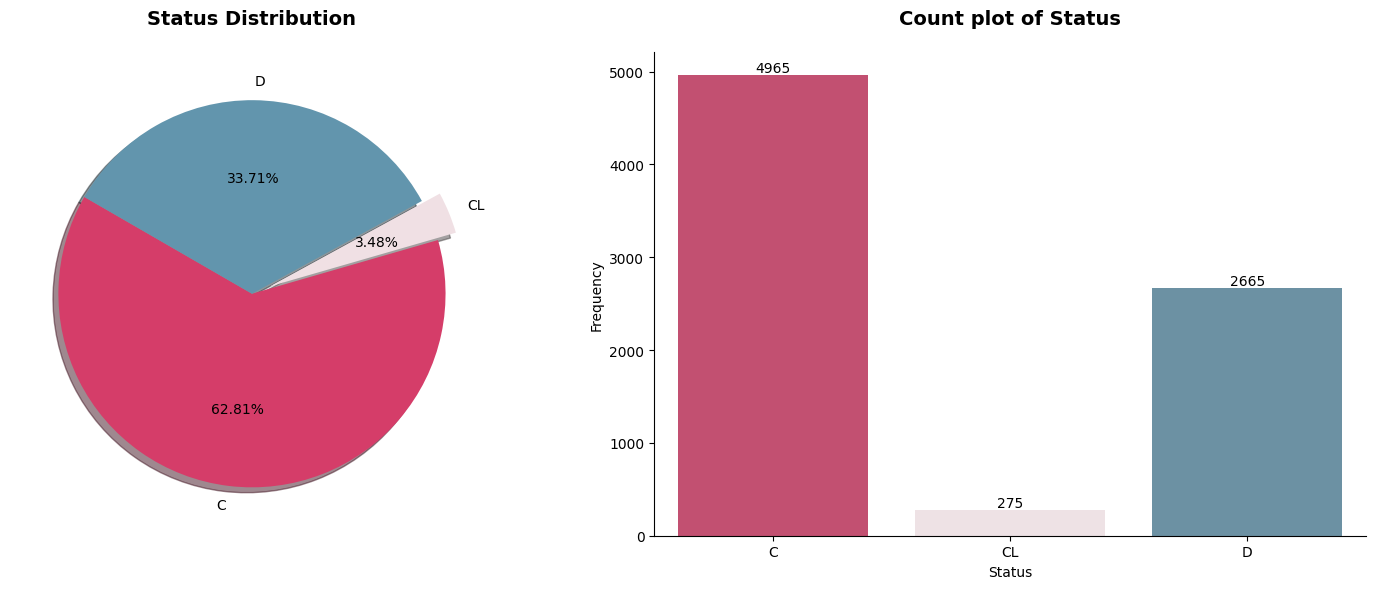

In [15]:
# Prepare data and colors
status_counts = df_train["Status"].value_counts().sort_index()
order = status_counts.index.tolist()
colors = color(n_colors=len(order))
palette = dict(zip(order, colors))

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Highlight a specific label if needed
explode = [0.1 if lbl == "CL" else 0 for lbl in order]

# --- Pie chart ---
ax[0].pie(status_counts, labels=order, colors=colors, autopct="%1.2f%%", startangle=150, explode=explode, shadow=True)
ax[0].set_title("Status Distribution", fontweight="bold", fontsize=14, pad=20)

# --- Count plot ---
sns.countplot(data=df_train, x="Status", order=order, palette=palette, ax=ax[1])
ax[1].set_title("Count plot of Status", fontweight="bold", fontsize=14, pad=20)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=10)
ax[1].set(xlabel="Status", ylabel="Frequency")
sns.despine(ax=ax[1])

plt.tight_layout()
plt.show()

* **C (Current)** accounts for **62.8%**, the largest group → most customers are currently active.
* **D (Default)** makes up **33.7%** → a relatively high proportion of defaulters, indicating potential credit risk.
* **CL (Closed)** represents only **3.5%**, the smallest segment → few customers have fully closed their accounts.

➡️ **Insight:** The dataset shows **class imbalance**, with the “C” class dominating. When training models, consider using **class weighting or oversampling techniques** to maintain balanced performance across classes.

## Numerical Feature Distributions

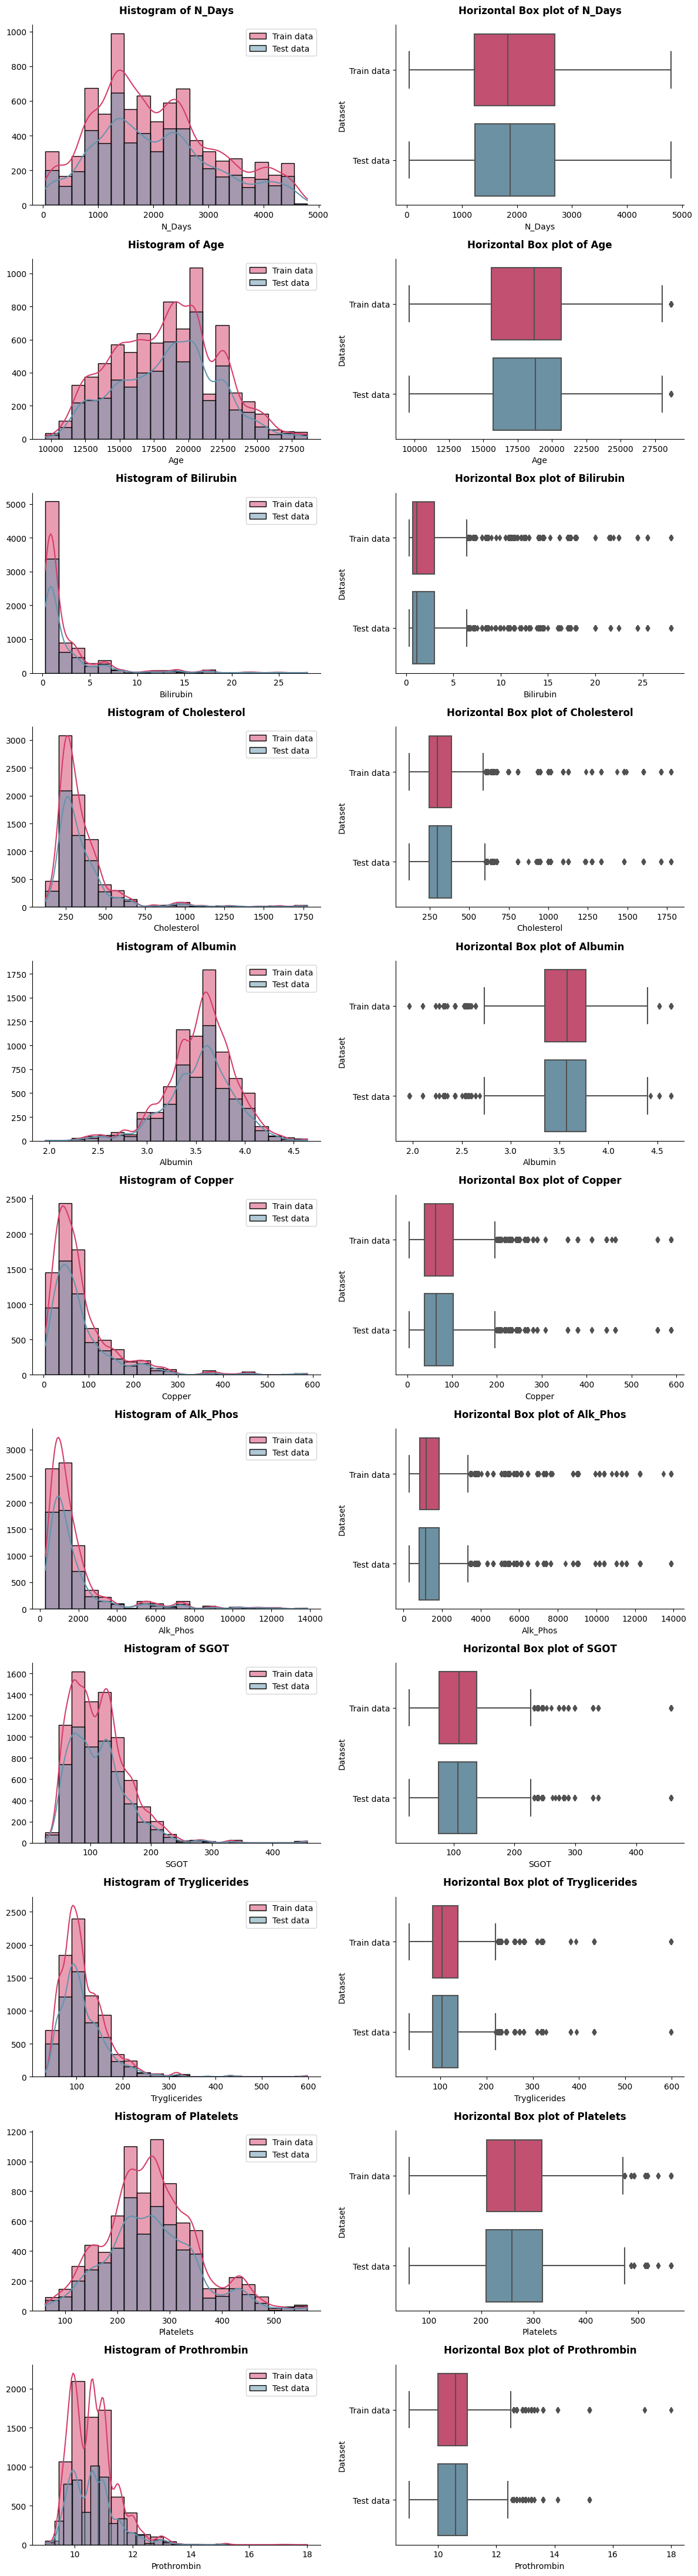

In [16]:
def plot_numerical_features(df_train, df_test, num_features):
    colors = color(n_colors=2)
    n = len(num_features)

    fig, axes = plt.subplots(n, 2, figsize=(12, n * 4))
    axes = np.array(axes).reshape(n, 2)

    for i, feature in enumerate(num_features):
        sns.histplot(data=df_train[feature], color=colors[0], bins=20, kde=True, ax=axes[i, 0], label="Train data")
        sns.histplot(data=df_test[feature], color=colors[1], bins=20, kde=True, ax=axes[i, 0], label="Test data")
        axes[i, 0].set_title(f"Histogram of {feature}", pad=14, weight="bold")
        axes[i, 0].legend()
        axes[i, 0].set_ylabel("")
        # axes[i, 0].axvline(df_train[feature].median(), color="green", linestyle="--", label="Median Train")
        # axes[i, 0].axvline(df_test[feature].median(), color="orange", linestyle="--", label="Median Test")
        sns.despine(left=False, bottom=False, ax=axes[i, 0])

        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        sns.boxplot(data=df_plot, x=feature, y="Dataset", palette=colors, orient="h", ax=axes[i, 1])
        axes[i, 1].set_title(f"Horizontal Box plot of {feature}", pad=14, weight="bold")
        sns.despine(left=False, bottom=False, ax=axes[i, 1])

    plt.tight_layout()
    plt.show()

plot_numerical_features(df_train = df_train, df_test = df_test, num_features=num_features)

In [17]:
def check_skewness(data, dataset_name, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass

    print(f"\n🔍 Skewness for {dataset_name}:")
    print("-"*70)
    print(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    print("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<30} | {skew:>+9.4f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    print("-"*70)
    return skew_feature, skew_df

skew_feature_train, skew_train_df = check_skewness(df_train, "Train Data")
skew_feature_test, skew_test_df = check_skewness(df_test, "Test Data")


🔍 Skewness for Train Data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
Cholesterol                    |   +3.6797 | Highly skewed
Bilirubin                      |   +3.3397 | Highly skewed
Alk_Phos                       |   +3.1956 | Highly skewed
Copper                         |   +2.7017 | Highly skewed
Tryglicerides                  |   +2.6339 | Highly skewed
SGOT                           |   +1.5348 | Highly skewed
Prothrombin                    |   +1.2924 | Highly skewed
Albumin                        |   -0.5611 | Moderately skewed
N_Days                         |   +0.4487 | Approximately symmetric
Platelets                      |   +0.4200 | Approximately symmetric
Age                            |   +0.0841 | Approximately symmetric
----------------------------------------------------------------------

🔍 Skewness for Test Dat

**Distribution & Skewness Analysis**

* Most **numerical features** show **right-skewed distributions**, especially
  **Cholesterol, Bilirubin, Alk_Phos, Copper, Tryglicerides, SGOT, and Prothrombin**, indicating long tails toward higher values and possible presence of **outliers**.
* **Albumin** is slightly **left-skewed**, while **N_Days, Platelets, and Age** are **approximately symmetric**, showing balanced distributions between lower and higher ranges.
* **Train and Test sets** share very similar distribution patterns, confirming that **data splitting was done properly** and both sets are statistically consistent.
* For modeling, **log transformation or power transformation** should be applied to highly skewed features to improve **normality and model performance**.

## Correlation Analysis of Numerical Features

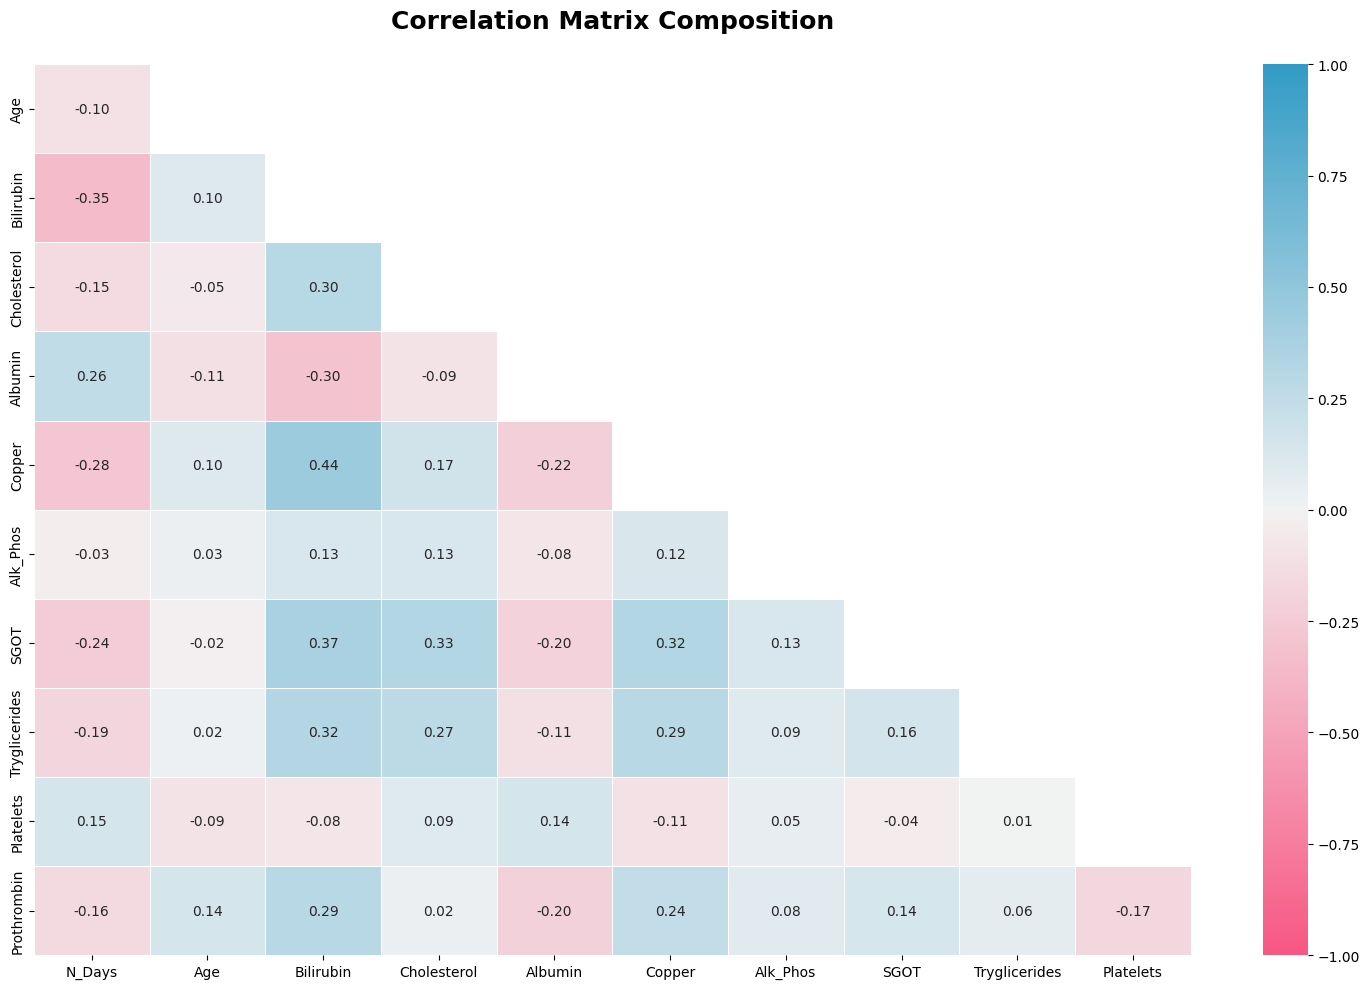

In [18]:
corr_matrix = df_train[num_features].corr(numeric_only=True)
# one_like can build a matrix of boolean(True, False) with the same shape as our data
ones_corr = np.ones_like(corr_matrix, dtype=bool)
mask = np.triu(ones_corr)
adjusted_mask = mask[1:, :-1]
adjusted_cereal_corr = corr_matrix.iloc[1:, :-1]

fig, ax = plt.subplots(figsize = (15, 10))
# That method uses HUSL colors, so you need hue, saturation, and lightness. 
# I used hsluv.org to select the colors of this chart.
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

sns.heatmap(data=adjusted_cereal_corr, mask=adjusted_mask,
            annot=True, fmt=".2f", cmap=cmap,
            vmin=-1, vmax=1, linecolor="white", linewidths=0.5)

title = "Correlation Matrix Composition\n"
ax.set_title(title, loc="center", fontsize=18, weight="bold")
plt.tight_layout()
plt.show()

**Correlation Matrix Analysis**

* Most variables show **weak correlations**, indicating **no serious multicollinearity issue** in the dataset.
* **Copper** has a moderate positive correlation with **Cholesterol (0.44)** and **SGOT (0.32)** → suggesting a potential relationship between **copper metabolism and liver enzyme activity**.
* **Albumin** shows negative correlations with **Cholesterol (-0.30)** and **SGOT (-0.20)**, implying that **lower albumin levels** may be associated with **weaker liver function**.
* Other variables such as **N_Days, Age, and Platelets** have minimal relationships, acting mostly as **independent features**.

## Categorical Feature Distributions

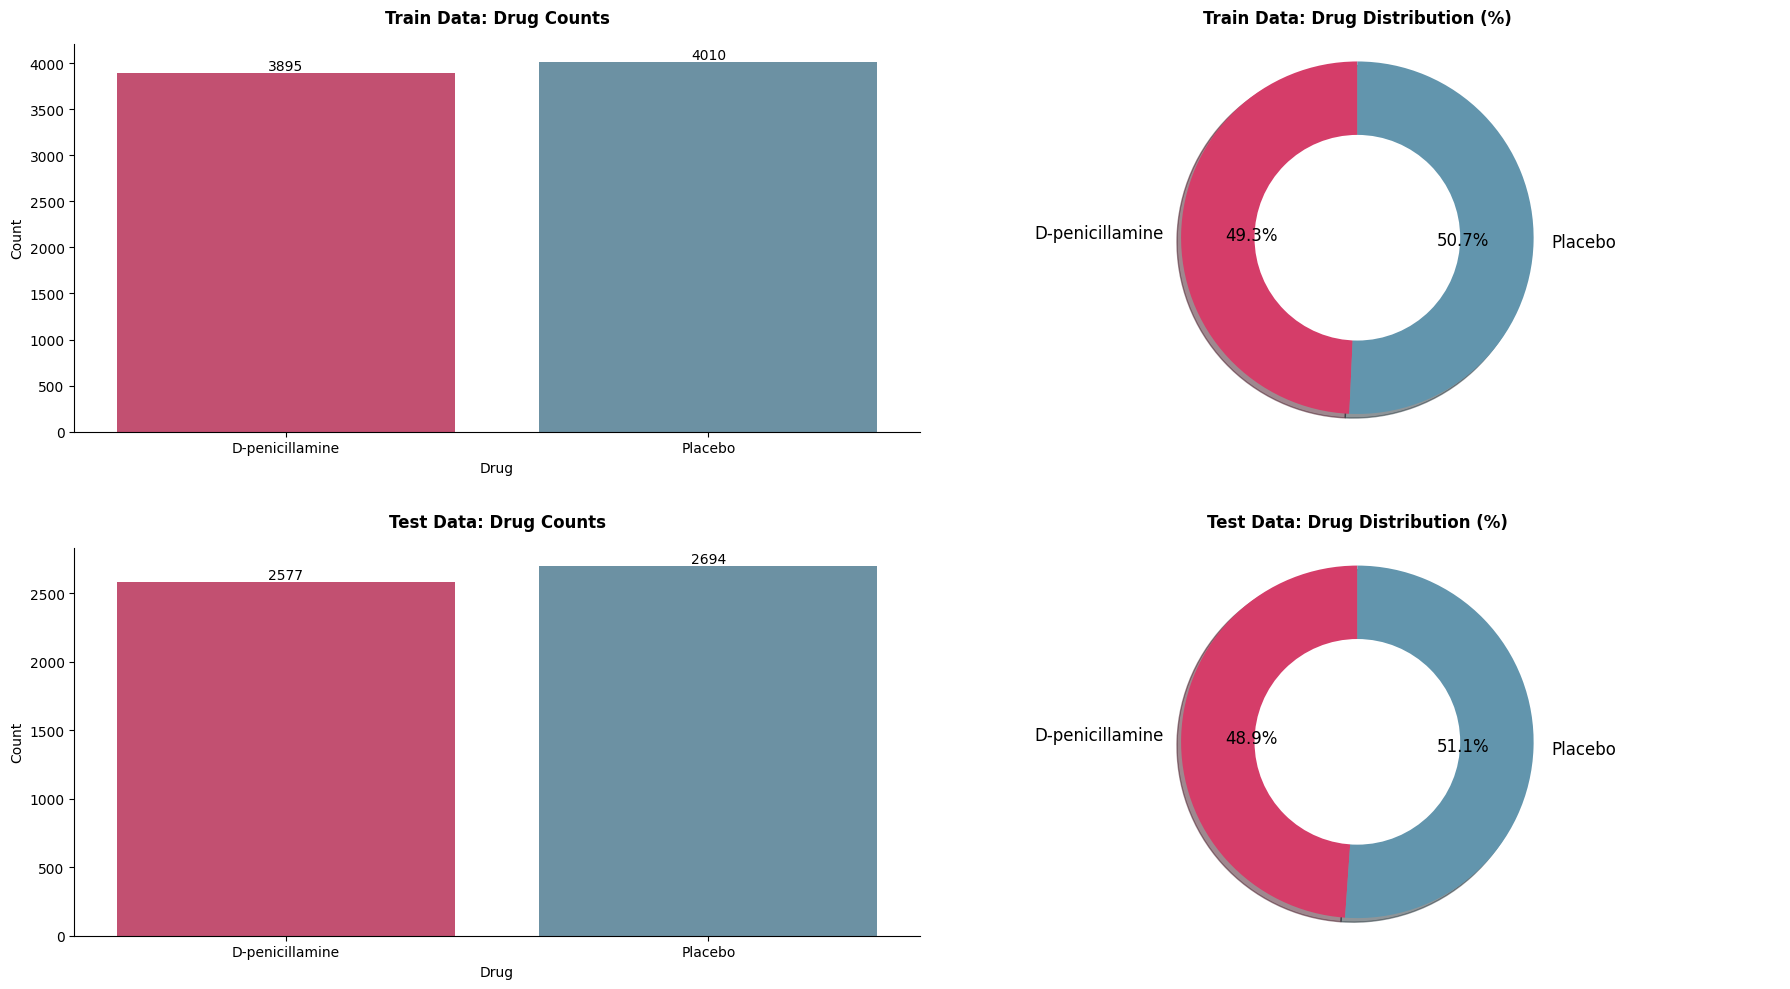

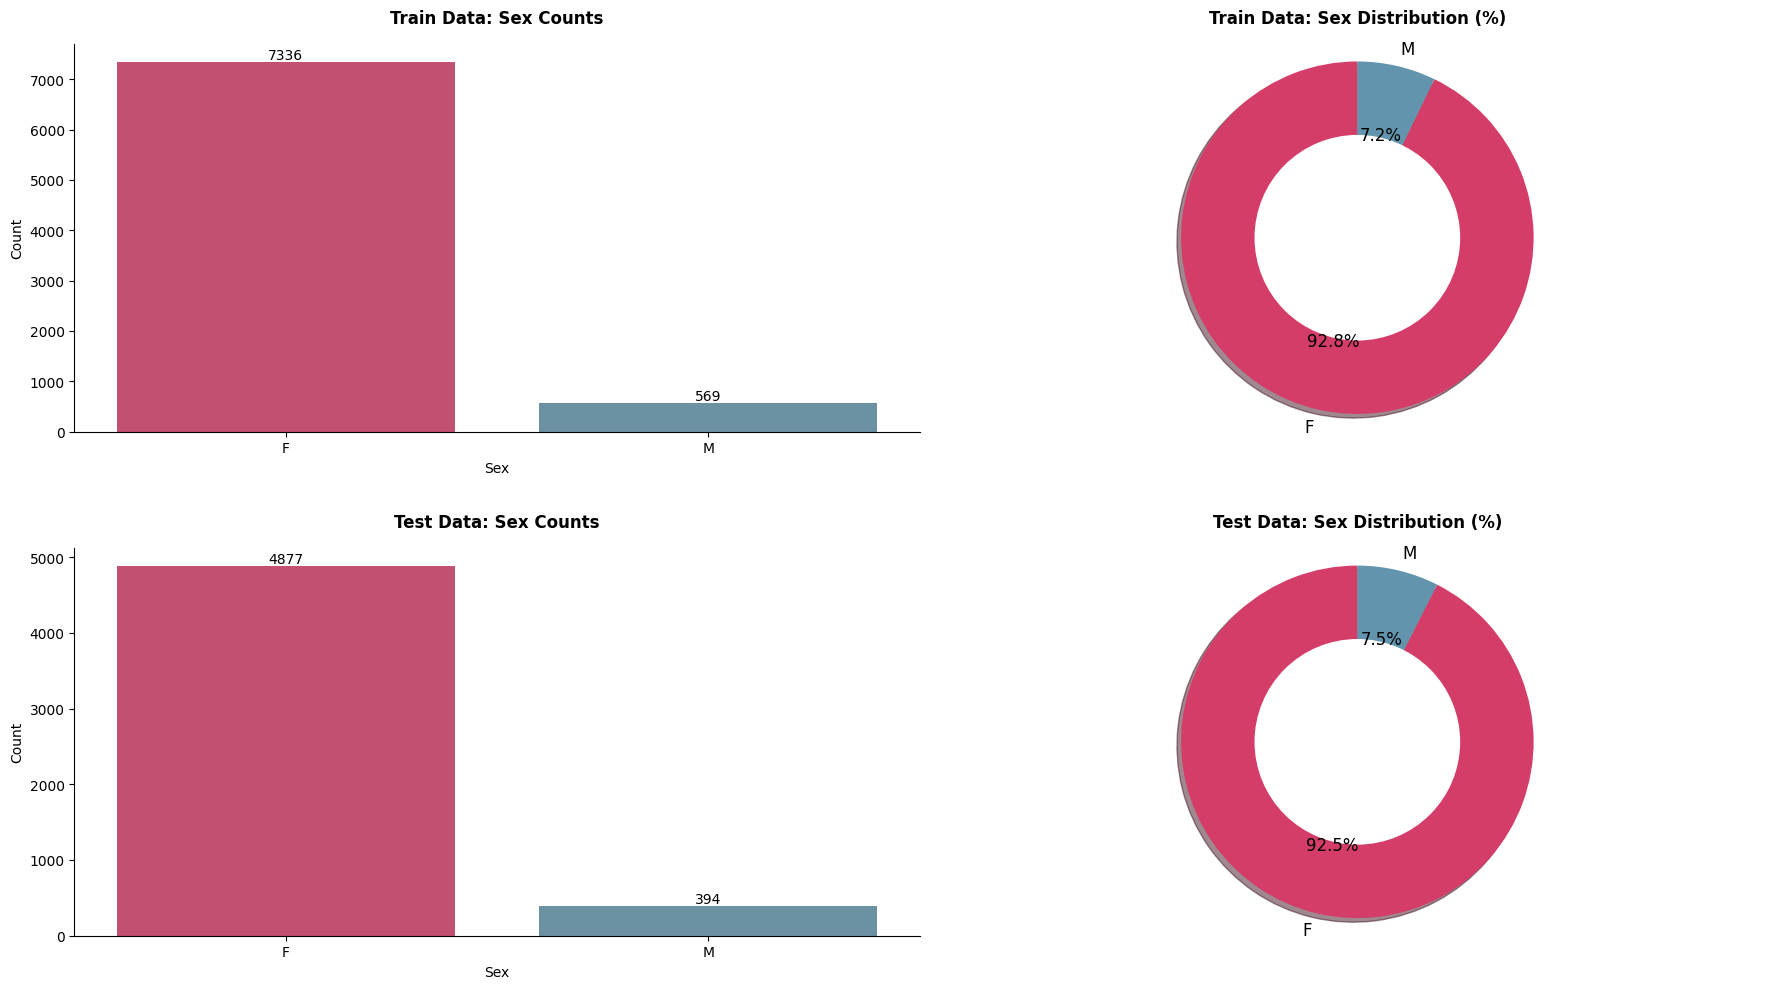

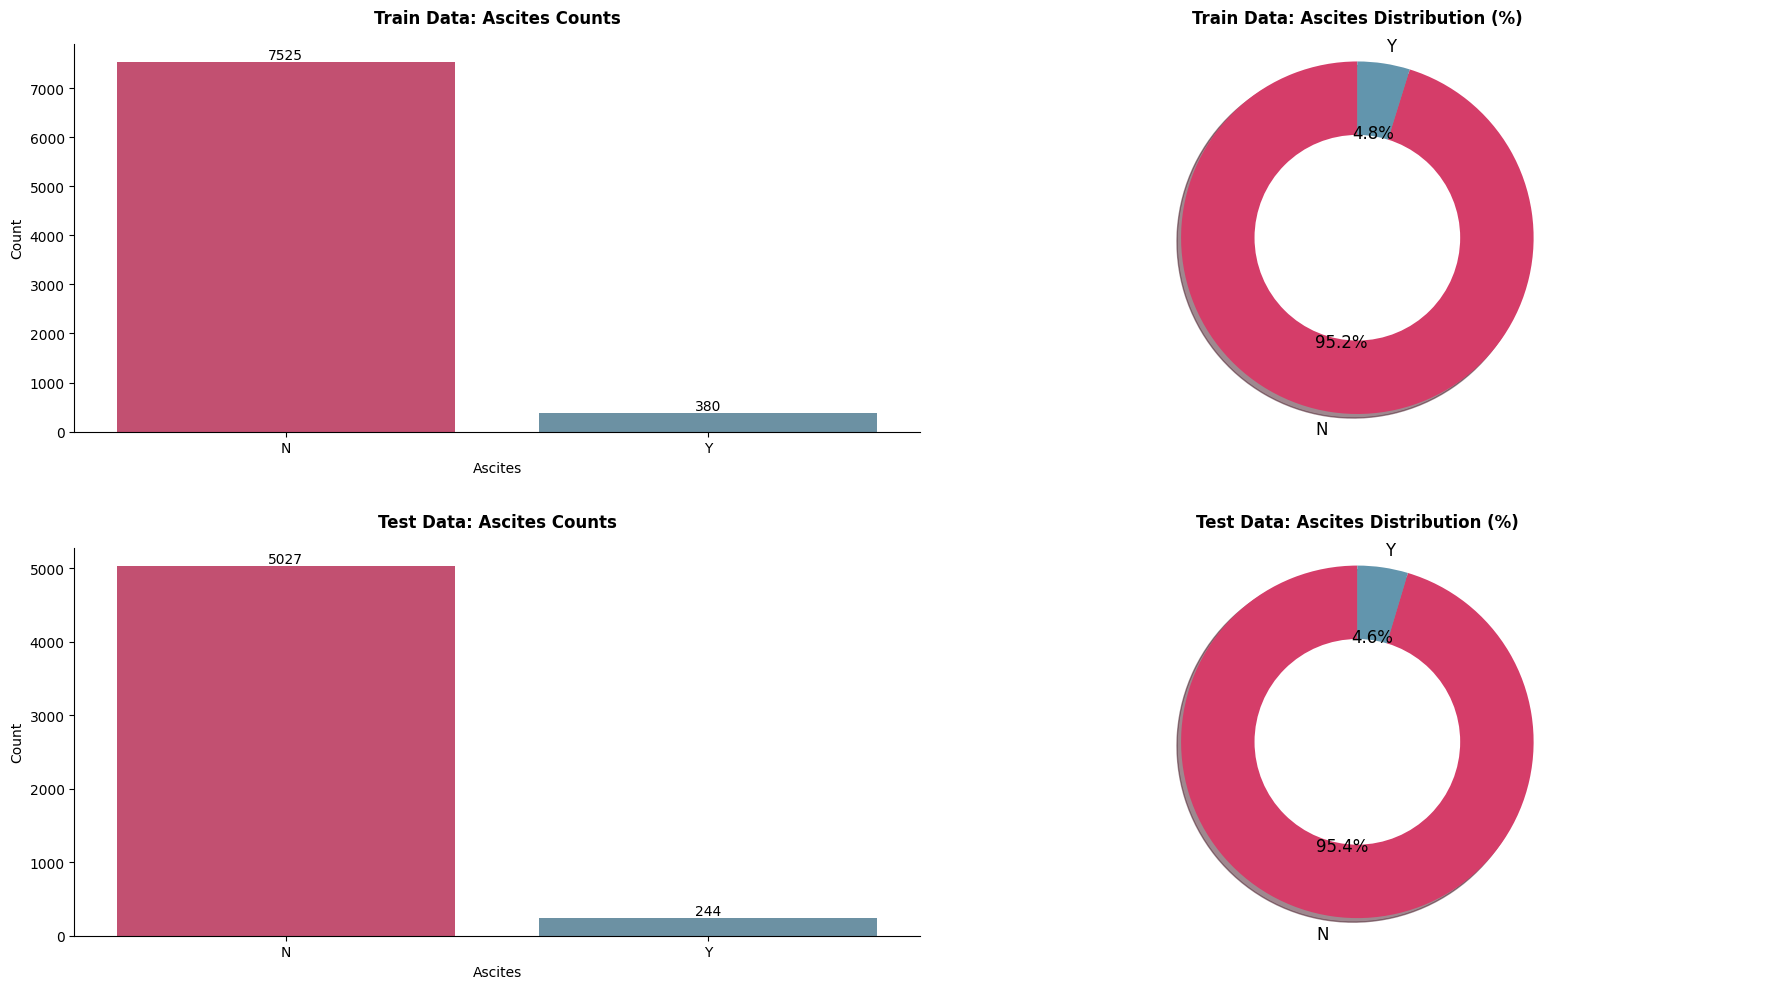

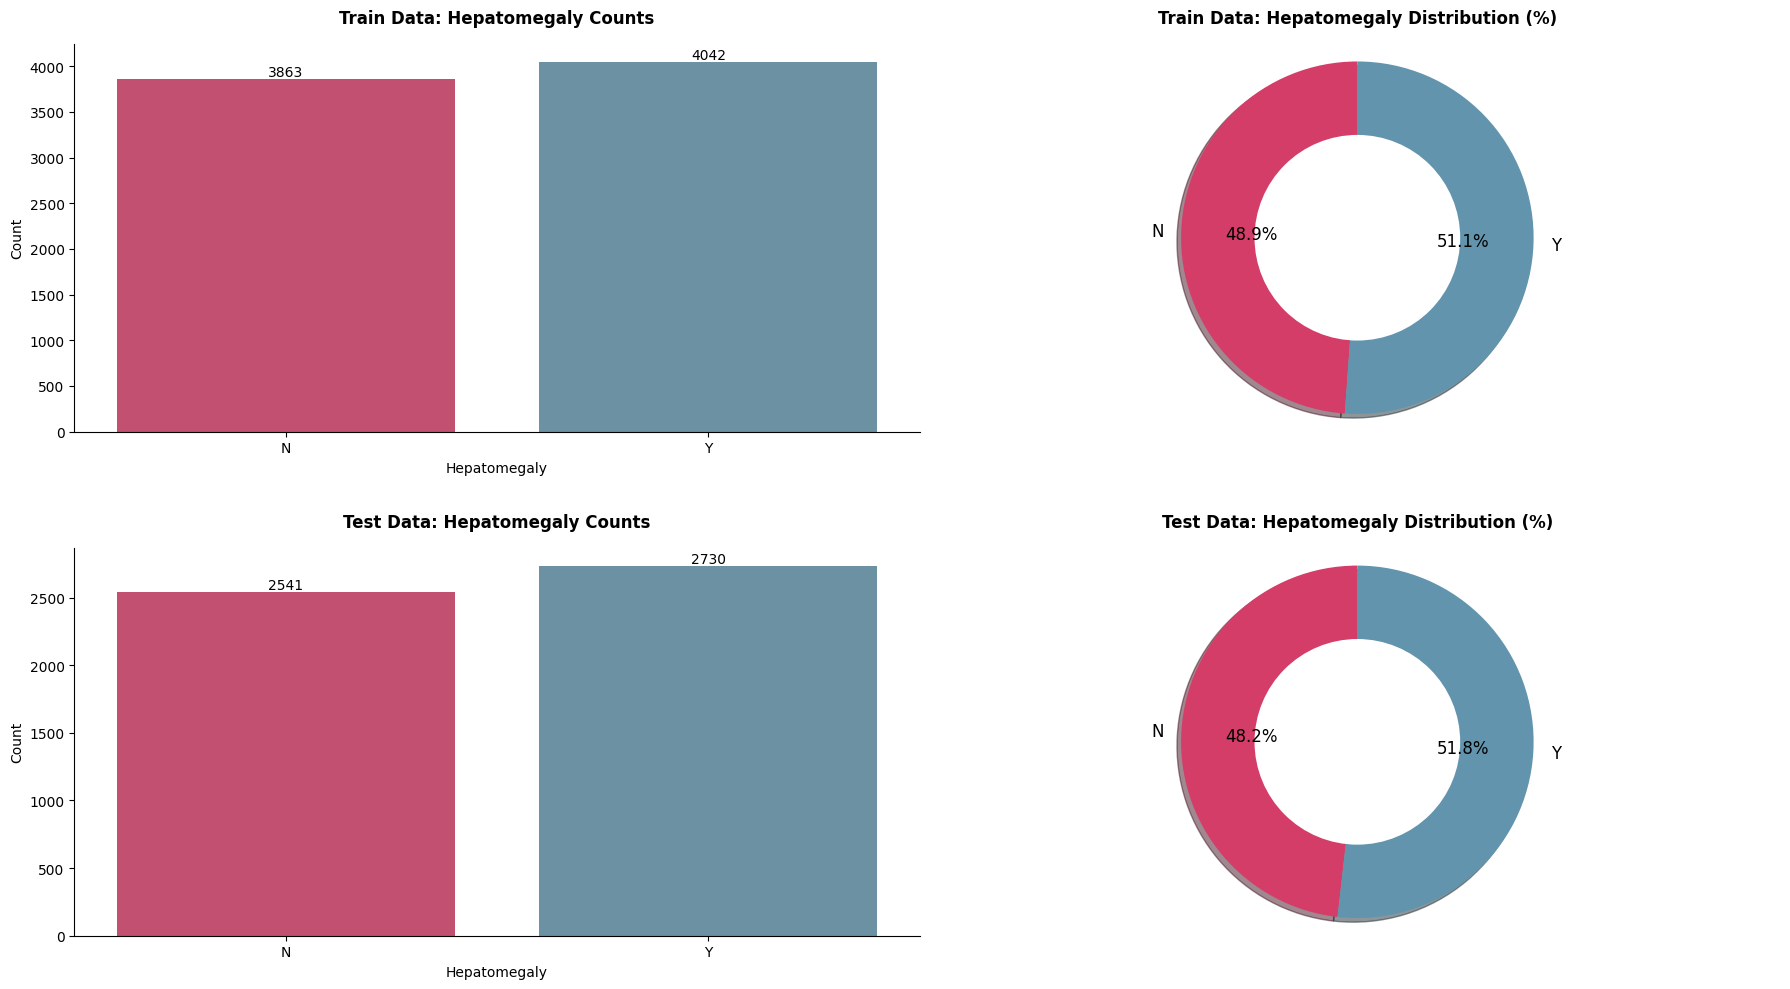

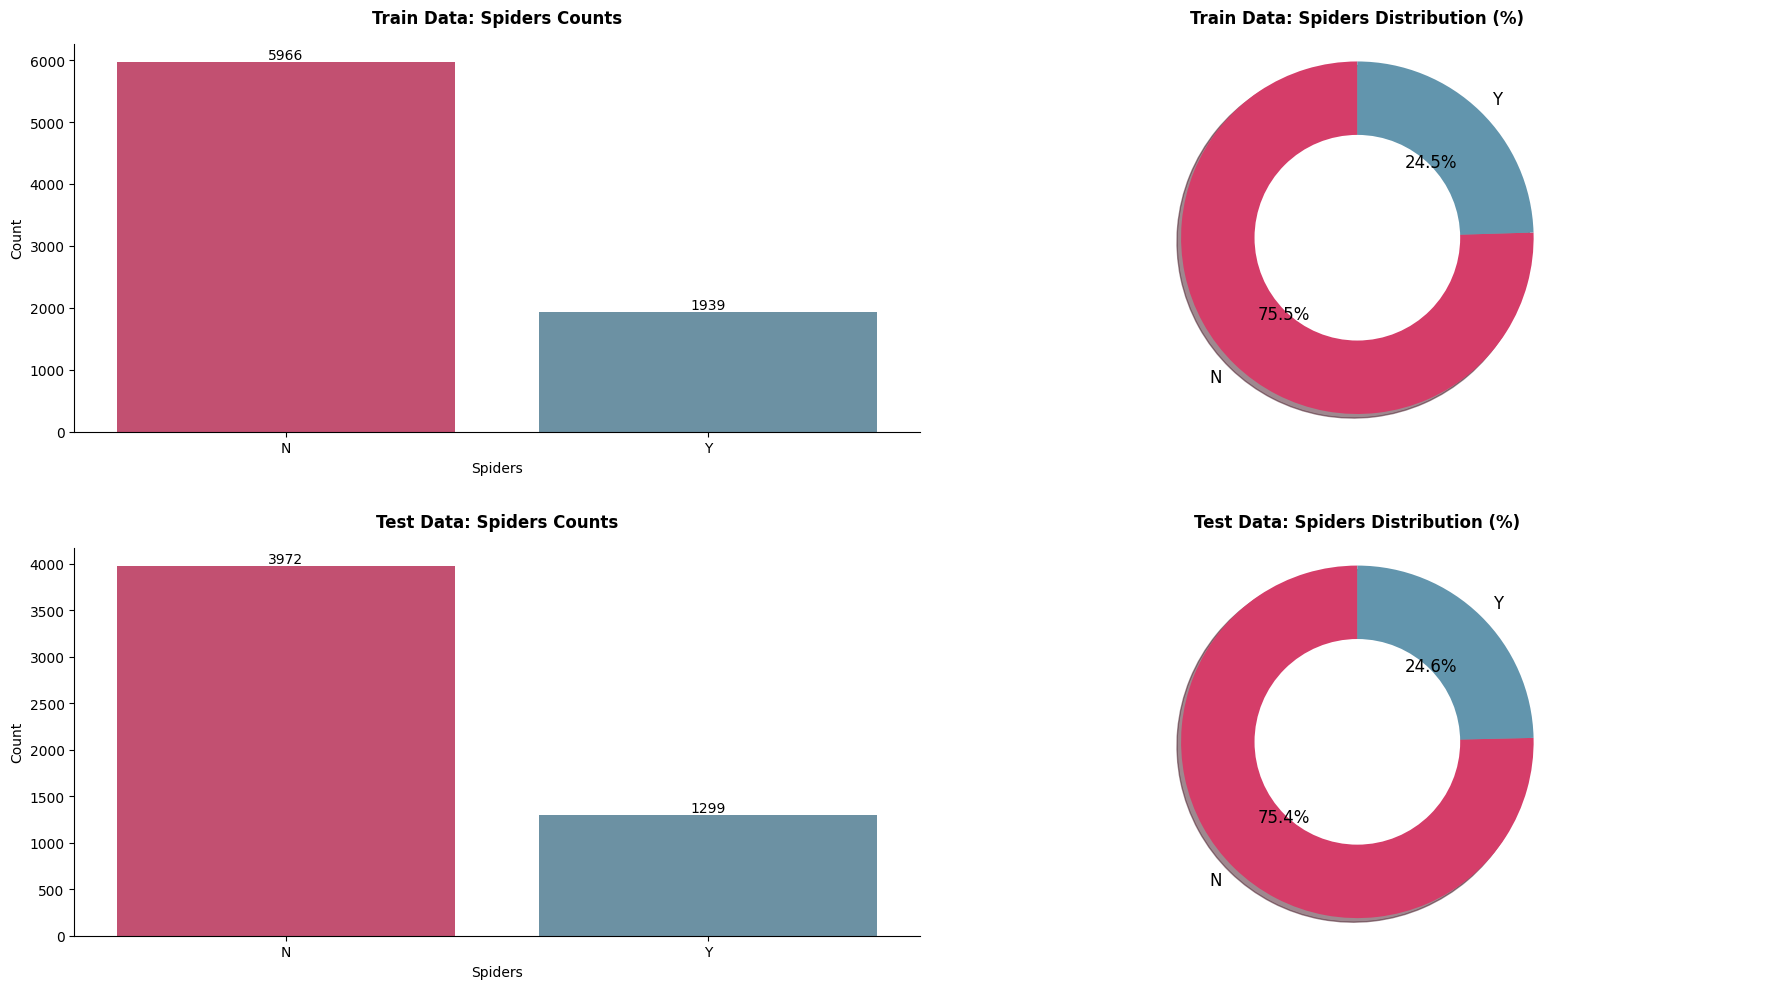

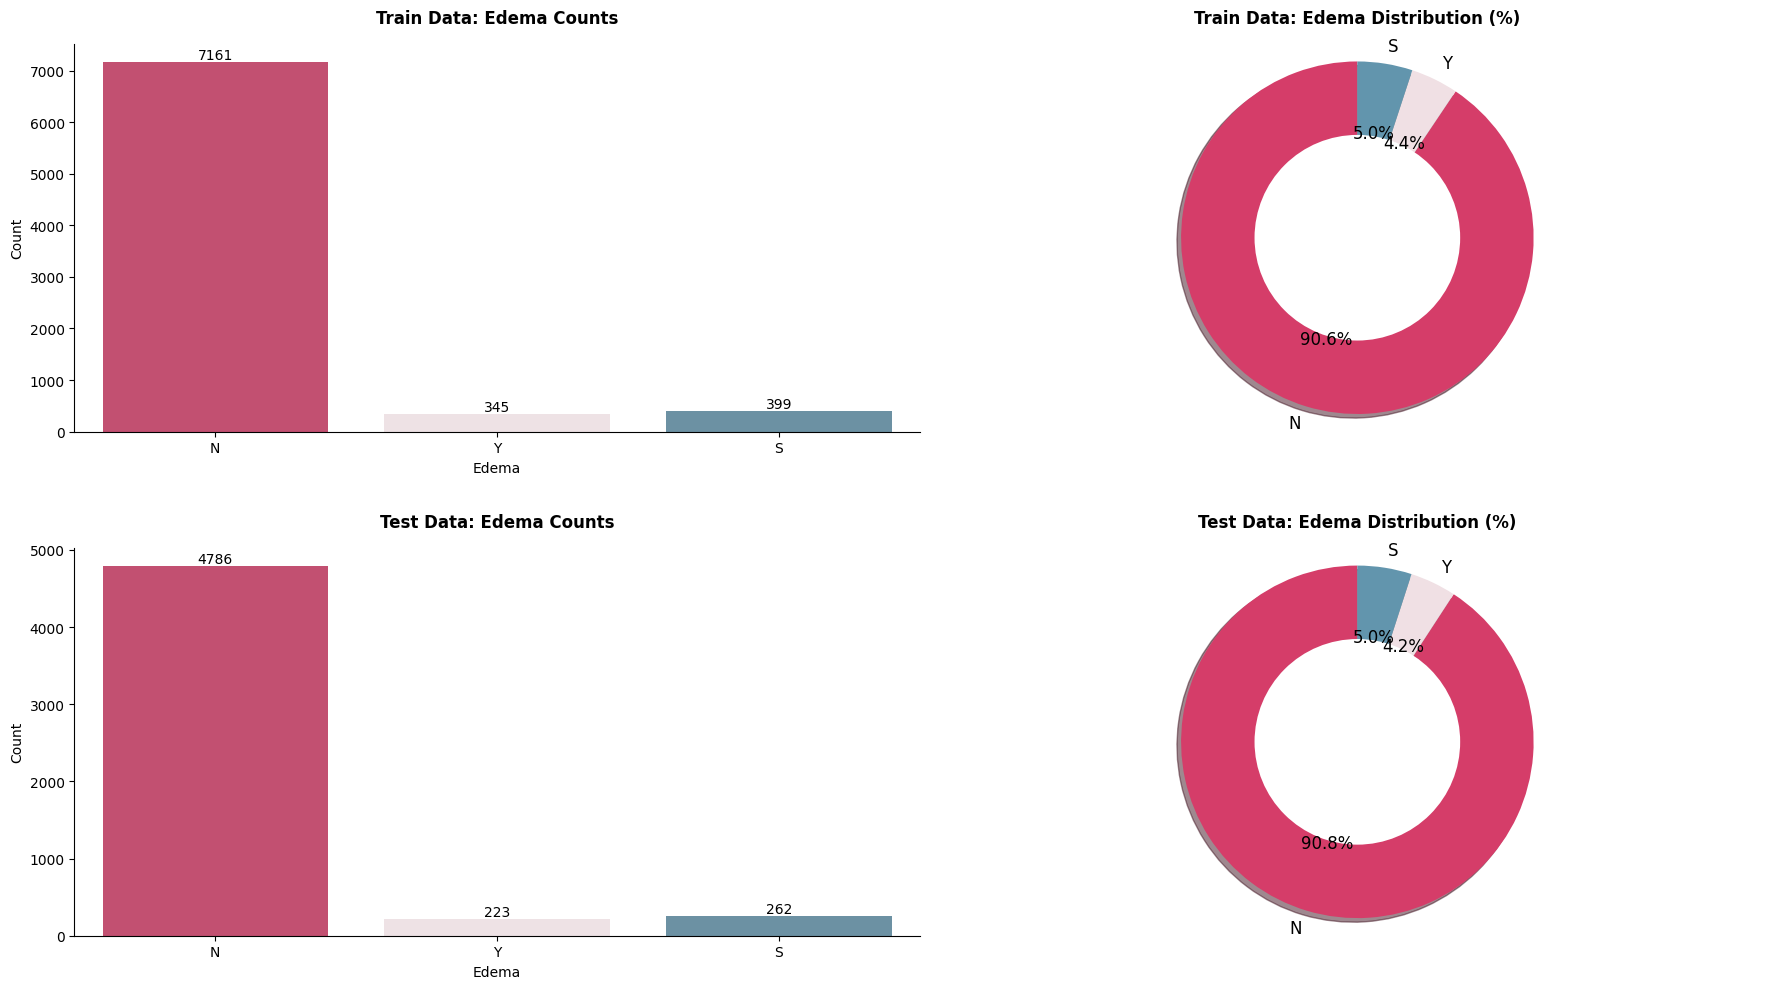

In [19]:
def plot_categorical_distribution_across_datasets(train_data, test_data, feature, tone="diverging"):
    # ----- Unified order across both datasets -----
    order = (
        pd.Index(train_data[feature].dropna().unique())
        .union(pd.Index(test_data[feature].dropna().unique()))
        .tolist()
    )
    order = list(map(str, order))  # tránh lỗi khi có mixed types
    # Map về string cho vẽ
    tdf = train_data.copy()
    vdf = test_data.copy()
    tdf[feature] = tdf[feature].astype(str)
    vdf[feature] = vdf[feature].astype(str)

    # ----- Consistent colors -----
    colors = color(n_colors=len(order), tone=tone)
    palette = dict(zip(order, colors))

    fig, ax = plt.subplots(2, 2, figsize=(18, 10))
    datasets = [(tdf, "Train"), (vdf, "Test")]

    # ----- Bar charts -----
    for i, (data, name) in enumerate(datasets):
        sns.countplot(
            data=data, x=feature, order=order, palette=palette, ax=ax[i, 0]
        )
        ax[i, 0].set_title(f"{name} Data: {feature} Counts", fontsize=12, pad=15, weight="bold")
        ax[i, 0].set_xlabel(feature)
        ax[i, 0].set_ylabel("Count")
        ax[i, 0].set_axisbelow(True)
        sns.despine(ax=ax[i, 0])

        # annotate đúng cho cột dọc
        for p in ax[i, 0].patches:
            height = int(p.get_height())
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax[i, 0].annotate(
                f"{height}", (x, y), ha="center", va="bottom", fontsize=10
            )

    # ----- Donut (pie) charts -----
    for i, (data, name) in enumerate(datasets):
        counts = data[feature].value_counts().reindex(order, fill_value=0)  # match order
        ax[i, 1].pie(
            counts.values,
            labels=order,
            autopct="%1.1f%%",
            startangle=90,
            colors=[palette[lbl] for lbl in order],   # match colors
            textprops={"fontsize": 12},
            radius=1.2,
            shadow=True,
        )
        centre_circle = plt.Circle((0, 0), 0.70, fc="white")
        ax[i, 1].add_artist(centre_circle)
        ax[i, 1].set_title(f"{name} Data: {feature} Distribution (%)",
                           fontsize=12, pad=15, weight="bold")
        ax[i, 1].axis("equal")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.show()

for feature in cat_features:
    plot_categorical_distribution_across_datasets(df_train, df_test, feature)

**Overall Consistency in Categorical Feature Distributions**

* The **count plots and percentage distribution charts** of categorical variables across the **Train, Test, and Original datasets** show a **high degree of consistency**.
* There are **no noticeable signs of distributional shift** or **sampling bias** across datasets.

## Bivariate Analysis

,Status,Count,Mean,Median,Std
0,C,4965,2322.529305,2216.000000,989.946056
1,CL,275,1610.105455,1435.000000,828.962239
2,D,2665,1528.849156,1216.000000,1107.608074



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: N_Days


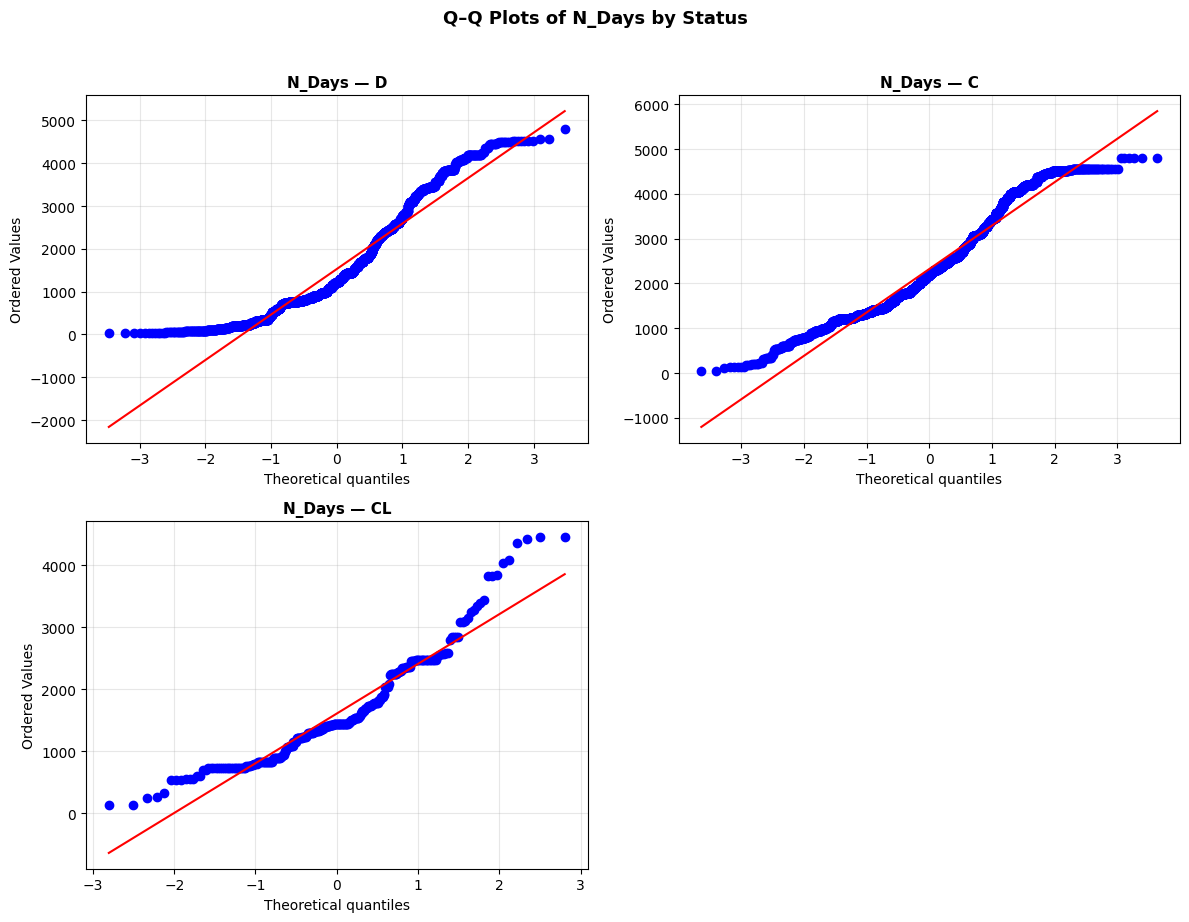

,Feature,Group,Skewness,Kurtosis,Remark
0,N_Days,C,0.5386,-0.4791,"Moderately skewed, Normal tails"
1,N_Days,CL,1.0800,1.2662,"Highly skewed, Normal tails"
2,N_Days,D,0.8293,-0.1918,"Moderately skewed, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: N_Days ~ Status
Kruskal-Wallis H-statistic: 1102.872
p-value: 3.268759423709948e-240
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
                C            CL              D
C    1.000000e+00  3.095707e-28  2.279326e-231
CL   3.095707e-28  1.000000e+00   4.395323e-01
D   2.279326e-231  4.395323e-01   1.000000e+00


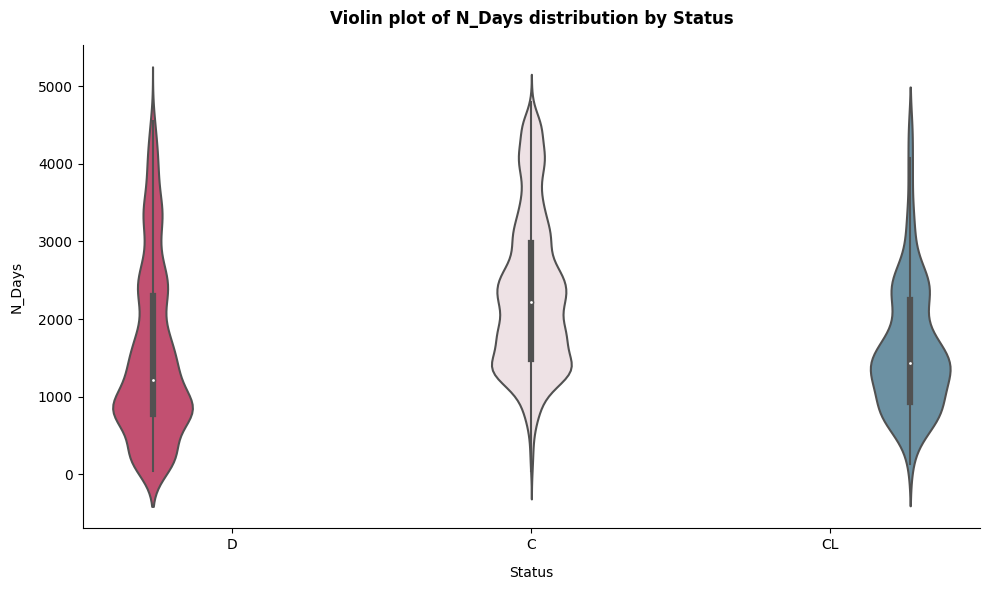

,Status,Count,Mean,Median,Std
0,D,2665,19345.741839,19256.000000,3521.119287
1,C,4965,17969.769587,18137.000000,3657.705623
2,CL,275,16230.600000,15112.000000,3311.173473



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Age


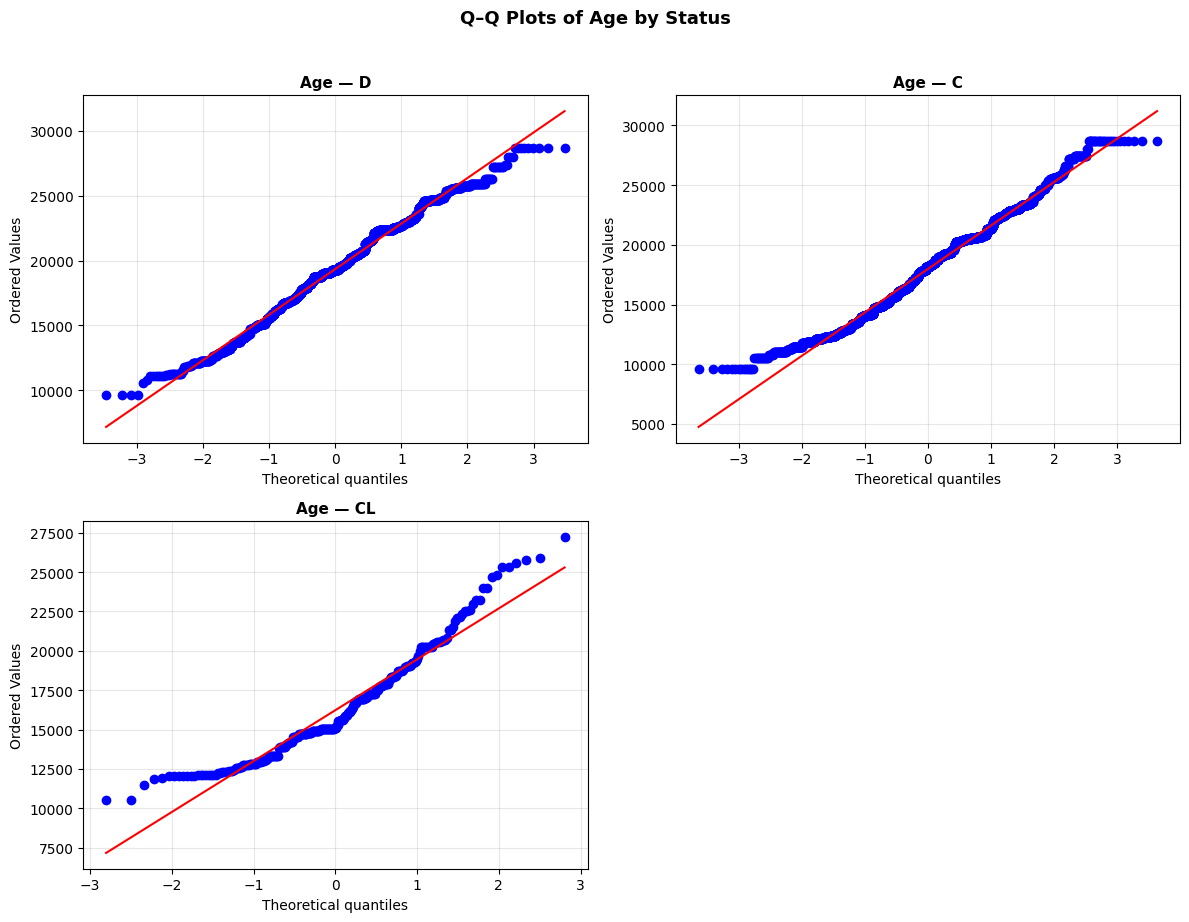

,Feature,Group,Skewness,Kurtosis,Remark
0,Age,C,0.1718,-0.4025,"Approximately symmetric, Normal tails"
1,Age,CL,0.8690,0.4052,"Moderately skewed, Normal tails"
2,Age,D,-0.1148,-0.4175,"Approximately symmetric, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Age ~ Status
Kruskal-Wallis H-statistic: 343.961
p-value: 2.0412124884026831e-75
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               C            CL             D
C   1.000000e+00  1.396232e-15  3.542368e-53
CL  1.396232e-15  1.000000e+00  8.902363e-43
D   3.542368e-53  8.902363e-43  1.000000e+00


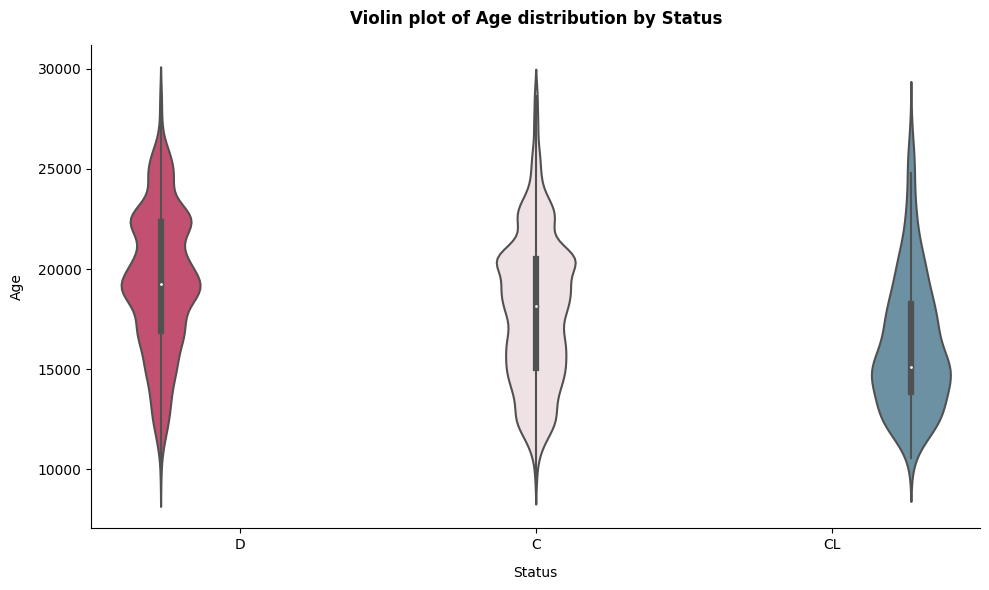

,Status,Count,Mean,Median,Std
0,D,2665,4.857486,3.200000,5.297413
1,CL,275,2.903273,2.900000,2.137728
2,C,4965,1.362699,0.800000,1.888044



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Bilirubin


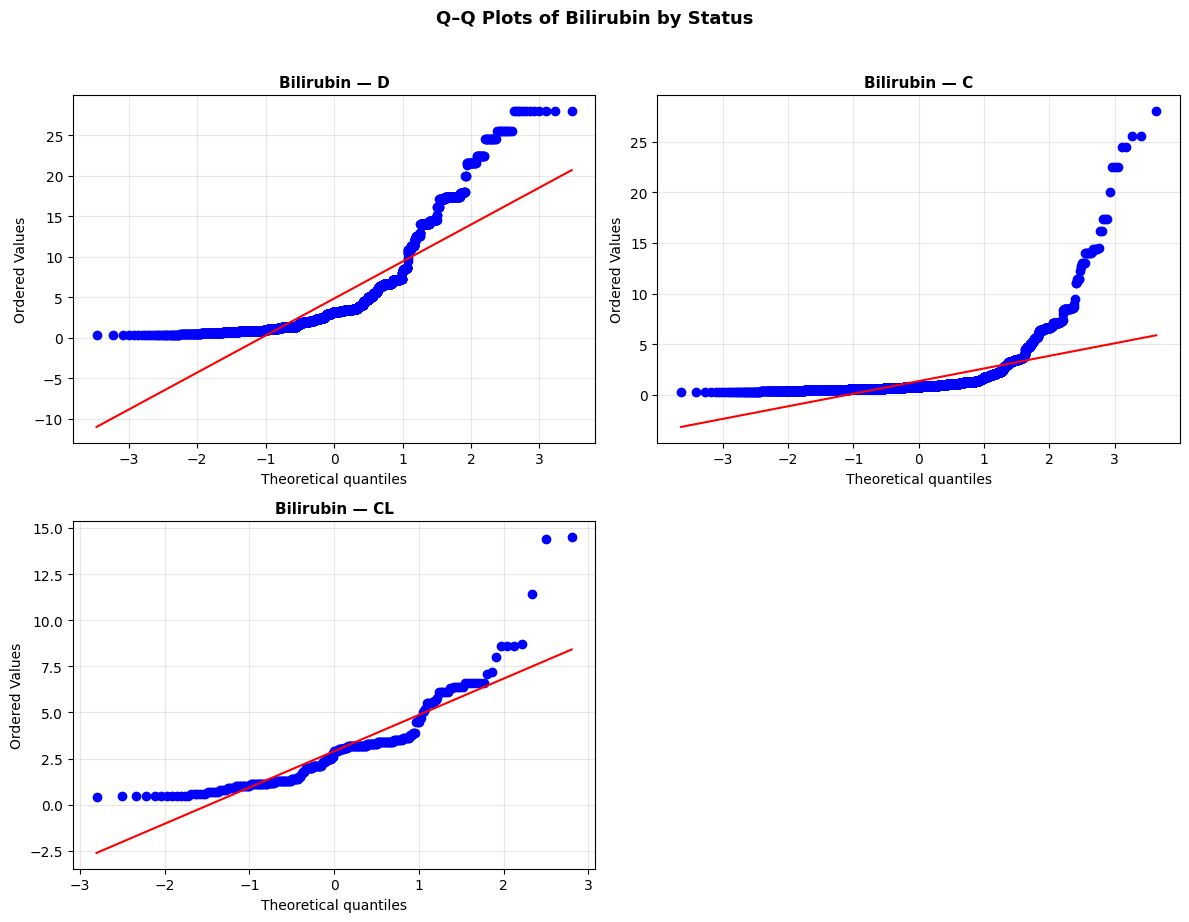

,Feature,Group,Skewness,Kurtosis,Remark
0,Bilirubin,C,6.0145,52.2732,"Highly skewed, Heavy/light tails"
1,Bilirubin,CL,1.8998,5.9965,"Highly skewed, Heavy/light tails"
2,Bilirubin,D,2.0003,3.8175,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Bilirubin ~ Status
Kruskal-Wallis H-statistic: 2326.336
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               C            CL         D
C   1.000000e+00  1.736422e-57  0.000000
CL  1.736422e-57  1.000000e+00  0.080928
D   0.000000e+00  8.092766e-02  1.000000


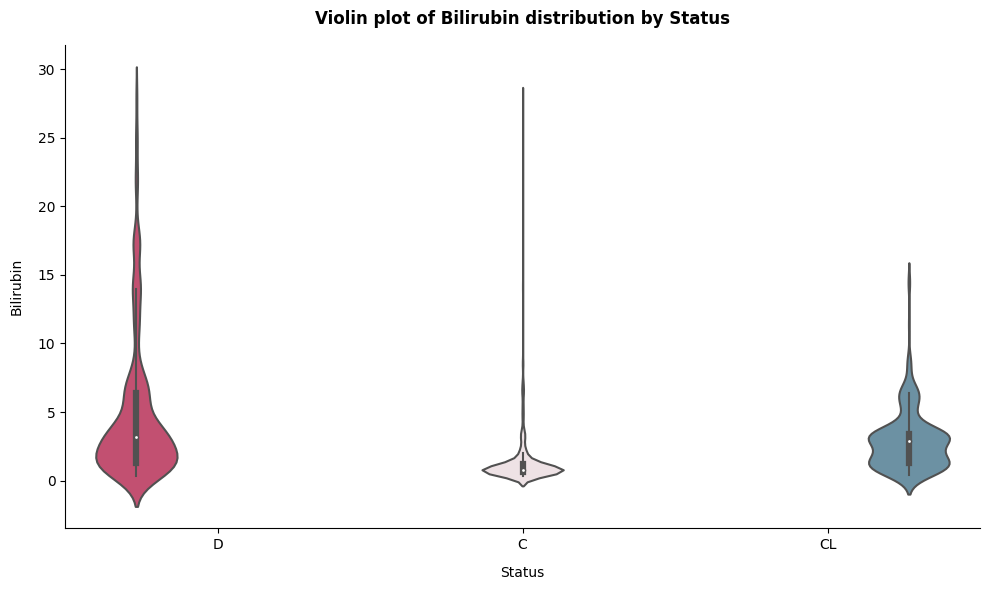

,Status,Count,Mean,Median,Std
0,CL,275,404.829091,336.000000,279.790791
1,D,2665,398.027392,331.000000,249.010071
2,C,4965,322.078751,288.000000,144.914094



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Cholesterol


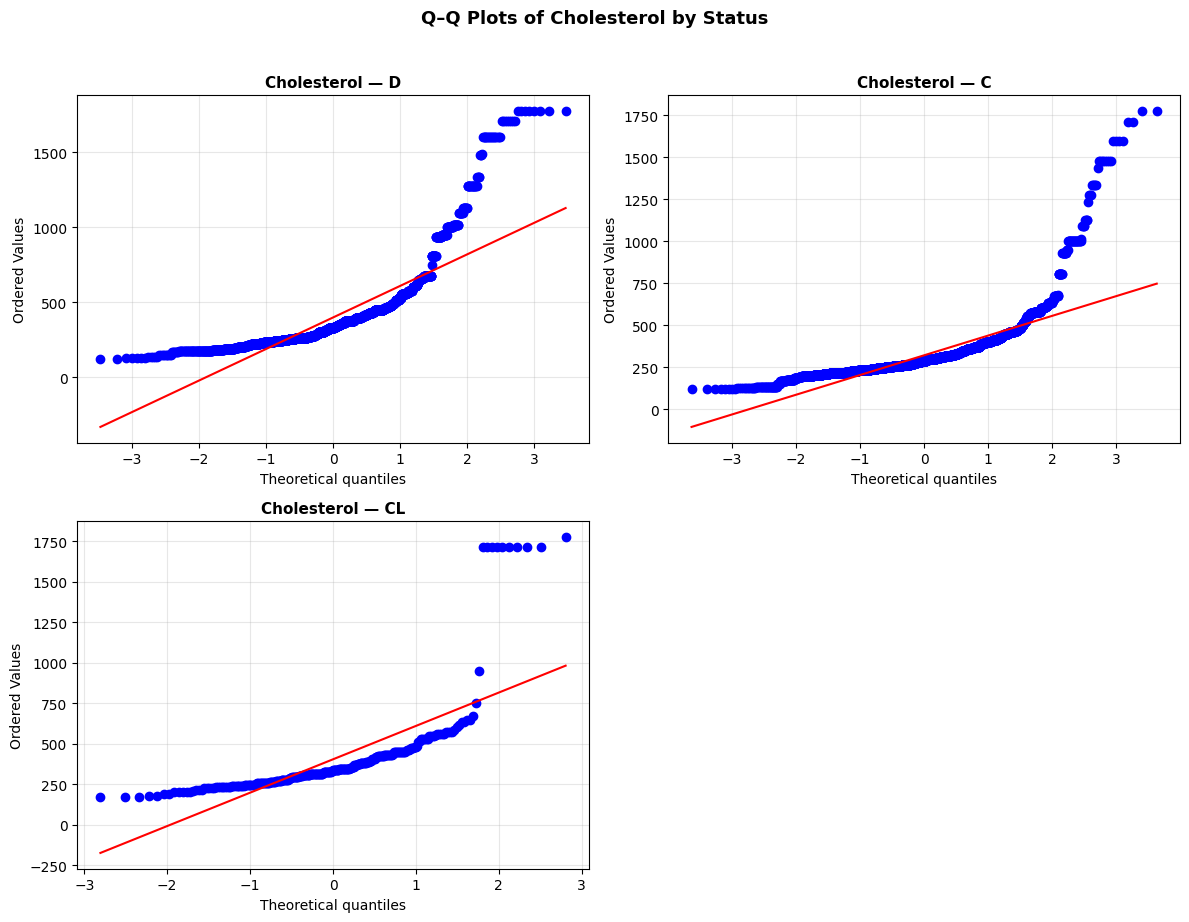

,Feature,Group,Skewness,Kurtosis,Remark
0,Cholesterol,C,4.1696,26.5975,"Highly skewed, Heavy/light tails"
1,Cholesterol,CL,3.7730,14.9377,"Highly skewed, Heavy/light tails"
2,Cholesterol,D,2.7467,9.3515,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Cholesterol ~ Status
Kruskal-Wallis H-statistic: 193.731
p-value: 8.549412741073258e-43
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               C            CL             D
C   1.000000e+00  3.651963e-12  3.744426e-37
CL  3.651963e-12  1.000000e+00  1.107126e-01
D   3.744426e-37  1.107126e-01  1.000000e+00


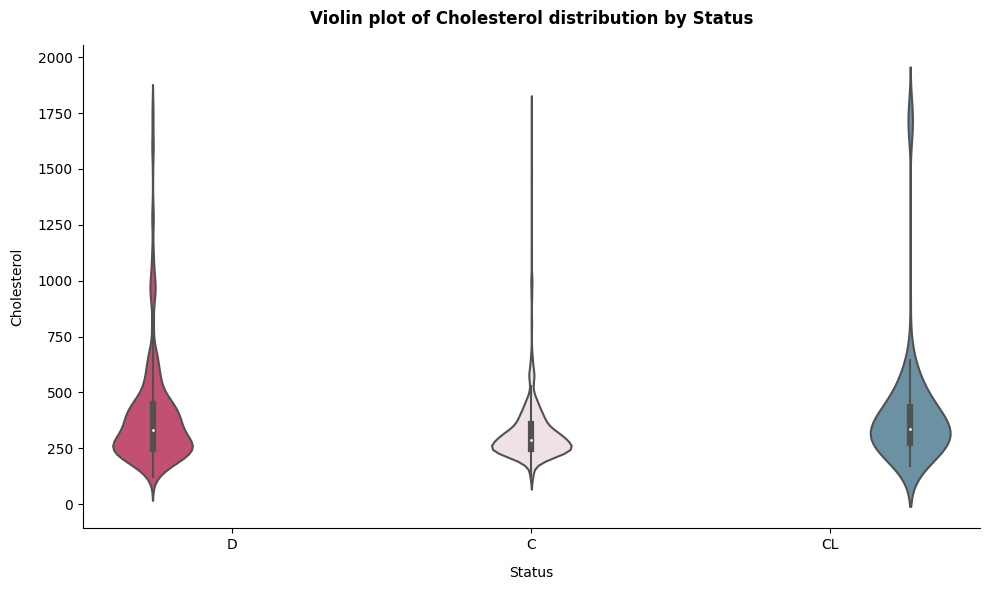

,Status,Count,Mean,Median,Std
0,C,4965,3.624918,3.610000,0.295335
1,CL,275,3.547418,3.570000,0.328999
2,D,2665,3.405715,3.450000,0.388078



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Albumin


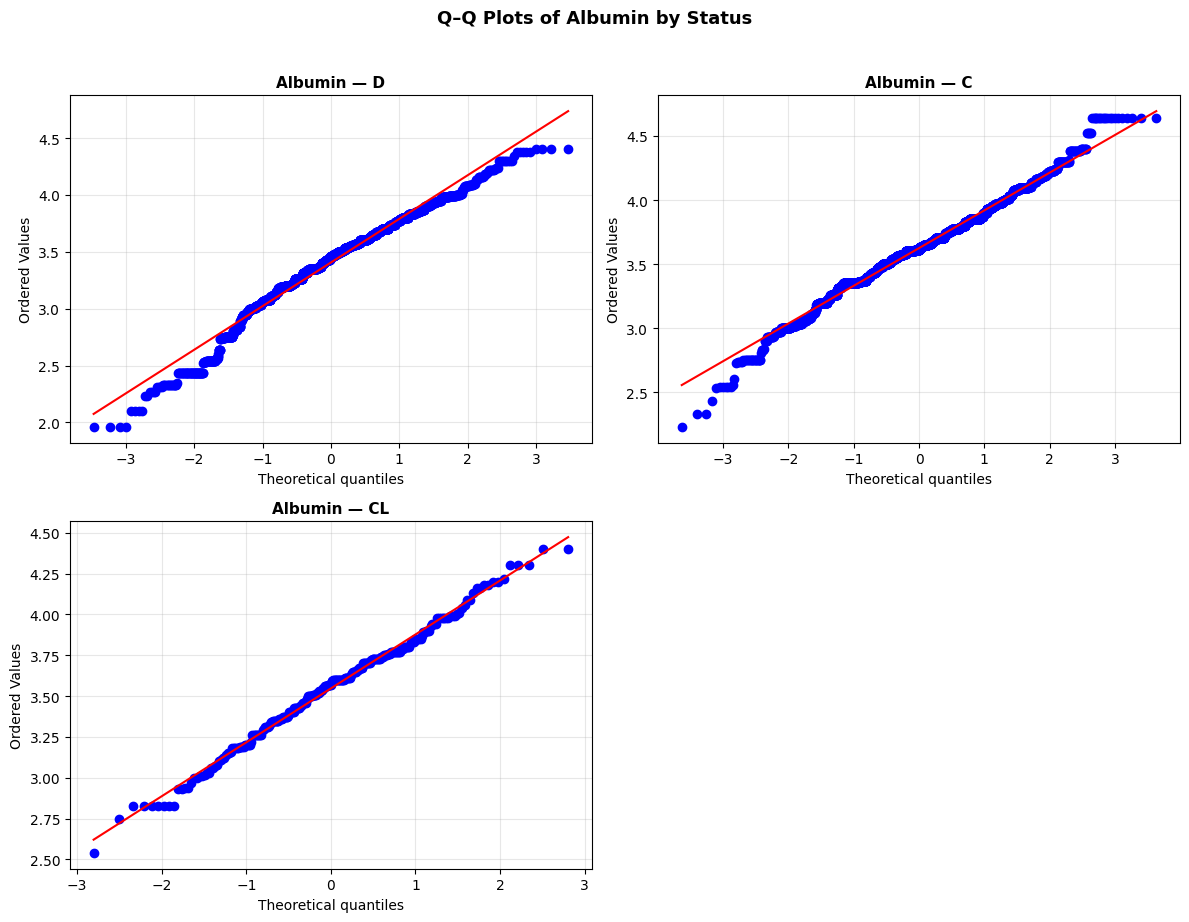

,Feature,Group,Skewness,Kurtosis,Remark
0,Albumin,C,-0.0858,0.9286,"Approximately symmetric, Normal tails"
1,Albumin,CL,-0.1221,0.0438,"Approximately symmetric, Normal tails"
2,Albumin,D,-0.6042,0.6171,"Moderately skewed, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Albumin ~ Status
Kruskal-Wallis H-statistic: 590.115
p-value: 7.212294818989388e-129
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
                C            CL              D
C    1.000000e+00  4.911433e-04  7.983604e-130
CL   4.911433e-04  1.000000e+00   1.008189e-07
D   7.983604e-130  1.008189e-07   1.000000e+00


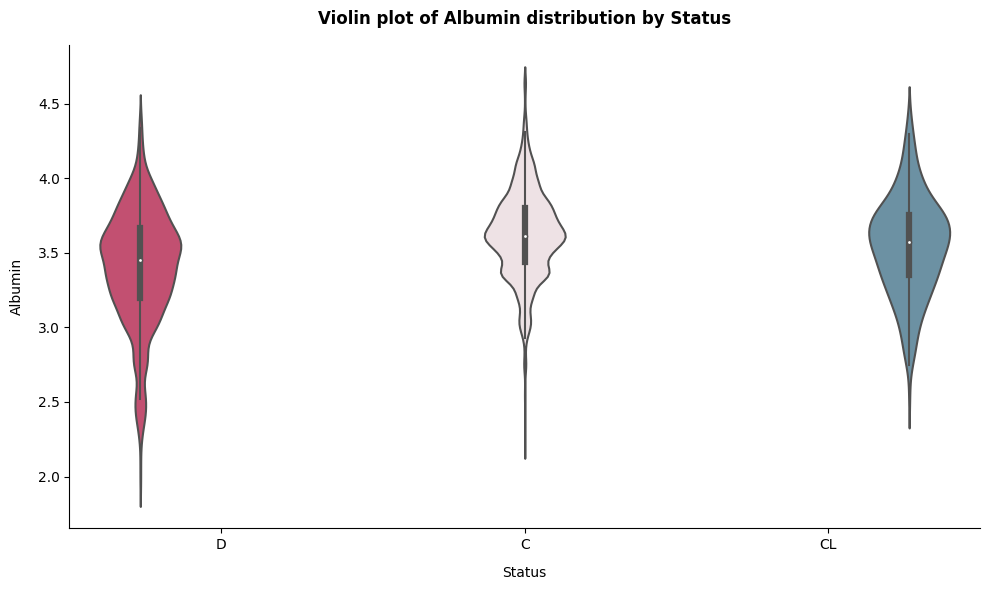

,Status,Count,Mean,Median,Std
0,D,2665,123.694934,101.000000,92.374342
1,CL,275,102.905455,89.000000,81.068988
2,C,4965,61.491641,50.000000,53.460053



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Copper


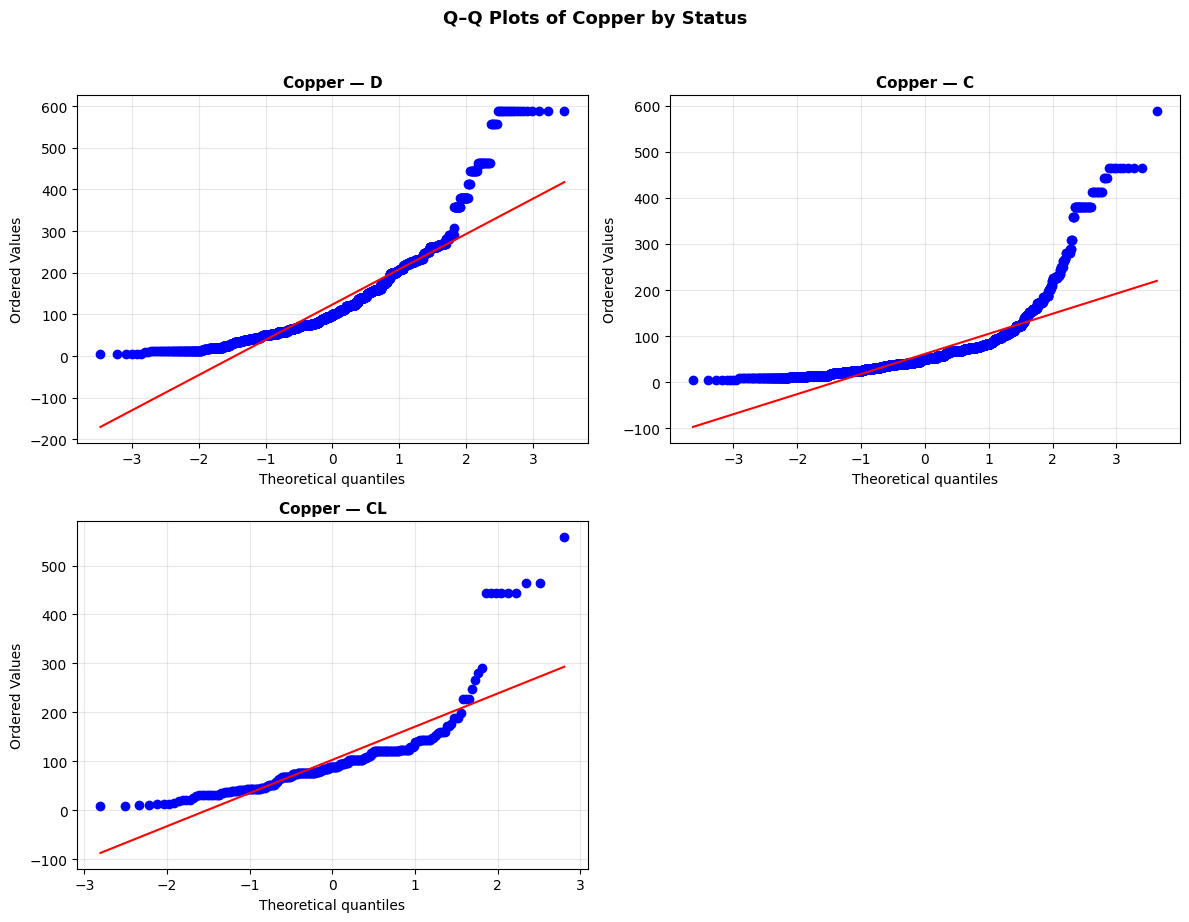

,Feature,Group,Skewness,Kurtosis,Remark
0,Copper,C,3.7372,19.8288,"Highly skewed, Heavy/light tails"
1,Copper,CL,2.9801,10.9342,"Highly skewed, Heavy/light tails"
2,Copper,D,1.9480,5.6292,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Copper ~ Status
Kruskal-Wallis H-statistic: 1525.188
p-value: 0.0
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               C            CL         D
C   1.000000e+00  9.336966e-36  0.000000
CL  9.336966e-36  1.000000e+00  0.075097
D   0.000000e+00  7.509655e-02  1.000000


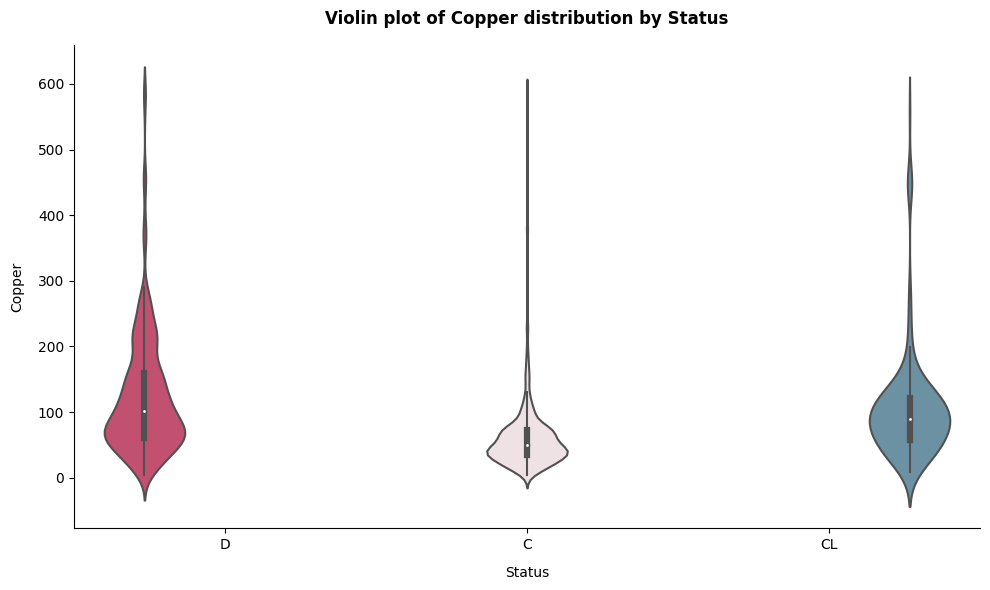

,Status,Count,Mean,Median,Std
0,D,2665,2226.068893,1580.000000,2097.469501
1,CL,275,1823.011636,1273.000000,1852.328676
2,C,4965,1596.690715,1082.000000,1755.570517



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Alk_Phos


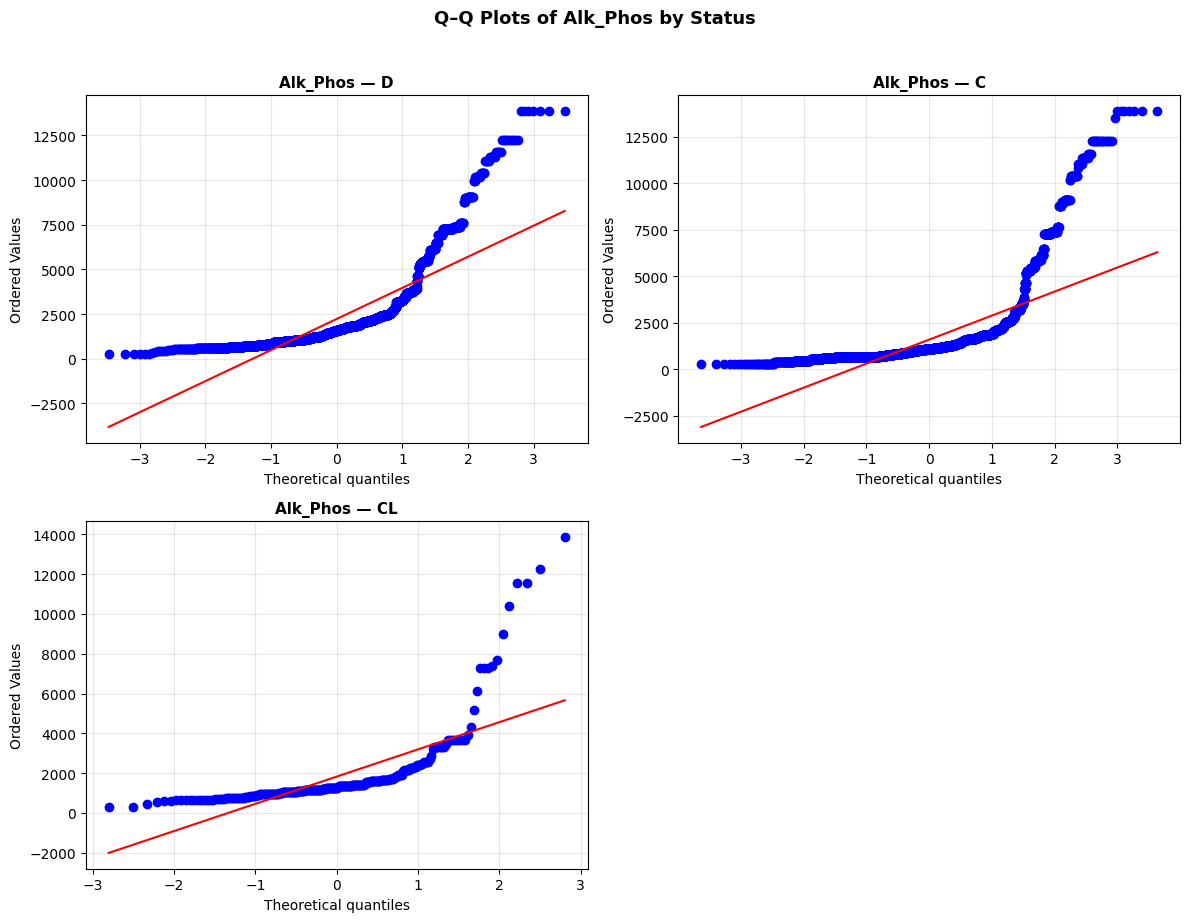

,Feature,Group,Skewness,Kurtosis,Remark
0,Alk_Phos,C,3.7325,15.8461,"Highly skewed, Heavy/light tails"
1,Alk_Phos,CL,3.8641,17.0600,"Highly skewed, Heavy/light tails"
2,Alk_Phos,D,2.5563,7.2963,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Alk_Phos ~ Status
Kruskal-Wallis H-statistic: 465.008
p-value: 1.0587526444026335e-101
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
                C            CL              D
C    1.000000e+00  2.318364e-07  2.663223e-101
CL   2.318364e-07  1.000000e+00   1.250731e-02
D   2.663223e-101  1.250731e-02   1.000000e+00


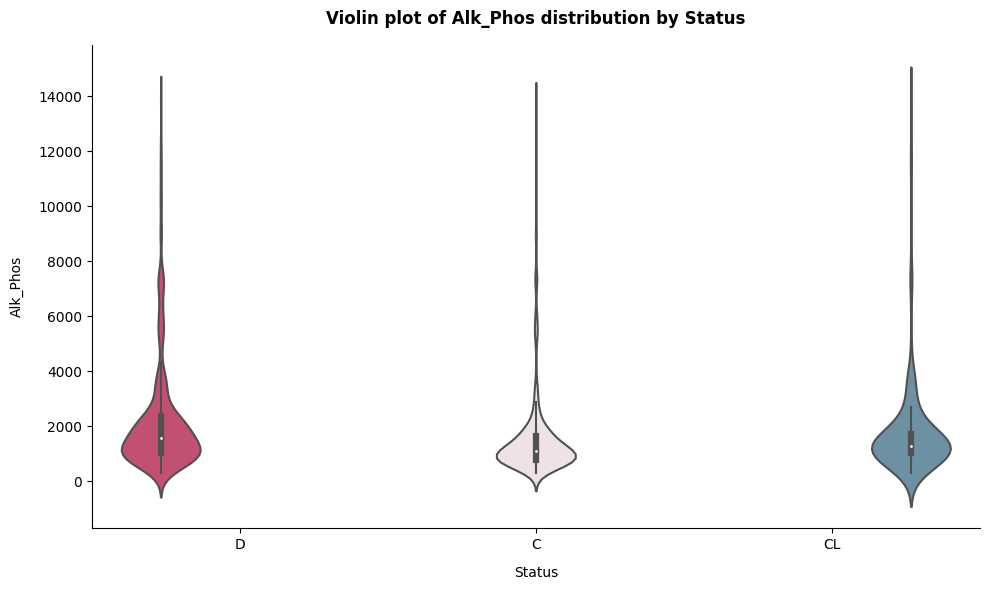

,Status,Count,Mean,Median,Std
0,D,2665,135.211276,130.200000,51.010147
1,CL,275,127.439673,120.900000,38.290316
2,C,4965,102.832914,93.000000,44.016247



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: SGOT


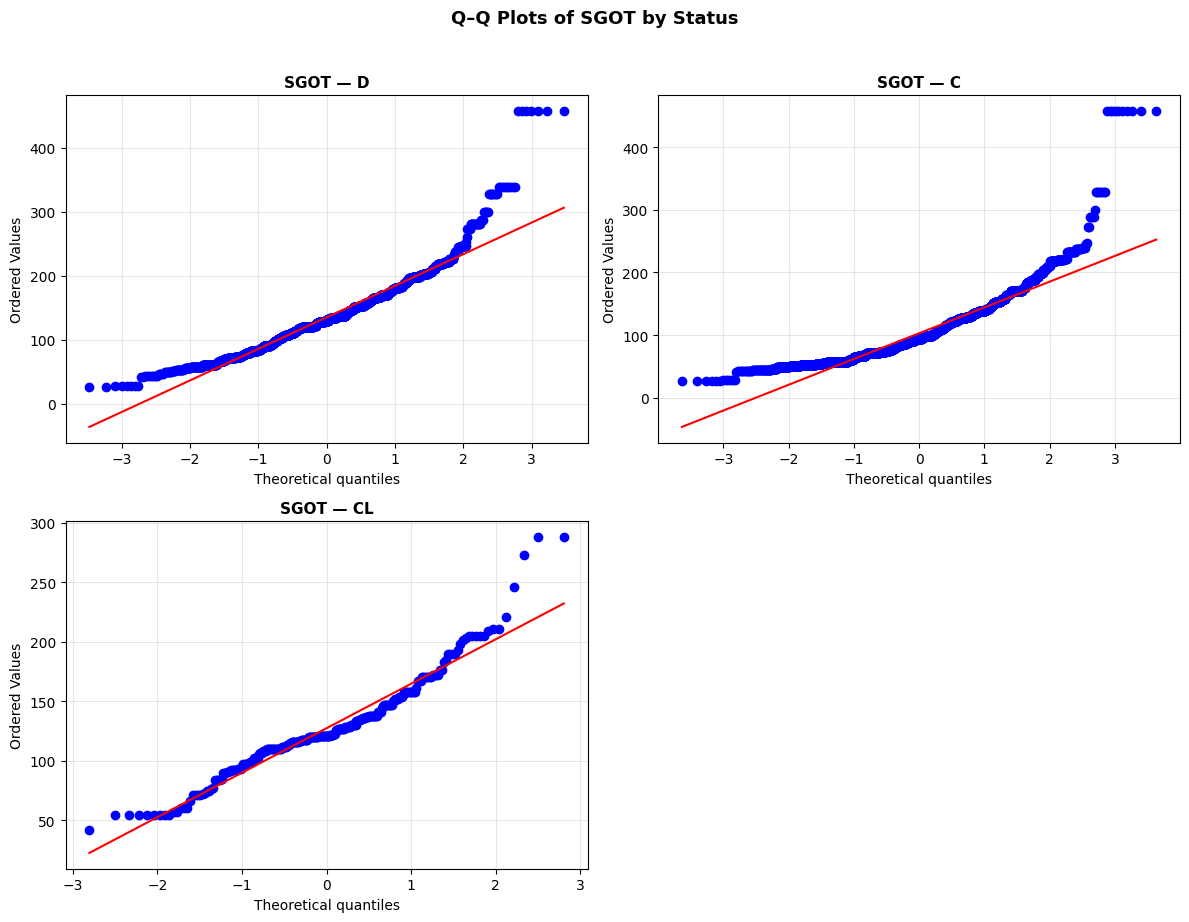

,Feature,Group,Skewness,Kurtosis,Remark
0,SGOT,C,1.9471,9.1611,"Highly skewed, Heavy/light tails"
1,SGOT,CL,0.9069,2.4243,"Moderately skewed, Heavy/light tails"
2,SGOT,D,1.2741,4.7242,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: SGOT ~ Status
Kruskal-Wallis H-statistic: 929.279
p-value: 1.620744421766132e-202
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
                C            CL              D
C    1.000000e+00  3.761435e-24  4.274573e-195
CL   3.761435e-24  1.000000e+00   5.900466e-01
D   4.274573e-195  5.900466e-01   1.000000e+00


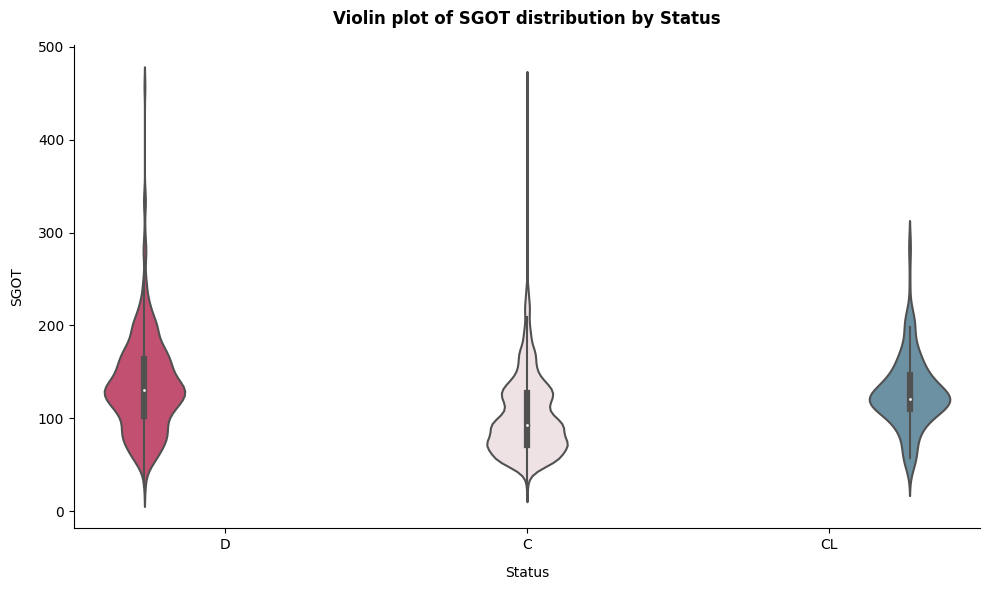

,Status,Count,Mean,Median,Std
0,D,2665,129.375985,114.000000,63.848272
1,CL,275,122.556364,118.000000,45.282966
2,C,4965,107.406647,101.000000,43.831604



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Tryglicerides


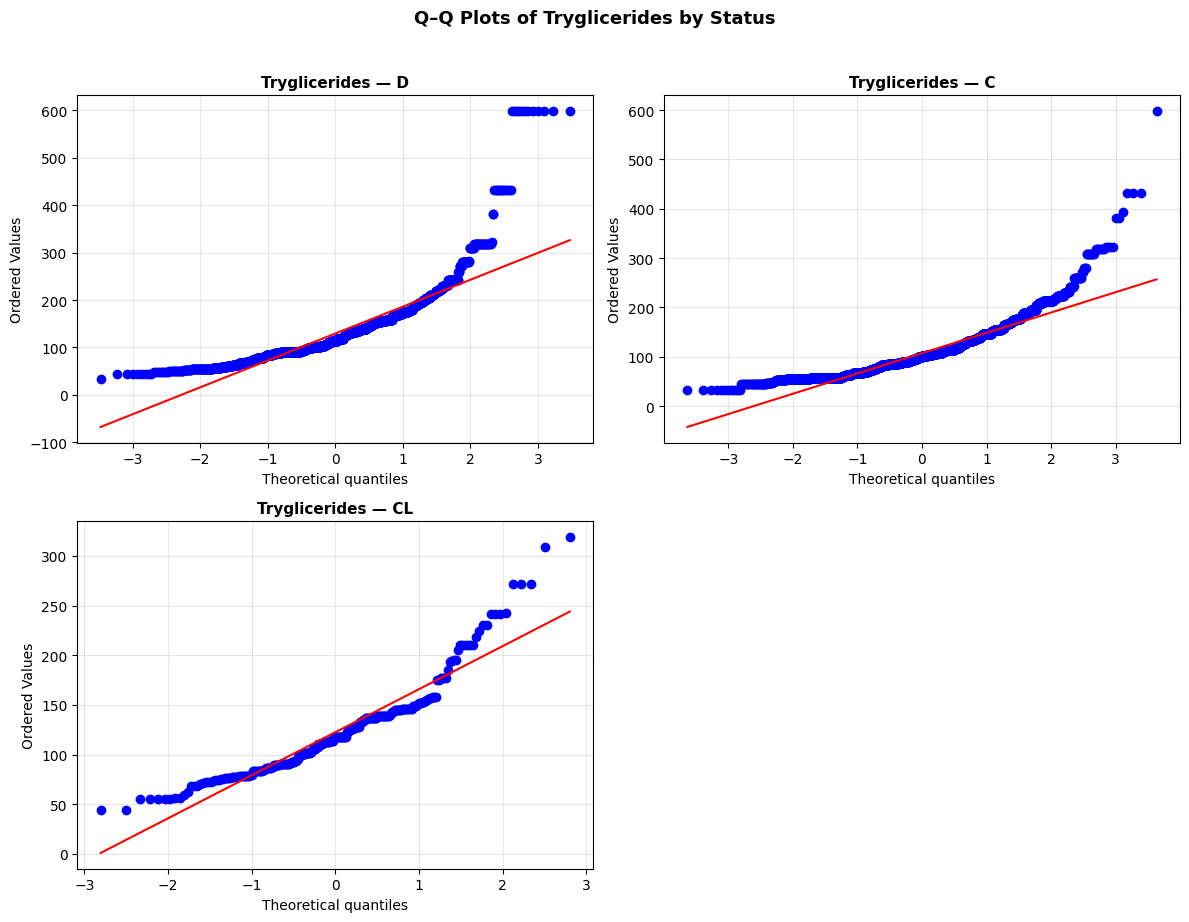

,Feature,Group,Skewness,Kurtosis,Remark
0,Tryglicerides,C,1.8289,7.7725,"Highly skewed, Heavy/light tails"
1,Tryglicerides,CL,1.3538,2.7153,"Highly skewed, Heavy/light tails"
2,Tryglicerides,D,2.8426,14.5676,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Tryglicerides ~ Status
Kruskal-Wallis H-statistic: 301.999
p-value: 2.6404557139102446e-66
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               C            CL             D
C   1.000000e+00  2.410007e-09  7.094578e-64
CL  2.410007e-09  1.000000e+00  1.000000e+00
D   7.094578e-64  1.000000e+00  1.000000e+00


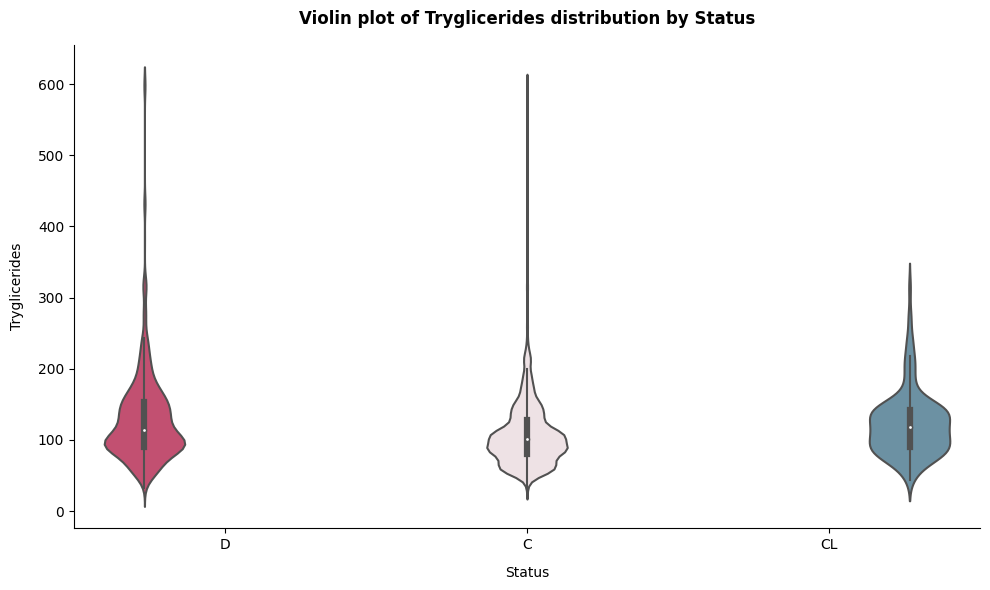

,Status,Count,Mean,Median,Std
0,CL,275,277.414545,271.000000,83.759447
1,C,4965,276.215106,271.000000,82.205897
2,D,2665,243.503940,228.000000,93.122026



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Platelets


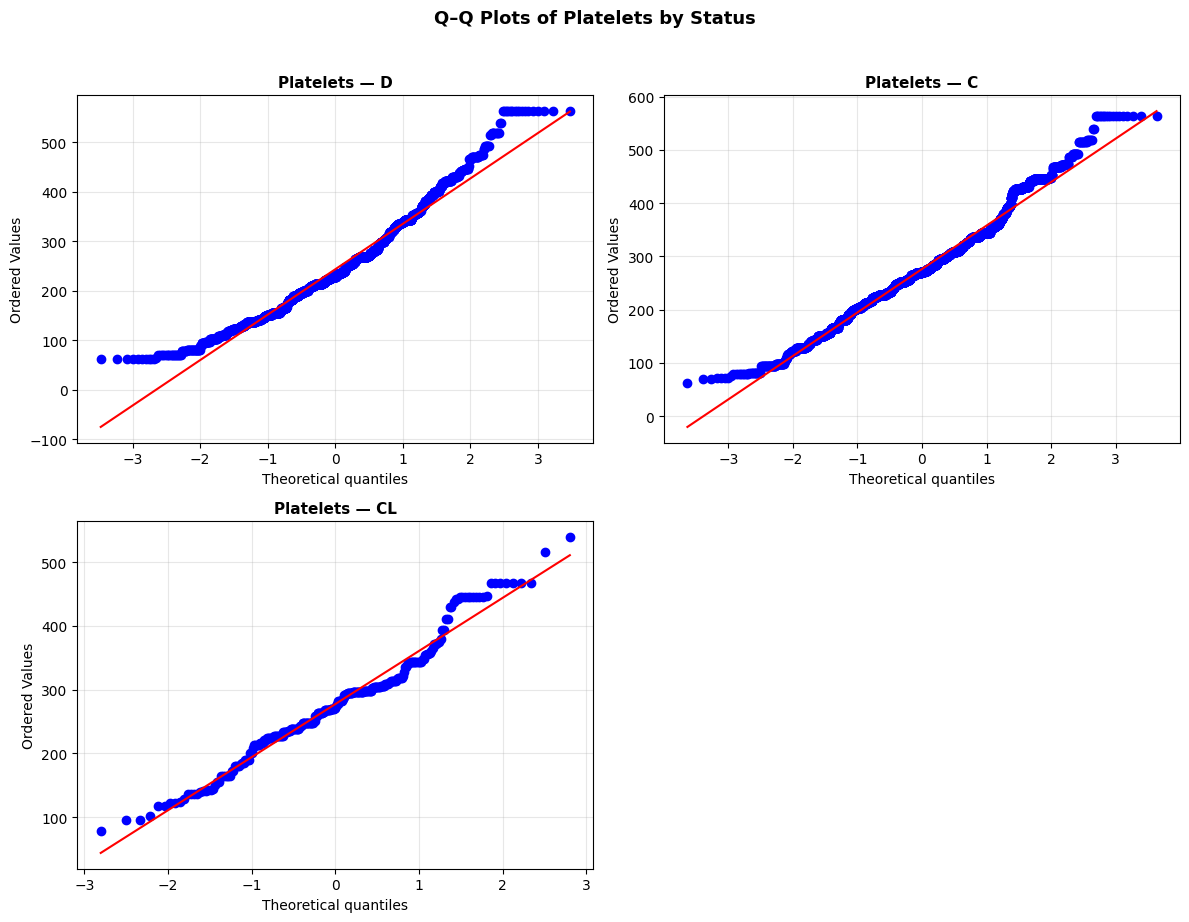

,Feature,Group,Skewness,Kurtosis,Remark
0,Platelets,C,0.3840,0.4764,"Approximately symmetric, Normal tails"
1,Platelets,CL,0.3808,0.3561,"Approximately symmetric, Normal tails"
2,Platelets,D,0.6746,0.4531,"Moderately skewed, Normal tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Platelets ~ Status
Kruskal-Wallis H-statistic: 319.009
p-value: 5.3466174983506617e-70
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
               C            CL             D
C   1.000000e+00  1.000000e+00  2.356662e-69
CL  1.000000e+00  1.000000e+00  1.387417e-11
D   2.356662e-69  1.387417e-11  1.000000e+00


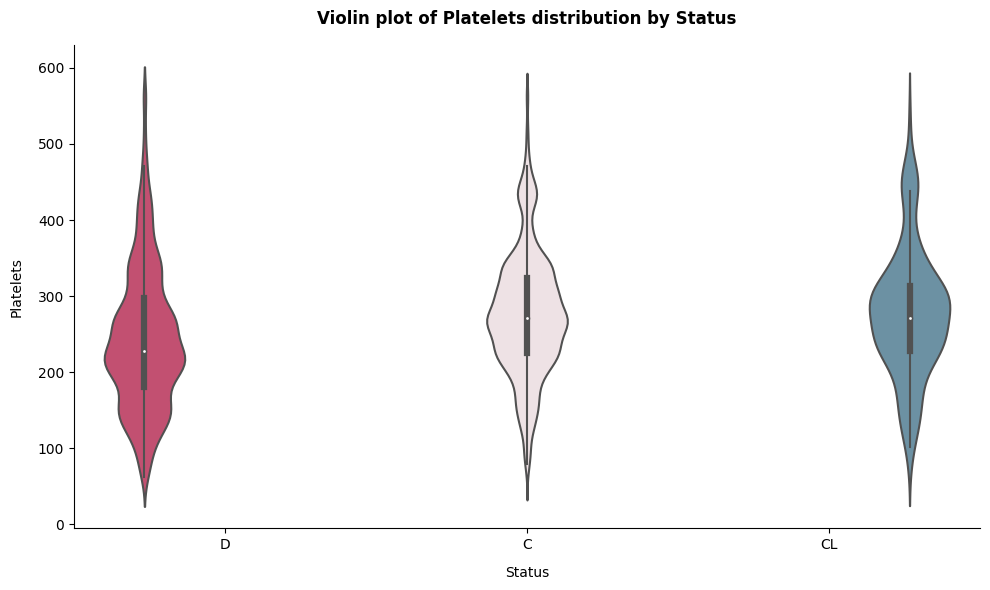

,Status,Count,Mean,Median,Std
0,D,2665,11.055797,11.000000,0.868020
1,CL,275,10.549091,10.600000,0.674746
2,C,4965,10.405076,10.400000,0.628701



 Checking normality of numeric feature(s) by target feature: 'Status'

🔹 Feature: Prothrombin


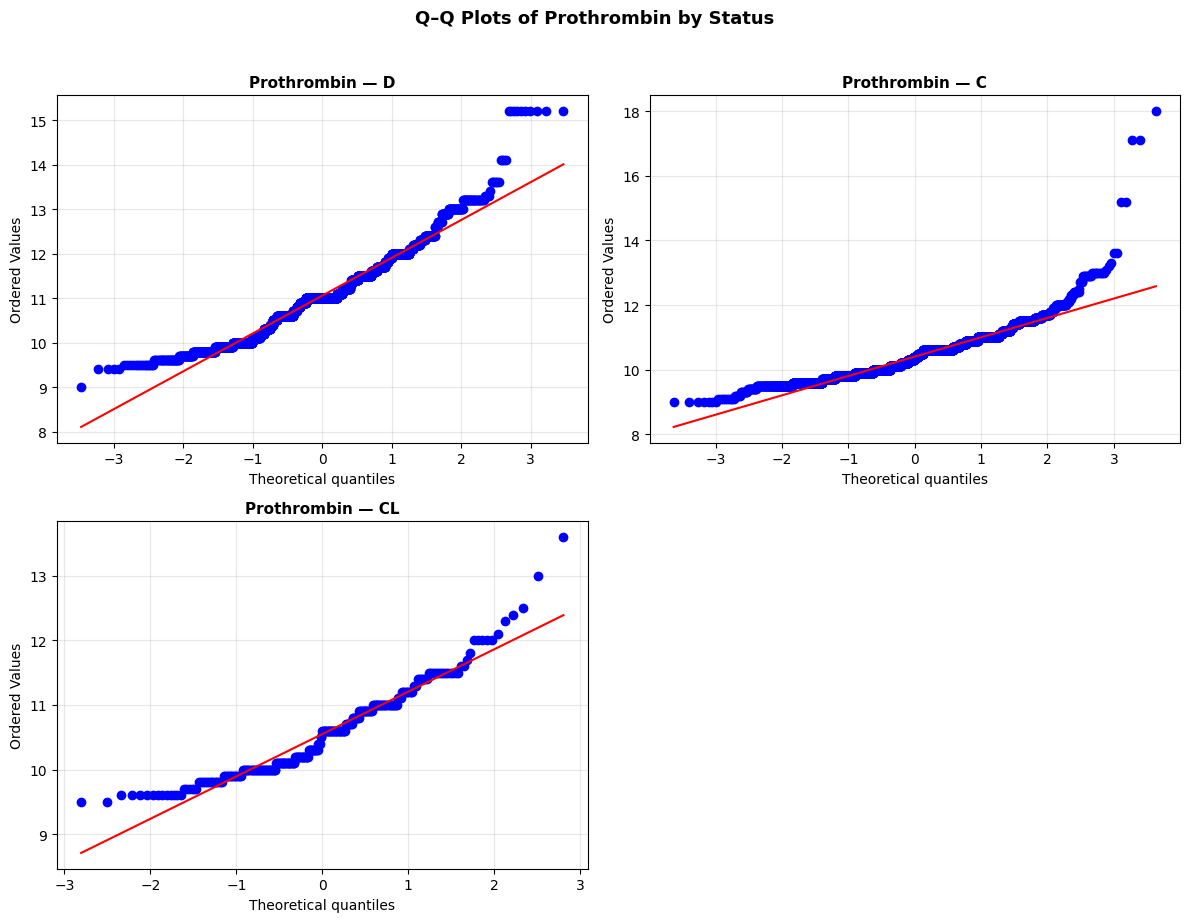

,Feature,Group,Skewness,Kurtosis,Remark
0,Prothrombin,C,1.6974,11.3713,"Highly skewed, Heavy/light tails"
1,Prothrombin,CL,0.9199,1.2301,"Moderately skewed, Normal tails"
2,Prothrombin,D,0.7700,1.5305,"Moderately skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...

🔍 Kruskal-Wallis Test: Prothrombin ~ Status
Kruskal-Wallis H-statistic: 1179.227
p-value: 8.593746919603145e-257
🟢 Significant difference found. Running Dunn's Post-Hoc Test...
                C            CL              D
C    1.000000e+00  1.486050e-03  1.193104e-257
CL   1.486050e-03  1.000000e+00   2.286497e-21
D   1.193104e-257  2.286497e-21   1.000000e+00


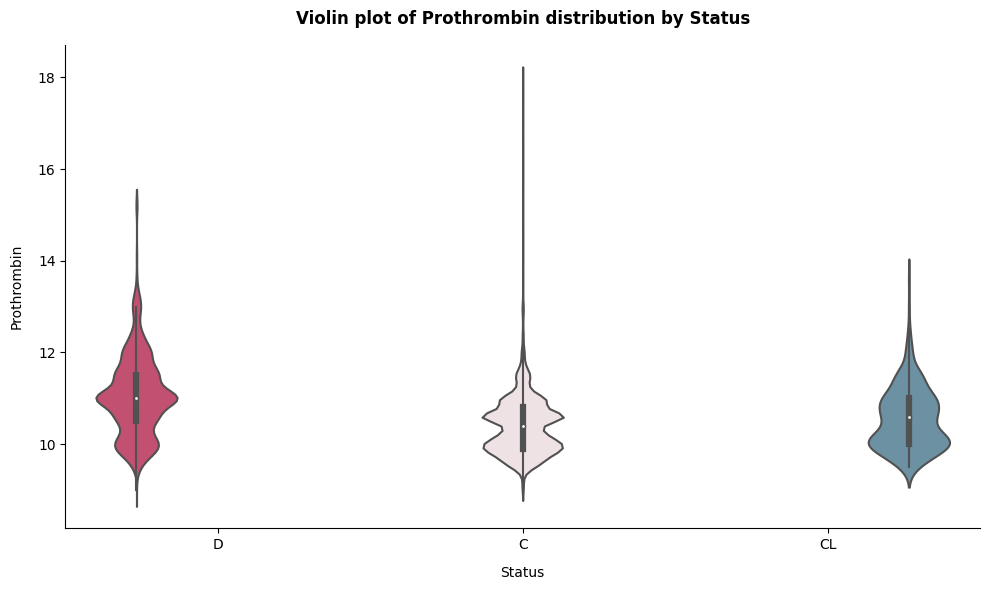

In [20]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df_train,  target_feature: str = "Status") -> None:
    """
    Perform statistical tests (normality and Kruskal-Wallis) 
    to evaluate whether there are significant differences 
    in the distribution of a numerical feature across categories 
    of the target variable.

    Args:
        feature (str): Name of the numerical feature to be tested.
        df (pd.DataFrame): Dataset containing both numerical and target columns.
        target_feature (str): Name of the target categorical feature.

    Returns:
        None: Prints or displays statistical test results.
    """
    # Perform normality test (e.g., Shapiro-Wilk or D’Agostino test) for feature distribution
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    total_categories = df[target_feature].nunique()
    if total_categories > 2:
        if non_normal_detected == True:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    else:
        if non_normal_detected == True:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df_train,
                                target_feature: str = "Status", order: list = None) -> None:
    """
    Perform statistical testing and visualize the distribution of a numerical feature 
    across different classes of the target variable using violin plots and summary statistics.

    The function executes:
      1. Statistical tests.
      2. Summary table with mean, median, std per category.
      3. Violin plot for visualizing feature distributions across classes.

    Args:
        feature (str): The name of the numerical feature to analyze.
        df (pd.DataFrame): Input dataframe containing numerical & target features.
        target_feature (str): Target variable name (categorical feature).
        order (list, optional): Custom ordering for category display in the plot.

    Returns:
        None: Displays statistical summaries and plots directly.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))
    
    plt.title(f"Violin plot of {feature} distribution by {target_feature}", pad=15, weight="bold")
    plt.xlabel(target_feature, labelpad=10)
    plt.ylabel(feature, labelpad=10)
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:green;'><b>Distribution of {feature} by Status</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df_train)

### Insight Numerical Features vs Status

`N_Days`

N_Days differs mainly between **C** and the other two groups, suggesting that **disease duration or treatment time** may influence patient status.

`Age`

Patient **age varies notably by status**, suggesting that **age may play an important role in disease progression or outcome.**

`Bilirubin`

Bilirubin levels are **significantly higher in group D** compared to the others, suggesting that **elevated Bilirubin is associated with worse disease status.**

`Cholesterol`

Cholesterol levels differ mainly between **group C** and the other two groups, suggesting that **cholesterol metabolism may change with disease progression.**

`Albumin`

Albumin levels differ significantly across all groups, suggesting that **decreasing albumin may indicate worsening liver function or disease severity.**

`Copper`

Copper levels are **elevated in group D**, while **C** shows much lower values, suggesting that **increased copper concentration may be linked to more severe disease stages.**

`Alk_Phos`

Alk_Phos levels are **substantially higher in group D**, suggesting a possible link between **elevated alkaline phosphatase and worsening liver condition.**

`SGOT`

SGOT levels are **notably higher in group D** and lower in group C, suggesting that **elevated SGOT may be a marker of more advanced liver damage.**

`Tryglicerides`

Tryglicerides levels are **notably elevated in group D** and **lower in group C**, suggesting that **higher triglyceride concentrations may be associated with disease progression.**

`Platelet`

Platelet levels are **lower in group D** compared to C and CL, suggesting that **decreasing platelet counts may indicate worsening disease severity.**

`Prothrombin`

Prothrombin levels are **highest in group D**, indicating **a potential relationship between prolonged clotting time and severe liver dysfunction.**

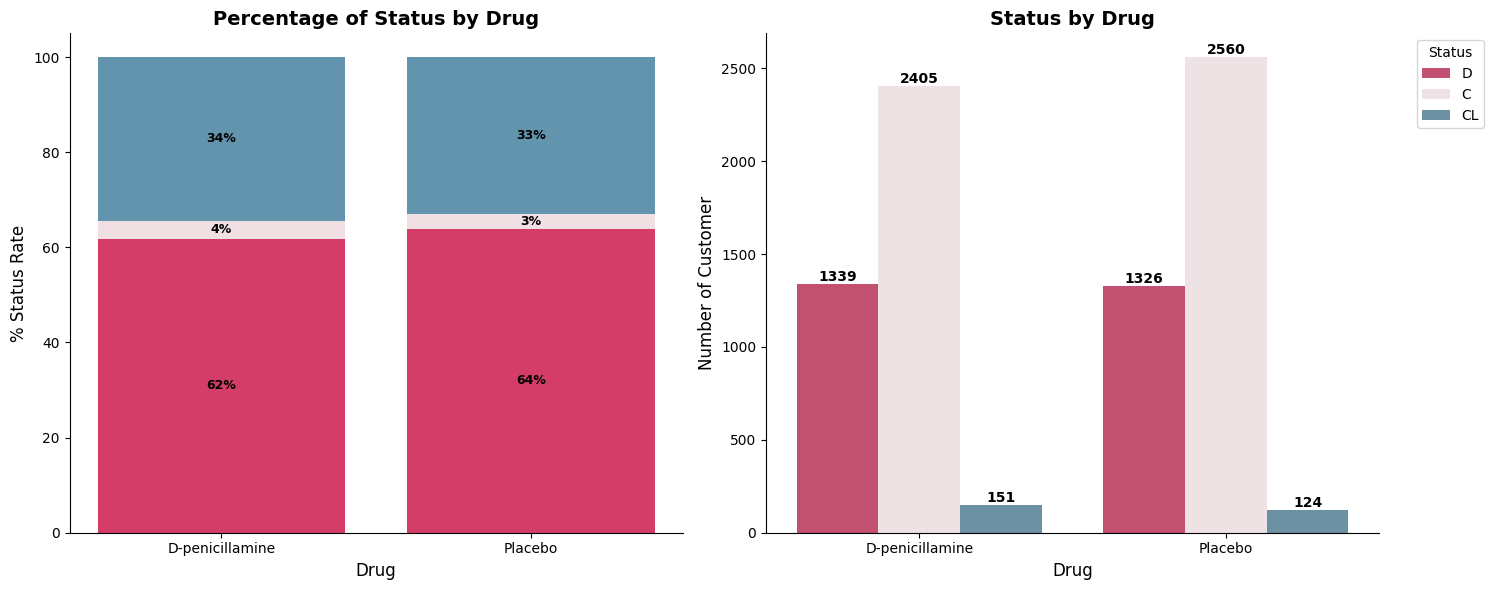


🔍 Chi-Square Test of Independence: 'Drug' vs. 'Status'
Chi-squared statistic: 5.881
Degrees of freedom: 2
p-value: 0.052827
❎ Result: p-value ≥ 0.05 → Fail to reject H₀
→ No statistically significant association between 'Drug' and 'Status'.

📈 Standardized Residuals:
Status              C    CL     D
Drug                             
D-penicillamine -0.84  1.33  0.71
Placebo          0.82 -1.31 -0.70


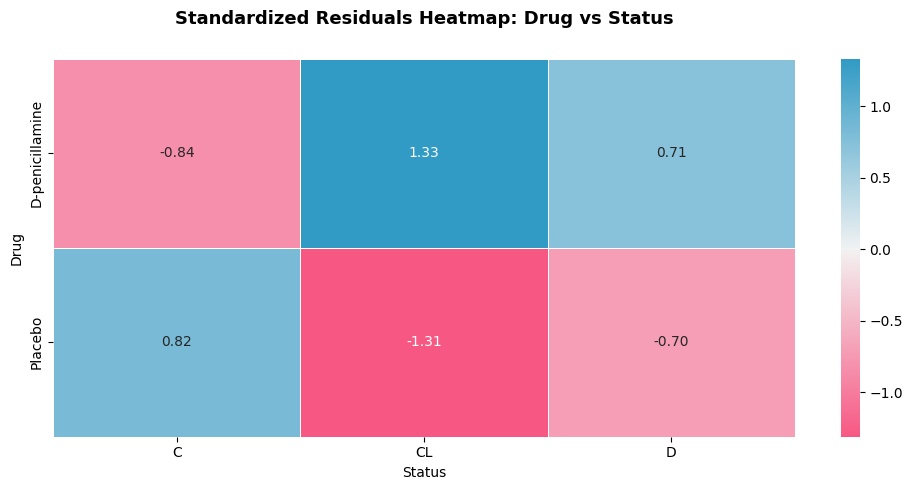

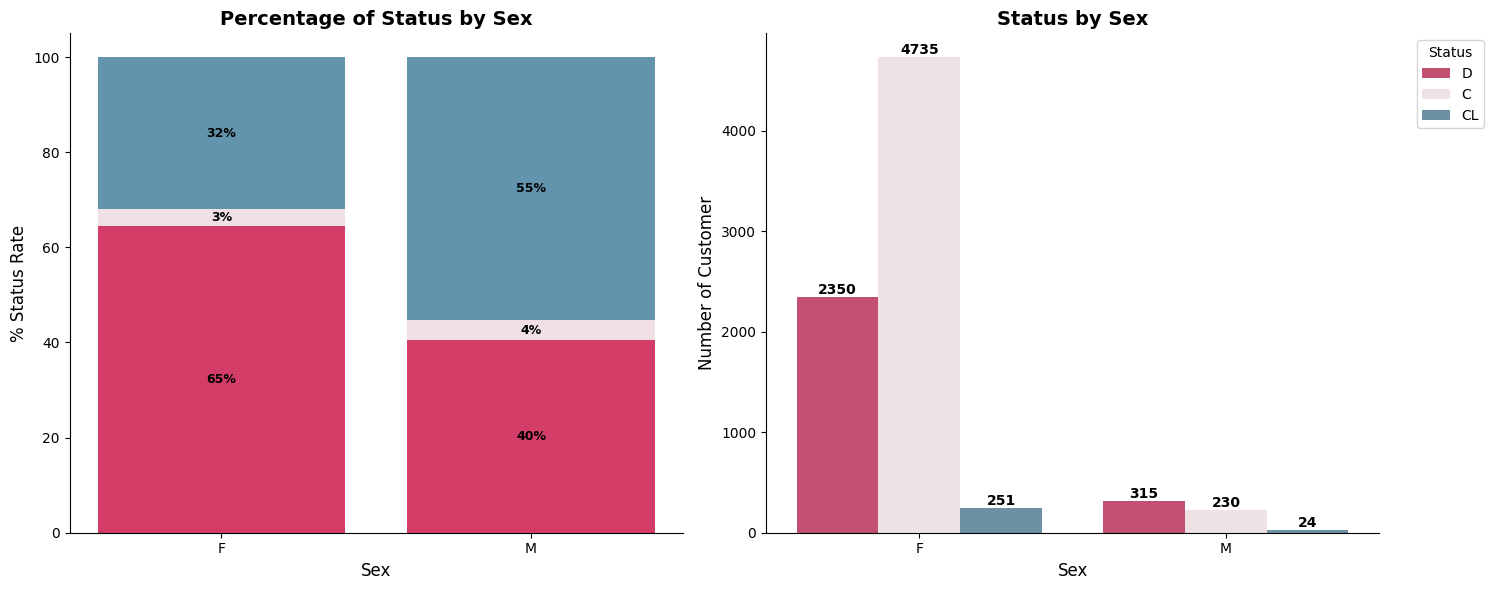


🔍 Chi-Square Test of Independence: 'Sex' vs. 'Status'
Chi-squared statistic: 135.112
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Sex' and 'Status'.

📈 Standardized Residuals:
Status     C    CL     D
Sex                     
F       1.88 -0.26 -2.48
M      -6.74  0.95  8.89


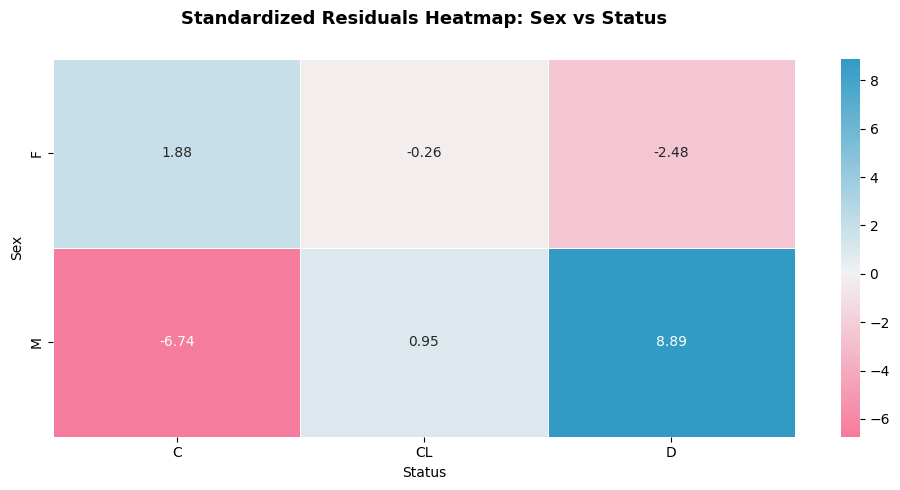

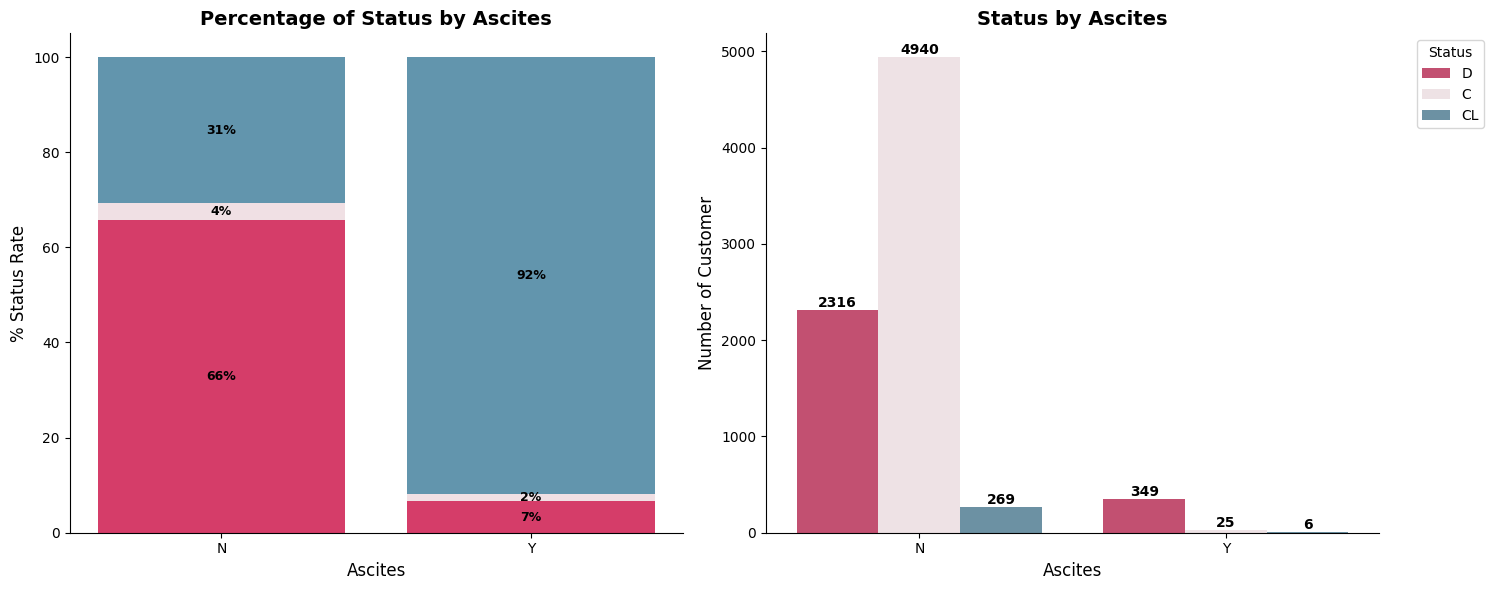


🔍 Chi-Square Test of Independence: 'Ascites' vs. 'Status'
Chi-squared statistic: 605.196
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Ascites' and 'Status'.

📈 Standardized Residuals:
Status       C    CL      D
Ascites                    
N         3.11  0.45  -4.39
Y       -13.83 -1.99  19.52


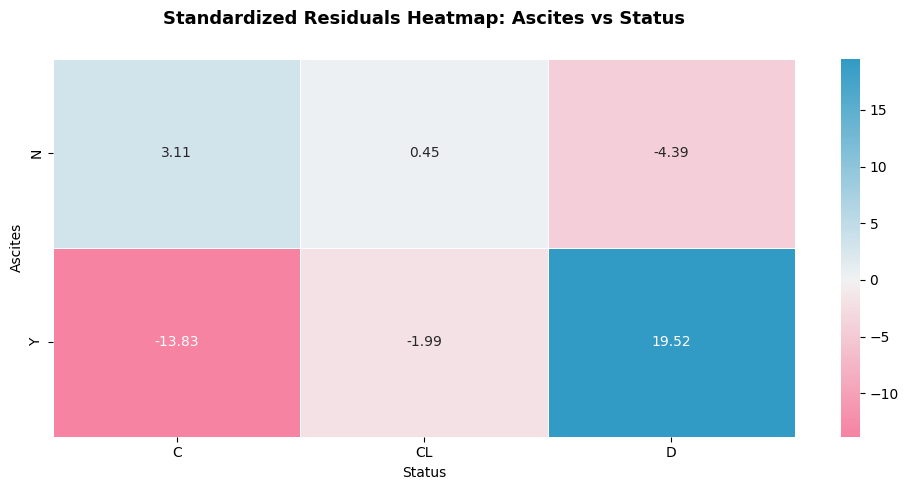

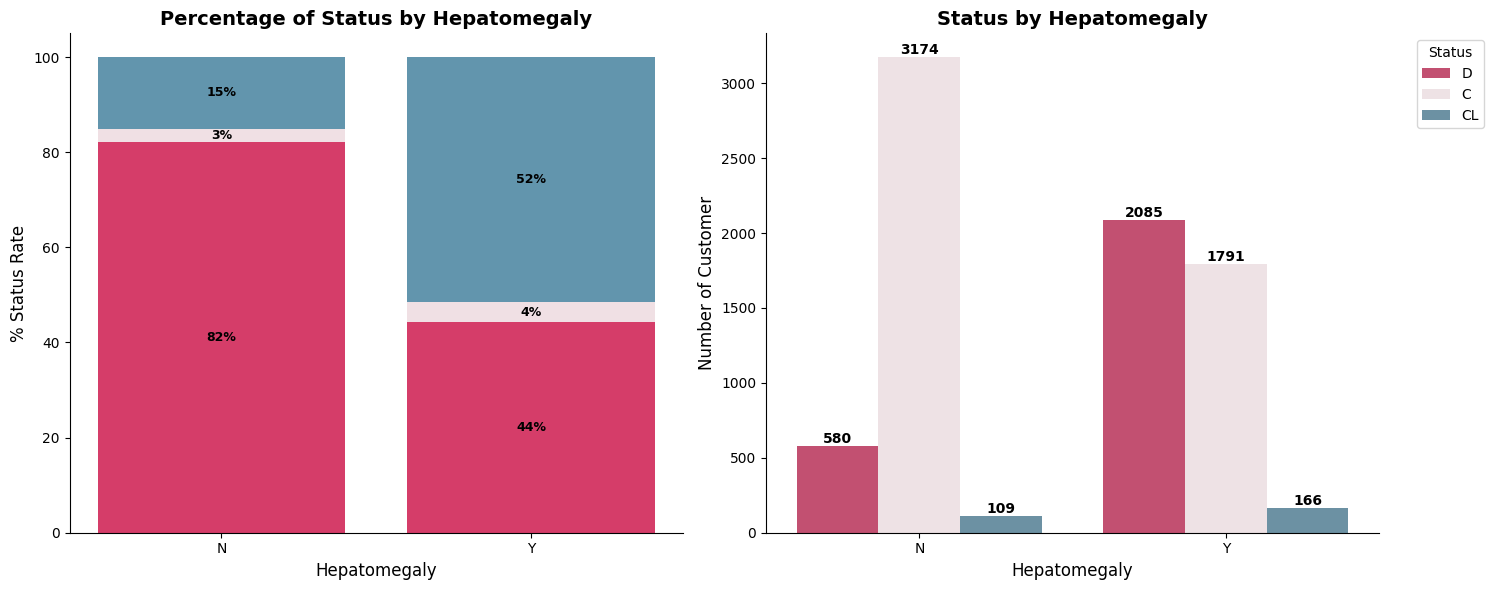


🔍 Chi-Square Test of Independence: 'Hepatomegaly' vs. 'Status'
Chi-squared statistic: 1243.549
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Hepatomegaly' and 'Status'.

📈 Standardized Residuals:
Status            C    CL      D
Hepatomegaly                    
N             15.18 -2.19 -20.02
Y            -14.84  2.14  19.57


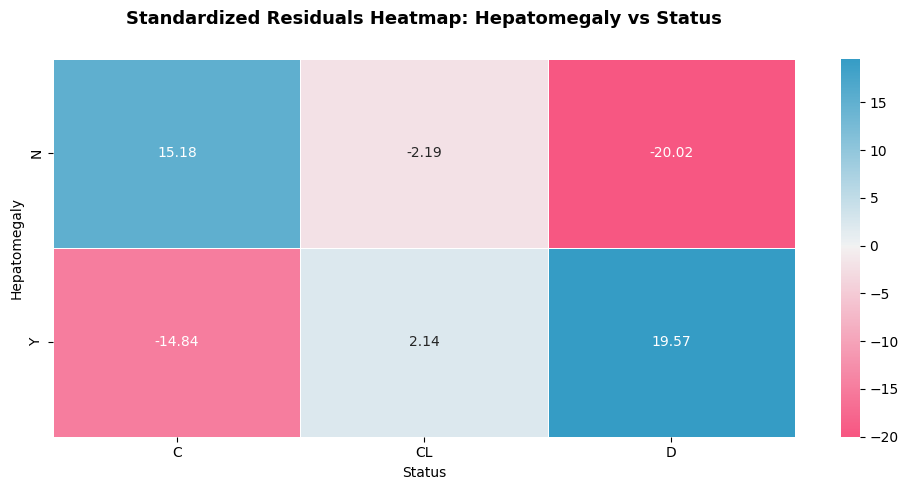

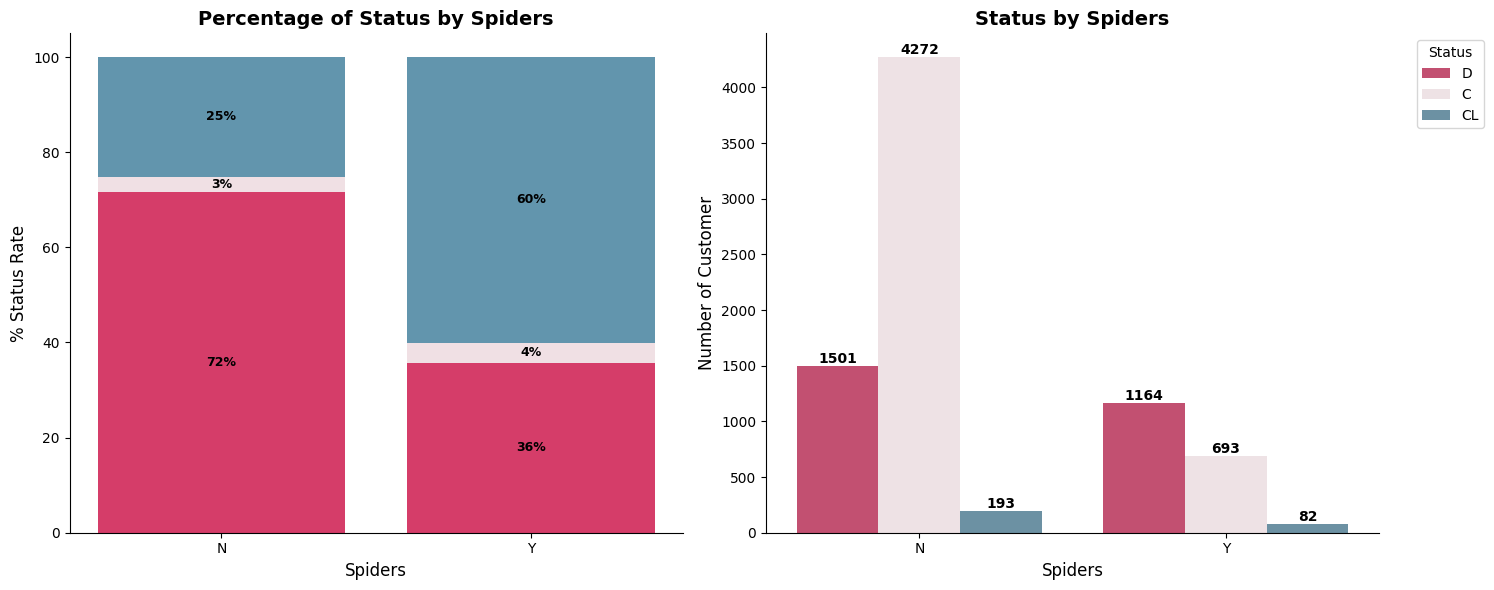


🔍 Chi-Square Test of Independence: 'Spiders' vs. 'Status'
Chi-squared statistic: 831.715
Degrees of freedom: 2
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Spiders' and 'Status'.

📈 Standardized Residuals:
Status       C    CL      D
Spiders                    
N         8.57 -1.01 -11.38
Y       -15.04  1.77  19.96


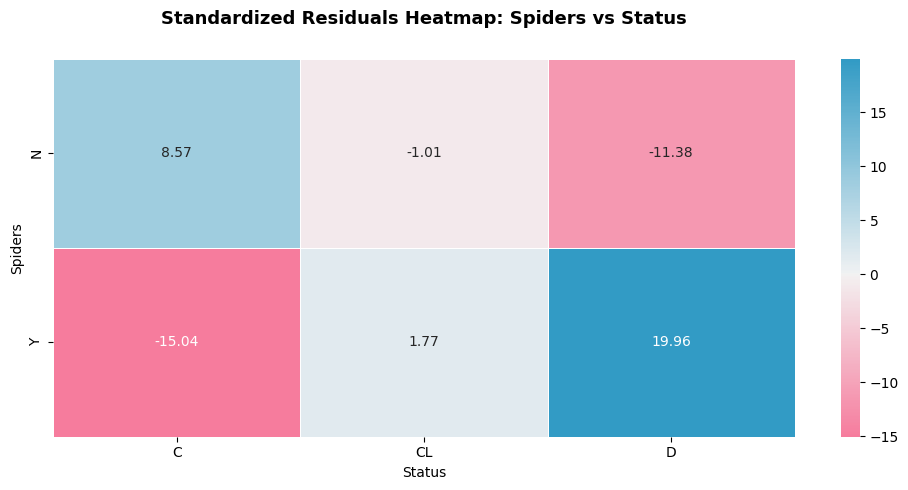

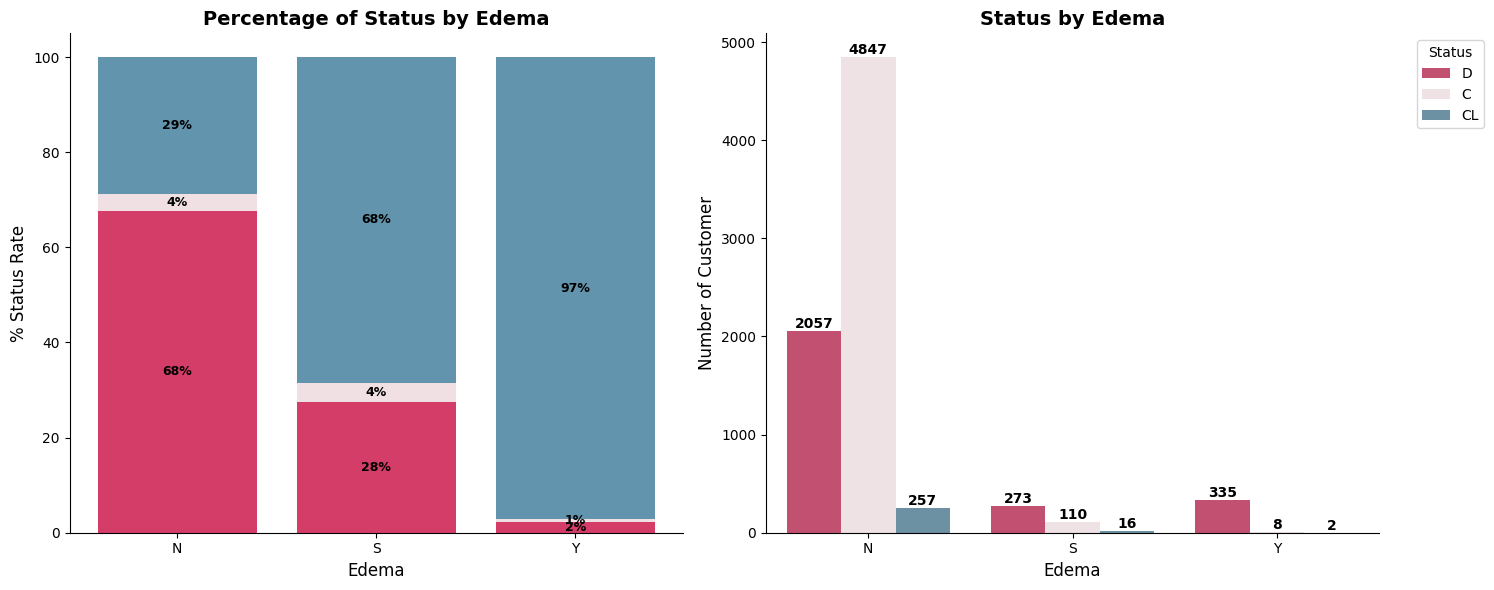


🔍 Chi-Square Test of Independence: 'Edema' vs. 'Status'
Chi-squared statistic: 922.519
Degrees of freedom: 4
p-value: 0.000000
✅ Result: p-value < 0.05 → Reject H₀
→ There is a **statistically significant association** between 'Edema' and 'Status'.

📈 Standardized Residuals:
Status      C    CL      D
Edema                     
N        5.21  0.50  -7.27
S       -8.88  0.57  11.94
Y      -14.18 -2.89  20.28


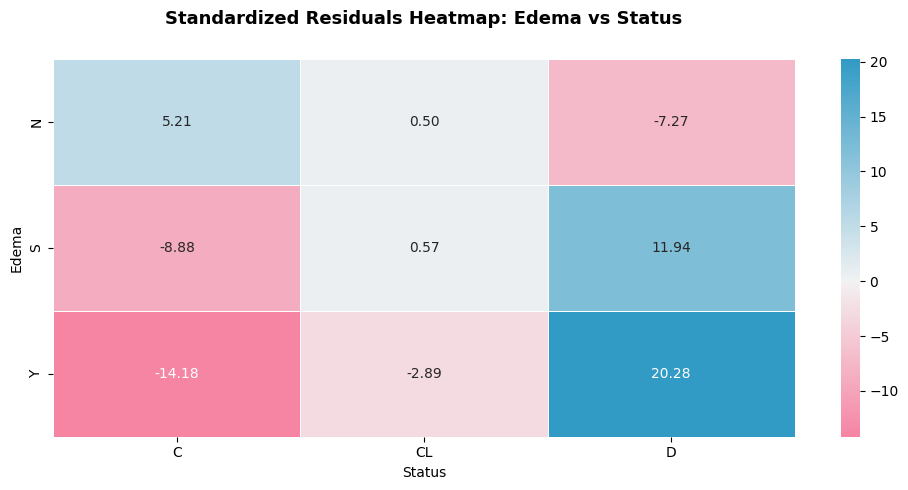

In [21]:
def bivariate_percent_plot(cat, target_feature, df, figsize=(15, 6), order=None):
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:green;'><b>Distribution of {cat} by {target_feature}</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)

    # === Data processing ===
    grouped = df.groupby([cat, target_feature]).size().unstack(fill_value=0)
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100
    if order is not None:
        percentages = percentages.loc[order]
        labels = order
    else:
        labels = percentages.index

    # === Use the same color palette as right chart ===
    palette = color(n_colors=df[target_feature].nunique())

    # Convert palette to dict for stacked bar color mapping
    color_map = dict(zip(percentages.columns, palette))

    # === Plot 1: Stacked bar chart (percentage) ===
    bottom = np.zeros(len(percentages))
    for fert in percentages.columns:
        ax[0].bar(percentages.index, percentages[fert], bottom=bottom, label=fert, color=color_map[fert])
        bottom += percentages[fert].values

    # Add percentage labels
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt="%1.0f%%", label_type="center", fontsize=9, color="black", weight="bold")

    ax[0].set_title(f"Percentage of {target_feature} by {cat}", fontsize=14, weight="bold")
    ax[0].set_xlabel(f"{cat}", fontsize=12)
    ax[0].set_ylabel(f"% {target_feature} Rate", fontsize=12)
    ax[0].set_xticklabels(labels=labels)
    sns.despine(left=False, bottom=False, ax=ax[0])
    ax[0].legend().remove()

    # === Plot 2: Count plot ===
    sns.countplot(data=df, hue=target_feature, x=cat, palette=palette, ax=ax[1], order=labels)
    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=10, weight="bold")
    ax[1].set_title(f"{target_feature} by {cat}", fontsize=14, weight="bold")
    ax[1].set_xlabel(f"{cat}", fontsize=12)
    ax[1].set_ylabel("Number of Customer", fontsize=12)
    ax[1].legend(title=target_feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    ax[1].set_xticklabels(labels=ax[1].get_xticklabels())
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    cal_ChiSquare(cat_feature=cat, target_feature=target_feature, df=df, show_residuals=True)

for feature in cat_features:
    bivariate_percent_plot(cat=feature, target_feature= "Status",df= df_train)

### Insight for Categorical Features vs Status

`Drug`

The type of drug administered (**D-penicillamine** or **Placebo**) does **not significantly affect the final status** of patients.

`Sex`

Male patients tend to have **worse outcomes (Status = D)**, while female patients show **better survival patterns.**

`Ascites`

The presence of **ascites** is **strongly linked to poorer outcomes (Status = D)**, making it a **critical clinical indicator of disease severity.**

`Hepatomegaly`

The presence of **hepatomegaly** is **strongly linked to poorer outcomes (Status = D)**, reinforcing its role as a **key clinical indicator of advanced disease progression.**

`Spiders`

The appearance of **spider angiomas** is **strongly correlated with worsening outcomes (Status = D)**, suggesting it as an **important visual marker of disease progression.**

`Edema`

The **severity of edema** is **strongly associated with poorer outcomes (Status = D)**, highlighting it as a **key indicator of disease progression and patient deterioration.**

### Overall Picture

| **Feature**       | **Type**    | **Statistical Test Used**        | **Summary**                                                                                                                            |
| ----------------- | ----------- | -------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **N_Days**        | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | Differences mainly between **C** and the other groups, suggesting **disease duration or treatment time may influence patient status**. |
| **Age**           | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Age varies notably by status**, indicating **older patients may experience worse disease outcomes**.                                 |
| **Bilirubin**     | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Significantly higher in group D**, implying **elevated bilirubin is linked to more severe disease status**.                          |
| **Cholesterol**   | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Mainly differs between group C and others**, suggesting **cholesterol metabolism may shift with disease progression**.               |
| **Albumin**       | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Decreases consistently across groups**, indicating **lower albumin as a marker of worsening liver function**.                        |
| **Copper**        | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Elevated in group D and low in C**, suggesting **copper accumulation correlates with disease severity**.                             |
| **Alk_Phos**      | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Substantially higher in group D**, implying **elevated ALP reflects advanced liver damage**.                                         |
| **SGOT**          | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Markedly higher in group D**, indicating **elevated SGOT as a sign of hepatocellular injury**.                                       |
| **Tryglicerides** | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Higher in group D, lower in C**, suggesting **lipid metabolism disturbance in advanced disease**.                                    |
| **Platelets**     | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Lower in group D**, implying **thrombocytopenia is a marker of worsening disease severity**.                                         |
| **Prothrombin**   | Numerical   | Kruskal–Wallis + Dunn’s Post-Hoc | **Highest in group D**, showing **prolonged clotting time relates to severe liver dysfunction**.                                       |
| **Drug**          | Categorical | Chi-Square Test of Independence  | **Type of drug (D-penicillamine vs Placebo)** does **not significantly affect patient outcomes**.                                      |
| **Sex**           | Categorical | Chi-Square Test of Independence  | **Male patients are more likely in group D**, suggesting **sex differences in disease progression**.                                   |
| **Ascites**       | Categorical | Chi-Square Test of Independence  | **Presence of ascites strongly predicts poorer outcomes (Status = D)** — a **critical marker of severity**.                            |
| **Hepatomegaly**  | Categorical | Chi-Square Test of Independence  | **Presence of hepatomegaly strongly linked to Status D**, confirming its role as a **key sign of advanced disease**.                   |
| **Spiders**       | Categorical | Chi-Square Test of Independence  | **Spider angiomas strongly correlated with Status D**, making them an **important visible indicator of progression**.                  |
| **Edema**         | Categorical | Chi-Square Test of Independence  | **Severity of edema strongly linked to poor outcomes**, highlighting it as a **major clinical indicator of deterioration**.            |


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Re-checking Skew

In [22]:
skew_feature_train, skew_train_df = check_skewness(df_train, "Train Data")
skew_feature_test, skew_test_df = check_skewness(df_test, "Test Data")


🔍 Skewness for Train Data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
Cholesterol                    |   +3.6797 | Highly skewed
Bilirubin                      |   +3.3397 | Highly skewed
Alk_Phos                       |   +3.1956 | Highly skewed
Copper                         |   +2.7017 | Highly skewed
Tryglicerides                  |   +2.6339 | Highly skewed
SGOT                           |   +1.5348 | Highly skewed
Prothrombin                    |   +1.2924 | Highly skewed
Albumin                        |   -0.5611 | Moderately skewed
N_Days                         |   +0.4487 | Approximately symmetric
Platelets                      |   +0.4200 | Approximately symmetric
Age                            |   +0.0841 | Approximately symmetric
----------------------------------------------------------------------

🔍 Skewness for Test Dat

In [23]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(
    df,
    zero_threshold=0.9,
    skew_threshold=0.5,
    num_features=None,
    exclude_cols=None
):
    """
    Handle skewed numerical features by applying appropriate transformations.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []

    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))

    transformed_cols = []
    dropped_cols     = []

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed

In [24]:
processed_train_df, transformed_columns, sparse_columns, skewed_columns = handle_skewed_features(df=df_train, num_features=skew_feature_train)
num_features = ["N_Days", "Age", "PT_Bilirubin", "PT_Cholesterol", "PT_Albumin", "PT_Copper", "PT_Alk_Phos", "PT_SGOT", "PT_Tryglicerides",
                "Platelets", "PT_Prothrombin"]
skew_feature_train, skew_train_df = check_skewness(processed_train_df, "Train Data", numerical_features=num_features)


🔍 Skewness for Train Data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
N_Days                         |   +0.4487 | Approximately symmetric
Platelets                      |   +0.4200 | Approximately symmetric
PT_Bilirubin                   |   +0.3561 | Approximately symmetric
Age                            |   +0.0841 | Approximately symmetric
PT_Cholesterol                 |   -0.0588 | Approximately symmetric
PT_Albumin                     |   +0.0528 | Approximately symmetric
PT_Prothrombin                 |   +0.0386 | Approximately symmetric
PT_Alk_Phos                    |   +0.0111 | Approximately symmetric
PT_Tryglicerides               |   -0.0035 | Approximately symmetric
PT_Copper                      |   -0.0006 | Approximately symmetric
PT_SGOT                        |   +0.0004 | Approximately symmetric
-------------------

In [25]:
processed_test_df, transformed_columns_test, sparse_columns_test, skewed_columns_test = handle_skewed_features(df=df_test, num_features=skew_feature_test)
skew_feature_test, skew_test_df = check_skewness(data=processed_test_df, numerical_features=num_features,
                                                   dataset_name= "Test data")


🔍 Skewness for Test data:
----------------------------------------------------------------------
Feature                        | Skewness  | Remark
----------------------------------------------------------------------
N_Days                         |   +0.4298 | Approximately symmetric
Platelets                      |   +0.4254 | Approximately symmetric
PT_Bilirubin                   |   +0.3584 | Approximately symmetric
PT_Cholesterol                 |   -0.0592 | Approximately symmetric
PT_Albumin                     |   +0.0345 | Approximately symmetric
PT_Prothrombin                 |   +0.0340 | Approximately symmetric
PT_Alk_Phos                    |   +0.0207 | Approximately symmetric
Age                            |   -0.0196 | Approximately symmetric
PT_Tryglicerides               |   -0.0046 | Approximately symmetric
PT_Copper                      |   -0.0009 | Approximately symmetric
PT_SGOT                        |   +0.0002 | Approximately symmetric
--------------------

**Observations from the Skewness Table (`processed_train_df` and `processed_test_df`):**

✅ **Approximately Symmetric**:

* Several features, such as:

  * `PT_Bilirubin`, `PT_Cholesterol`, `PT_Albumin`, `PT_Prothrombin`, `PT_Alk_Phos`, `PT_Tryglicerides`, `PT_Copper` and `PT_SGOT` close to zero.
  * This indicates that **Yeo-Johnson transformation was effective** for these features.

## Re-check Outliers

In [26]:
checking_outlier(list_feature=num_features, df=processed_train_df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,Age,36
1,PT_Cholesterol,133
2,PT_Albumin,194
3,PT_Copper,88
4,PT_Alk_Phos,63
5,PT_SGOT,37
6,PT_Tryglicerides,84
7,Platelets,114
8,PT_Prothrombin,23


In [27]:
checking_outlier(list_feature=num_features, df=processed_test_df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,Age,19
1,PT_Cholesterol,89
2,PT_Albumin,126
3,PT_Copper,81
4,PT_Alk_Phos,39
5,PT_SGOT,32
6,PT_Tryglicerides,42
7,Platelets,66
8,PT_Prothrombin,19


## Create Test Set

🔴 Suppose you chatted with experts who told you that the **Albumin** is a very important attribute to predict **Status**. <br>
🔴 We may want to ensure that the test set is representative of the various categories of study hours per day in the whole dataset. Since the study hours per day is a continuous numerical attribute, we first need to create an category attribute.

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

processed_train_df["Status"] = le.fit_transform(processed_train_df["Status"])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("🔹 Status → Status mapping:")
for name, code in label_mapping.items():
    print(f"{name:>10}  →  {code}")

🔹 Status → Status mapping:
         C  →  0
        CL  →  1
         D  →  2


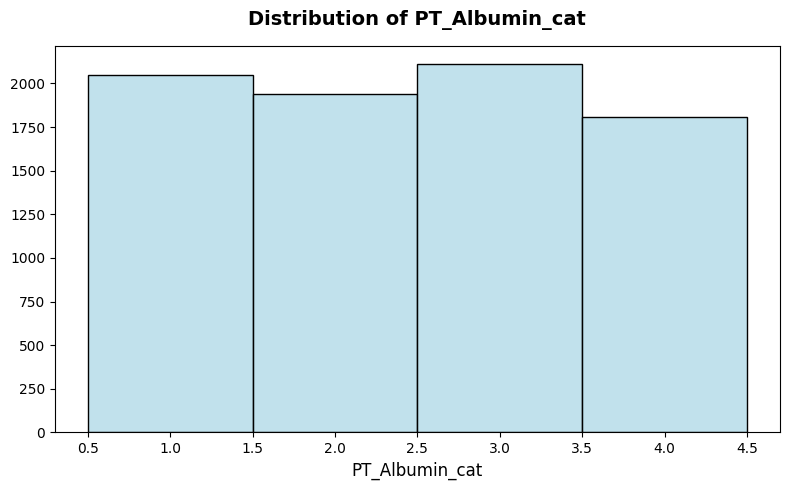

In [29]:
processed_train_df["PT_Albumin_cat"] = pd.qcut(processed_train_df["PT_Albumin"],
                                              q=4,
                                              labels=[1, 2, 3, 4])

plt.figure(figsize=(8, 5))
sns.histplot(data=processed_train_df, x="PT_Albumin_cat", color="lightblue", edgecolor="black")

plt.title("Distribution of PT_Albumin_cat", fontsize=14, pad=15, weight="bold")
plt.xlabel("PT_Albumin_cat", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [30]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in split.split(processed_train_df, processed_train_df["PT_Albumin_cat"]):
    start_train_set = processed_train_df.loc[train_index]
    start_val_set = processed_train_df.loc[val_index]

# Now we should remove the PT_Albumin_cat attribute so the data is back to its original state:
for set_ in (start_train_set, start_val_set): 
    set_.drop("PT_Albumin_cat", axis=1, inplace=True)

df_train_new = start_train_set.drop("Status", axis=1)
df_train_label = start_train_set["Status"].copy()

## Scale and Encode

In [31]:
# There are no **missing values** into dataset. But we will still handle missing values ​​to check the data in the future.
num_transfomer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transfomer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("encoder", OneHotEncoder(handle_unknown="ignore")) # Handling Text and Categorical Attributes
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transfomer, num_features),
        ("cat", cat_transfomer, cat_features),
    ]
)

preprocessor.fit(df_train_new)

df_train_new_prepared = preprocessor.transform(df_train_new)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num__", "").replace("cat__", "").replace("PT_", "") for col in list_feature_prepared]
clean_features

['N_Days',
 'Age',
 'Bilirubin',
 'Cholesterol',
 'Albumin',
 'Copper',
 'Alk_Phos',
 'SGOT',
 'Tryglicerides',
 'Platelets',
 'Prothrombin',
 'Drug_D-penicillamine',
 'Drug_Placebo',
 'Sex_F',
 'Sex_M',
 'Ascites_N',
 'Ascites_Y',
 'Hepatomegaly_N',
 'Hepatomegaly_Y',
 'Spiders_N',
 'Spiders_Y',
 'Edema_N',
 'Edema_S',
 'Edema_Y']

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Metric
    </h1>
</div>


**Evaluation Metric: Multi-class Logarithmic Loss (LogLoss)**

**Objective:**
To evaluate the accuracy of **predicted probabilities** rather than just predicted class labels.

**Formula:**

$$
\text{LogLoss} = -\frac{1}{N} \sum_{i=1}^{N}\sum_{j=1}^{M} y_{ij}\log(p_{ij})
$$
Where:

* ( N ): number of samples in the test set
* ( M ): number of classes (here: 3 — `C`, `CL`, `D`)
* ( y_{ij} = 1 ) if sample ( i ) belongs to class ( j ), otherwise ( 0 )
* ( p_{ij} ): predicted probability that sample ( i ) belongs to class ( j )

**Evaluation rule:**

* Lower LogLoss indicates **better model performance**.
* Predicted probabilities are **clipped** within [1e−15, 1−1e−15] to avoid log(0).
* LogLoss penalizes **confident but incorrect predictions** more heavily.

**Advantages:**

* Reflects how well a model’s **probability estimates are calibrated**.
* Suitable for **multi-class classification** tasks with softmax outputs.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation Using Cross-Validation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation Using Cross-Validation
    </h1>
</div>

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              ExtraTreesClassifier, AdaBoostClassifier, HistGradientBoostingClassifier)
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = [
    KNeighborsClassifier(),
    LogisticRegression(random_state=42, class_weight="balanced", max_iter=50000),
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    ExtraTreesClassifier(random_state=42, class_weight="balanced"),
    AdaBoostClassifier(random_state=42),
    XGBClassifier(random_state=42),
    MLPClassifier(random_state=42, max_iter=50000),
    GradientBoostingClassifier(random_state=42),
    CatBoostClassifier(verbose=0, random_seed=42, auto_class_weights="Balanced"),
    LGBMClassifier(random_state=42, verbosity=-1, class_weight="balanced"),
    HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
]

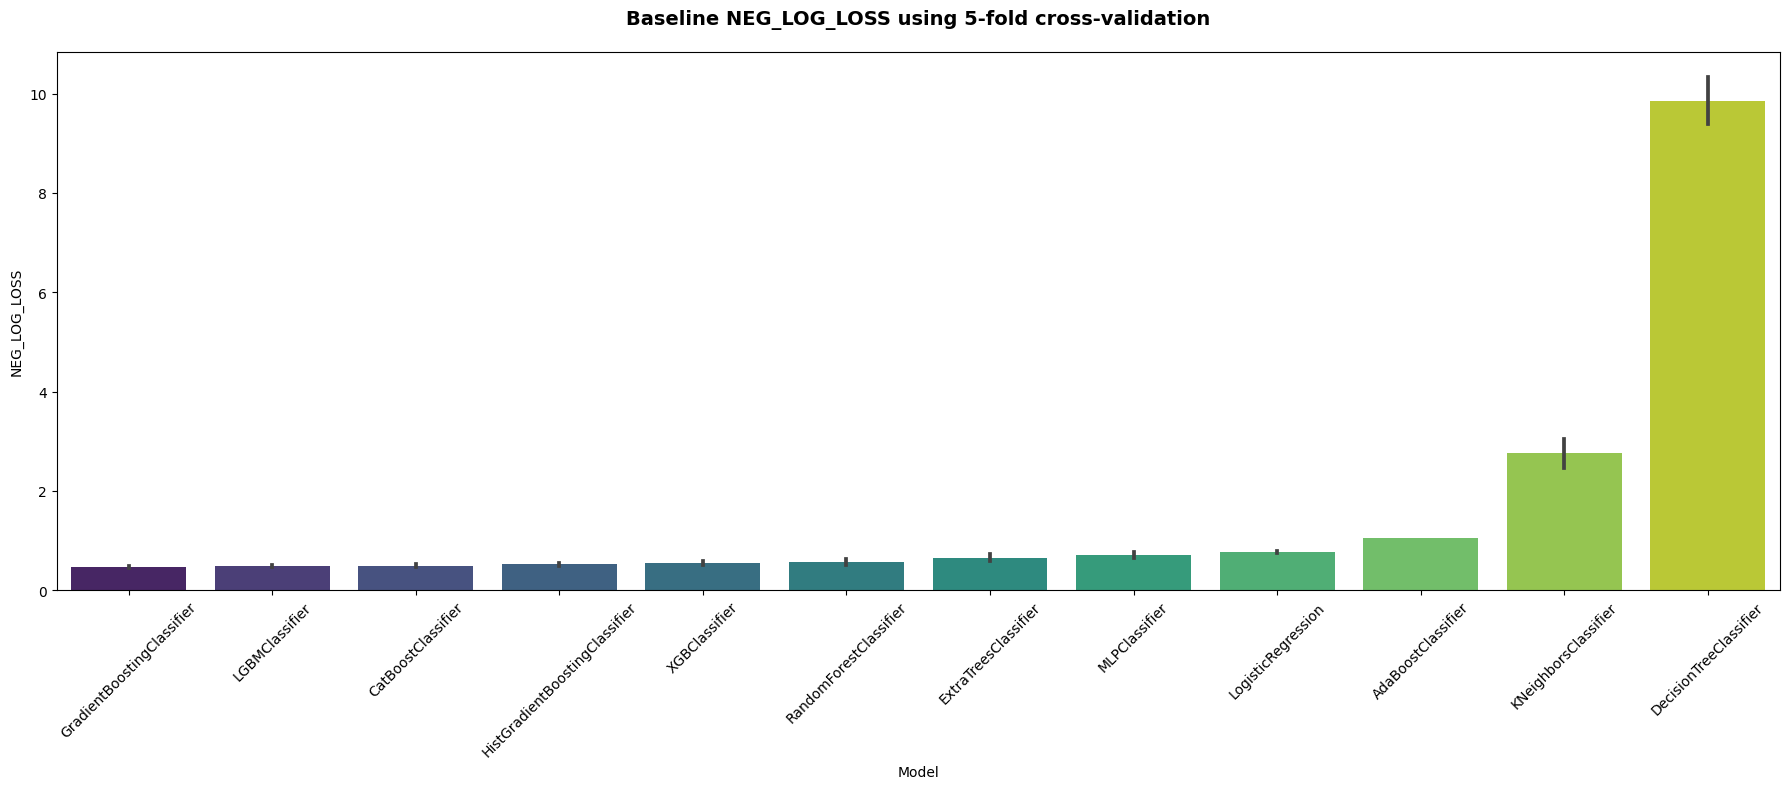

,Mean,Std,N
model_name,,,
GradientBoostingClassifier,0.461477,0.016896,5
LGBMClassifier,0.487359,0.027075,5
CatBoostClassifier,0.492586,0.025180,5
HistGradientBoostingClassifier,0.516972,0.030360,5
XGBClassifier,0.548732,0.037812,5
RandomForestClassifier,0.564480,0.065909,5
ExtraTreesClassifier,0.656264,0.060928,5
MLPClassifier,0.708911,0.062646,5
LogisticRegression,0.763746,0.015111,5


In [33]:
def generate_baseline_results(models=models, X=df_train_new_prepared, y=df_train_label,
                              metric="neg_log_loss", cv=kfold, plot_result=False):
    entries = []
    for model in models:
        model_name = getattr(model, "name", model.__class__.__name__)
        scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
        scores = -scores
        for fold_idx, s in enumerate(scores, start=1):
            entries.append((model_name, fold_idx, s))

    cv_df = pd.DataFrame(entries, columns=["model_name", "fold_id", "score"])

    summary = (cv_df.groupby("model_name")["score"]
                    .agg(Mean="mean", Std="std", N="size")
                    .sort_values("Mean", ascending=True))

    if plot_result:
        order = summary.index.tolist()
        plt.figure(figsize=(18, 8))
        sns.barplot(data=cv_df, x="model_name", y="score", order=order, errorbar=("sd"), palette="viridis")
        title_metric = metric.upper() if isinstance(metric, str) else "Score"
        nfolds = getattr(cv, "n_splits", "CV")
        plt.title(f"Baseline {title_metric} using {nfolds}-fold cross-validation", fontsize=14, weight="bold", pad=20)
        plt.xlabel("Model"); plt.ylabel(title_metric)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    return summary

generate_baseline_results(plot_result = True)

**Conclusion**

Boosting-based models (**GradientBoosting, LGBM, CatBoost**) clearly outperform others, suggesting that **the relationship between predictors and disease status is highly nonlinear**.
→ **Recommendation:** use **LGBM** or **CatBoost** as the primary baselines for further hyperparameter tuning.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Hyper-parameter Tunning</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Hyper-parameter Tunning
    </h1>
</div>

In [34]:
def shap_plot(model, X_test, list_feature, type = None):
     # https://towardsdatascience.com/using-shap-values-to-explain-how-your-machine-learning-model-works-732b3f40e137/
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()
    X_test_sample = pd.DataFrame(X_test, columns=list_feature)
    explainer = shap.Explainer(model.predict, X_test_sample)
    shap_values = explainer(X_test_sample)
    if type =="bar":
        shap_importance = np.abs(shap_values.values).mean(axis=0)
        shap_df = pd.DataFrame({"feature": X_test_sample.columns, "importance": shap_importance})
        shap_df = shap_df.sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=shap_df["importance"], y=shap_df["feature"], palette="viridis", order=shap_df["feature"])
        plt.xlabel("mean(|SHAP value|)")
        plt.title("SHAP Feature Importance", fontsize=14, weight="bold", pad=20)
        plt.tight_layout()
        plt.show()
    else:
        shap.summary_plot(shap_values, X_test_sample)

In [35]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score

def _get_scores(estimator, X):
    """Return y_score for plotting curves."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)
    elif hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    else:
        raise ValueError("Estimator does not support predict_proba or decision_function.")


def plot_ROC_confusionMatrix(estimator, X_val, y_val, figsize=(15, 6)):
    """
    Visualization layout:
    - [0,0]: ROC (Binary or Multiclass OvR)
    - [0,1]: Confusion Matrix
    - [1,0]: Precision-Recall (Binary or Multiclass OvR)
    - [1,1]: hidden
    """
    y_pred = estimator.predict(X_val)
    classes = np.array(sorted(np.unique(y_val)))
    n_classes = len(classes)

    y_score = _get_scores(estimator, X_val)

    # ===== Normalize binary shape =====
    if n_classes == 2:
        if y_score.ndim == 1:
            pos_scores = y_score
        elif y_score.ndim == 2 and y_score.shape[1] == 2:
            pos_scores = y_score[:, 1]
        elif y_score.ndim == 2 and y_score.shape[1] == 1:
            pos_scores = y_score[:, 0]
        else:
            pos_scores = y_score[:, -1]
    else:
        if y_score.ndim == 1:
            raise ValueError("Multiclass requires 2D y_score (n_samples, n_classes).")
        if hasattr(estimator, "classes_"):
            order = [np.where(estimator.classes_ == c)[0][0] for c in classes]
            y_score = y_score[:, order]

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=figsize)

    # ===== (1) ROC curve =====
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_val, pos_scores, pos_label=classes.max())
        roc_auc = roc_auc_score(y_val, pos_scores)
        ax[0, 0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        ax[0, 0].plot([0, 1], [0, 1], linestyle="--")
        ax[0, 0].set_title("ROC Curve (Binary)", fontsize=13, weight="bold", pad=14)
        roc_auc_macro = float(roc_auc)
    else:
        y_val_bin = label_binarize(y_val, classes=classes)
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        roc_auc_macro = float(np.mean([roc_auc[i] for i in range(n_classes)]))

        order = np.argsort([roc_auc[i] for i in range(n_classes)])
        picks = [order[0], order[n_classes // 2], order[-1]] if n_classes >= 3 else list(range(n_classes))
        for i in picks:
            ax[0, 0].plot(fpr[i], tpr[i], label=f"class {classes[i]} AUC = {roc_auc[i]:.3f}")

        ax[0, 0].plot([0, 1], [0, 1], linestyle="--")
        ax[0, 0].set_title(f"ROC Curve (Multiclass, macro AUC = {roc_auc_macro:.3f})", fontsize=13, weight="bold", pad=14)
    ax[0, 0].set_xlabel("False Positive Rate")
    ax[0, 0].set_ylabel("True Positive Rate")
    ax[0, 0].legend(loc="lower right")

    # ===== (2) Confusion Matrix =====
    cm = confusion_matrix(y_val, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0, 1],
                xticklabels=classes, yticklabels=classes)
    ax[0, 1].set_title("Confusion Matrix", fontsize=13, weight="bold", pad=14)
    ax[0, 1].set_xlabel("Predicted")
    ax[0, 1].set_ylabel("Actual")

    # ===== (3) Precision–Recall curve =====
    if n_classes == 2:
        precision_curve, recall_curve, _ = precision_recall_curve(y_val, pos_scores, pos_label=classes.max())
        pr_ap = average_precision_score(y_val, pos_scores)
        ax[1, 0].plot(recall_curve, precision_curve, label=f"AP = {pr_ap:.3f}")
        pr_auc_macro = float(pr_ap)
        ax[1, 0].set_title("Precision–Recall (Binary)", fontsize=13, weight="bold", pad=14)
    else:
        y_val_bin = label_binarize(y_val, classes=classes)
        precision, recall, pr_ap = {}, {}, {}
        for i in range(n_classes):
            precision[i], recall[i], _ = precision_recall_curve(y_val_bin[:, i], y_score[:, i])
            pr_ap[i] = average_precision_score(y_val_bin[:, i], y_score[:, i])

        pr_auc_macro = float(np.mean([pr_ap[i] for i in range(n_classes)]))

        order_pr = np.argsort([pr_ap[i] for i in range(n_classes)])
        picks_pr = [order_pr[0], order_pr[n_classes // 2], order_pr[-1]] if n_classes >= 3 else list(range(n_classes))
        for i in picks_pr:
            ax[1, 0].plot(recall[i], precision[i], label=f"class {classes[i]} AP = {pr_ap[i]:.3f}")

        ax[1, 0].set_title(f"Precision–Recall (Multiclass, macro AP = {pr_auc_macro:.3f})", fontsize=13, weight="bold", pad=14)

    ax[1, 0].set_xlabel("Recall")
    ax[1, 0].set_ylabel("Precision")
    ax[1, 0].legend(loc="lower left")

    # ===== (4) Hide empty cell =====
    ax.flat[-1].set_visible(False)
    plt.tight_layout()
    plt.show()

    # ===== Classification Report =====
    print(classification_report(y_val, y_pred, digits=3))

    metrics = {
        "roc_auc_macro": float(roc_auc_macro),
        "pr_auc_macro": float(pr_auc_macro),
        "accuracy": float(accuracy_score(y_val, y_pred))
    }
    return metrics

In [36]:
# ===== evaluate_model keeps the same API, adds return metrics =====
def evaluate_model(model, X_train, X_val, y_train, y_val, figsize=(15, 6), show_shap_plot=False):
    print(f"Evaluating {model.__class__.__name__}...")
    model.fit(X_train, y_train)
    metrics = plot_ROC_confusionMatrix(estimator=model, X_val=X_val, y_val=y_val, figsize=figsize)

    if show_shap_plot:
        try:
            # Limit to 200 samples for faster SHAP computation
            shap_sample = X_val.iloc[:200] if hasattr(X_val, "iloc") else X_val[:200]
            shap_plot(model=model, X_test=shap_sample, list_feature=list_feature_prepared)
        except Exception as e:
            print("SHAP plot skipped:", e)

    return metrics

In [37]:
X_val = start_val_set.drop("Status", axis=1)
y_val = start_val_set["Status"].copy()
X_val_prepared = preprocessor.transform(X_val)

## GradientBoostingClassifier

Evaluating GradientBoostingClassifier...


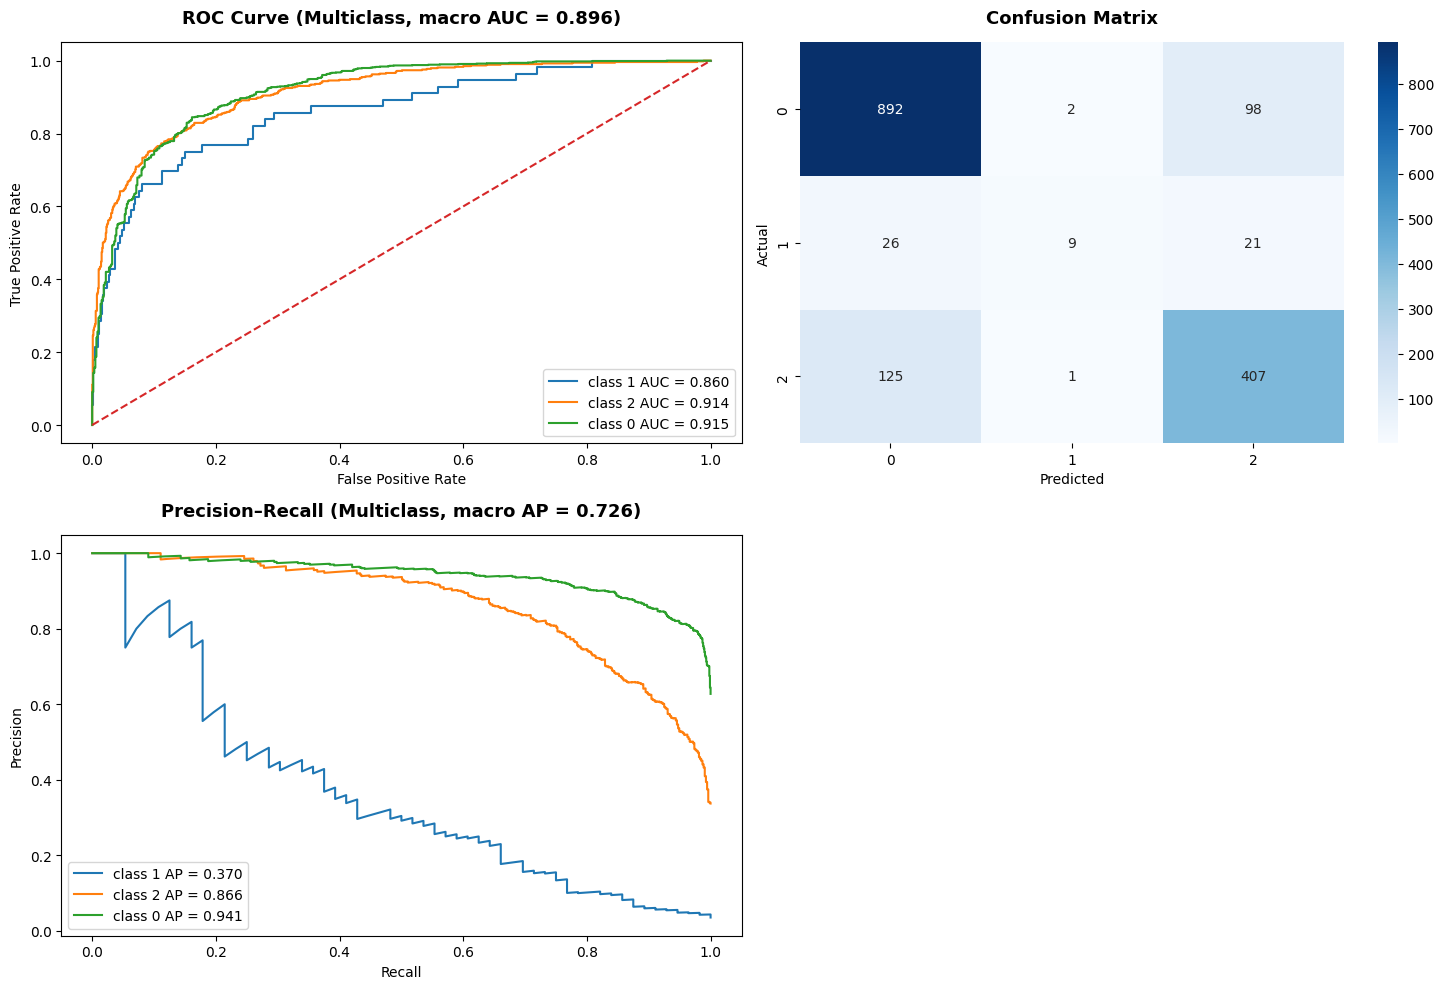

              precision    recall  f1-score   support

           0      0.855     0.899     0.877       992
           1      0.750     0.161     0.265        56
           2      0.774     0.764     0.769       533

    accuracy                          0.827      1581
   macro avg      0.793     0.608     0.637      1581
weighted avg      0.824     0.827     0.819      1581



{'roc_auc_macro': 0.8963829162812247,
 'pr_auc_macro': 0.7256243482890475,
 'accuracy': 0.8273244781783681}

In [38]:
param_gbc = {
"n_estimators": 650, 
"learning_rate": 0.04884874232147335, 
"max_depth": 2, 
"min_samples_split": 6, 
"min_samples_leaf": 9, 
"subsample": 0.7400733676883955, 
"max_features": None,
"random_state": 42,
}

model_gbc = GradientBoostingClassifier(**param_gbc)
evaluate_model(model = model_gbc, X_train=df_train_new_prepared, X_val=X_val_prepared,
                               y_train=df_train_label, y_val=y_val, figsize=(15, 10))

## LGBMClassifier

Evaluating LGBMClassifier...


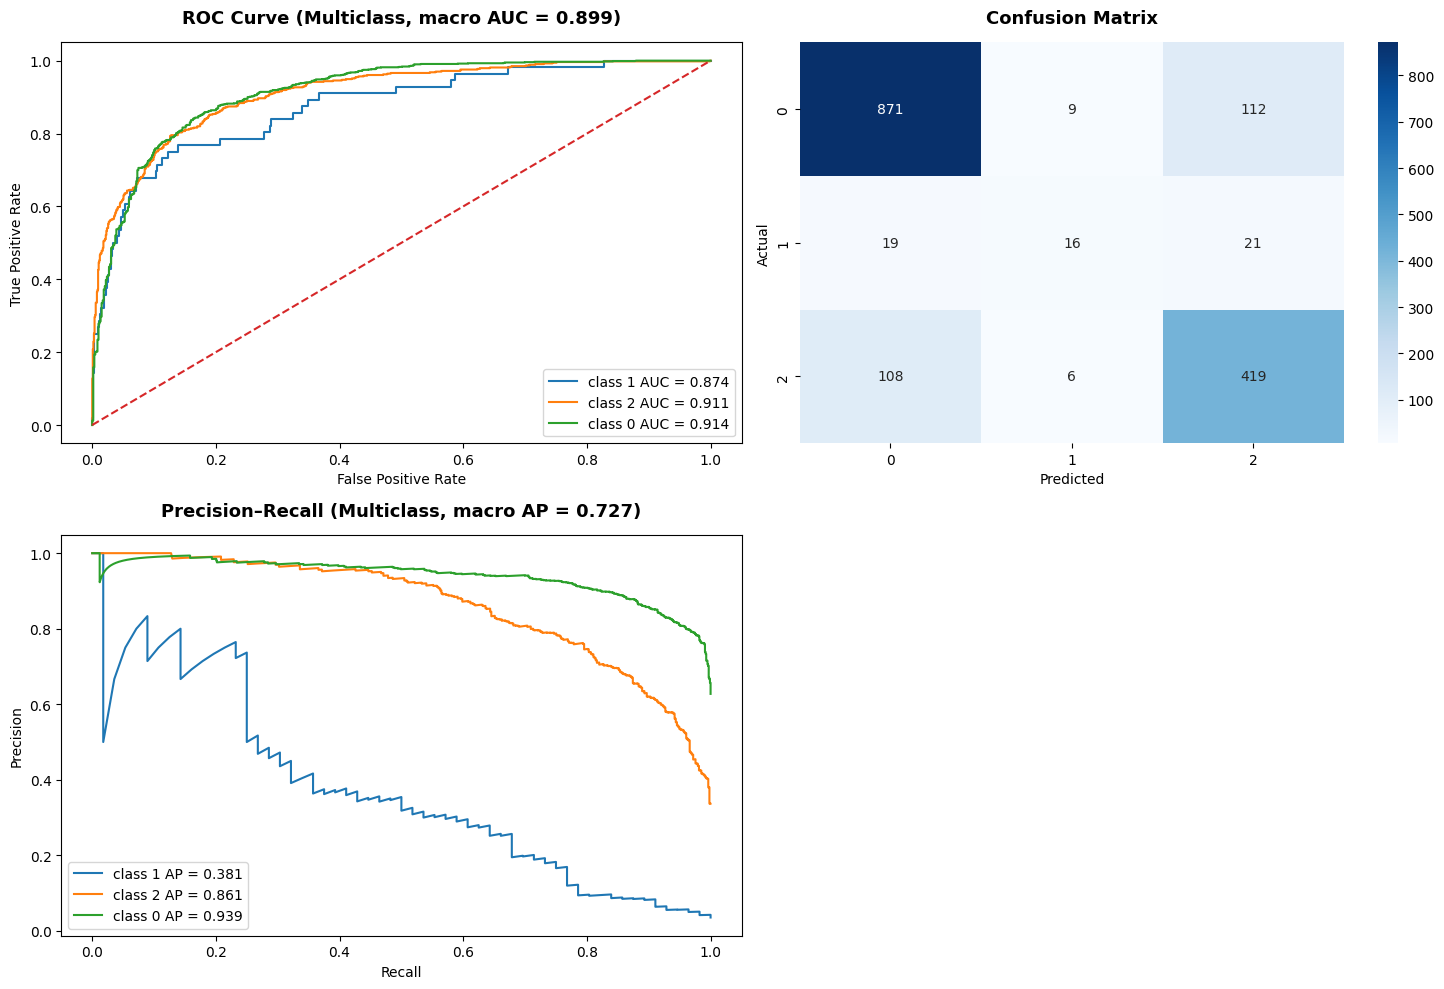

              precision    recall  f1-score   support

           0      0.873     0.878     0.875       992
           1      0.516     0.286     0.368        56
           2      0.759     0.786     0.772       533

    accuracy                          0.826      1581
   macro avg      0.716     0.650     0.672      1581
weighted avg      0.822     0.826     0.823      1581



{'roc_auc_macro': 0.8994425459126713,
 'pr_auc_macro': 0.7270023636178383,
 'accuracy': 0.8260594560404807}

In [39]:
param_lgbm = {
"n_estimators": 700, 
"learning_rate": 0.00584509334736526, 
"num_leaves": 185, 
"max_depth": 16, 
"min_child_samples": 8,
"subsample": 0.5319608915318002, 
"colsample_bytree": 0.5744567525383822, 
"reg_alpha": 2.948061606600429e-08, 
"reg_lambda": 1.8275933105098061,
"random_state": 42,
"objective": "multiclass",
"metric": "multi_logloss",
"n_jobs": -1,
"class_weight": "balanced",
"verbosity": -1
}

model_lgbm = LGBMClassifier(**param_lgbm)
evaluate_model(model = model_lgbm, X_train=df_train_new_prepared, X_val=X_val_prepared,
                               y_train=df_train_label, y_val=y_val, figsize=(15, 10))

## CatBoostClassifier

Evaluating CatBoostClassifier...


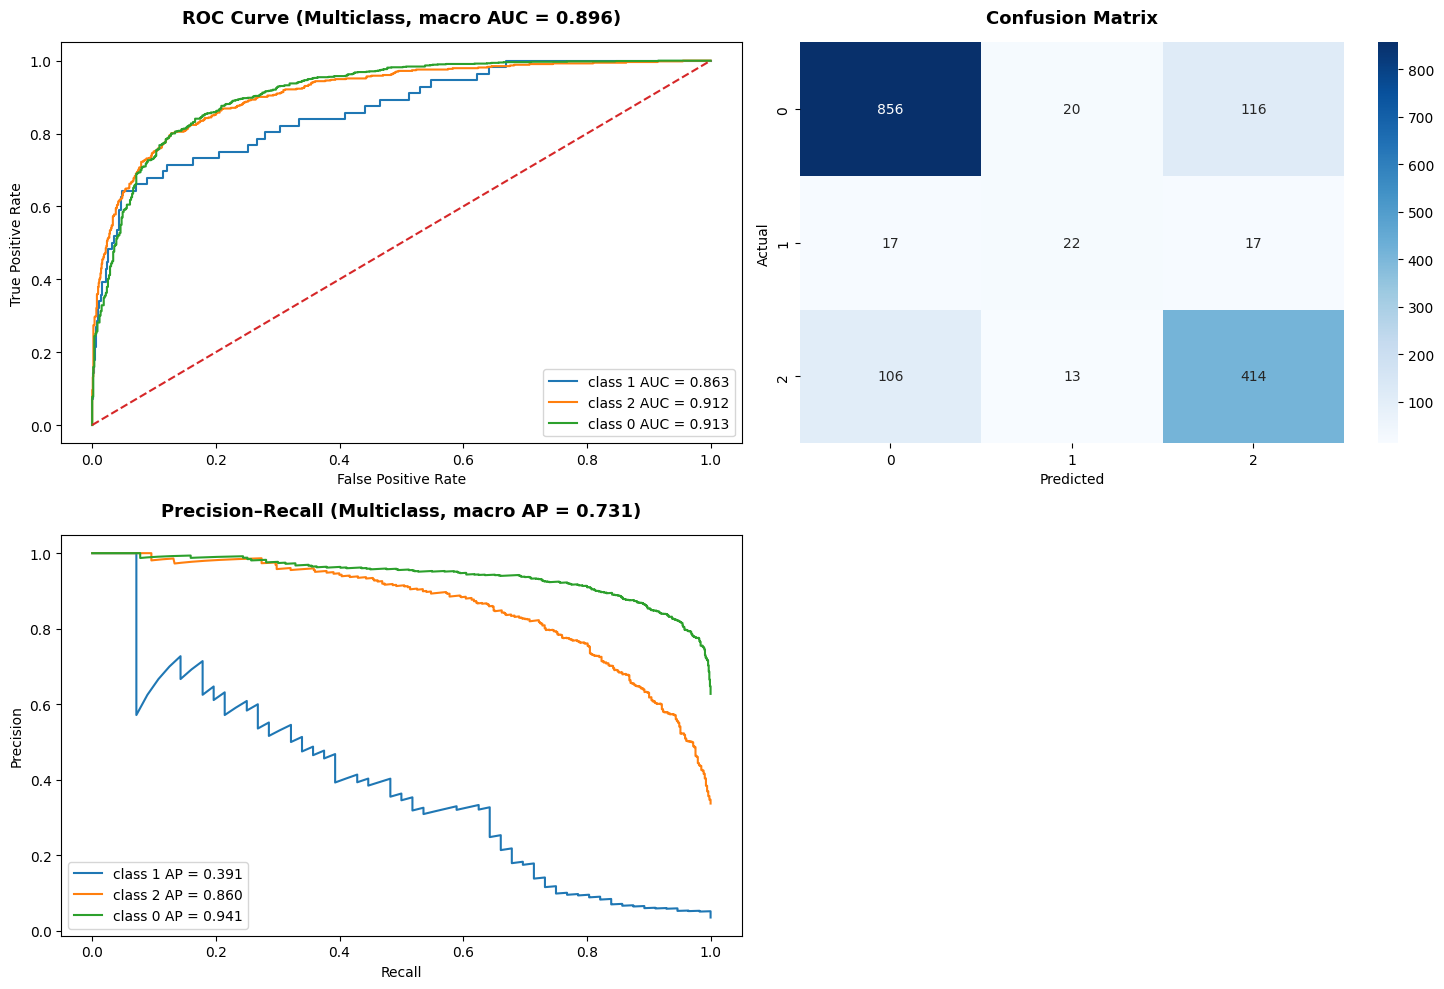

              precision    recall  f1-score   support

           0      0.874     0.863     0.869       992
           1      0.400     0.393     0.396        56
           2      0.757     0.777     0.767       533

    accuracy                          0.817      1581
   macro avg      0.677     0.677     0.677      1581
weighted avg      0.818     0.817     0.818      1581



{'roc_auc_macro': 0.8960218919079953,
 'pr_auc_macro': 0.7307100341131515,
 'accuracy': 0.8172043010752689}

In [40]:
param_cb = {
"bootstrap_type": "Bayesian", 
"iterations": 500, 
"depth": 8, 
"learning_rate": 0.04319007286588319, 
"l2_leaf_reg": 1.6775308558511295, 
"bagging_temperature": 0.6909789638528715, 
"random_strength": 1.4900742848944053, 
"border_count": 254, 
"grow_policy": "Depthwise",
"verbose": 0,
"random_seed": 42,
"eval_metric": "MultiClass",
"loss_function": "MultiClass",
"auto_class_weights":"Balanced",
"task_type": "CPU",
"thread_count": -1
}

model_cb = CatBoostClassifier(**param_cb)

evaluate_model(model = model_cb, X_train=df_train_new_prepared, X_val=X_val_prepared,
                               y_train=df_train_label, y_val=y_val, figsize=(15, 10))

## VotingClassifier

In [41]:
# --- Collect predictions (probabilities for all classes) ---
ests = [("cb", model_cb), ("lgbm", model_lgbm), ("gbc", model_gbc)]

# Get full probability outputs (n_val, n_classes)
preds = {name: m.predict_proba(X_val_prepared) for name, m in ests}

# Compute log loss for each model (multiclass)
logloss_each = {name: log_loss(y_val, preds[name]) for name, _ in ests}
display(logloss_each)

# --- Stack along the 2nd axis (model dimension) ---
# A has shape (n_val, n_classes * n_models)
A = np.hstack([preds[name] for name, _ in ests])

n_models = len(ests)
n_classes = preds[ests[0][0]].shape[1]

# --- Objective function ---
def obj_w(trial):
    w = np.array([trial.suggest_float(f"w_{i}", 0.0, 5.0) for i in range(n_models)])
    if w.sum() == 0:
        return 1e6
    
    # Reshape into (n_val, n_models, n_classes)
    A_reshaped = A.reshape(len(y_val), n_models, n_classes)
    
    # Weighted average across the model axis
    y_hat = np.tensordot(A_reshaped, w / w.sum(), axes=(1, 0))
    
    return log_loss(y_val, y_hat)

# --- Optimize ---
study_w = optuna.create_study(direction="minimize")  # minimize log loss
study_w.optimize(obj_w, n_trials=1000, show_progress_bar=True)

# --- Result ---
w = np.array([study_w.best_params[f"w_{i}"] for i in range(n_models)])
weights = (w / w.sum()).tolist()

print("Best weights (normalized):", weights)
print("Best Log Loss:", study_w.best_value)

{'cb': 0.4520204735103551,
 'lgbm': 0.44389727523944544,
 'gbc': 0.43003779797411995}

  0%|          | 0/1000 [00:00<?, ?it/s]

Best weights (normalized): [0.08911067922994582, 0.20255140076247832, 0.7083379200075759]
Best Log Loss: 0.4265825343778469


In [42]:
from sklearn.ensemble import VotingClassifier
voting_clf_soft = VotingClassifier(
    estimators=[("cb", model_cb), ("lgbm", model_lgbm), ("gbc", model_gbc)],
    voting="soft", weights=weights, n_jobs=-1)

cv_scores = cross_val_score(
    voting_clf_soft,
    X=df_train_new_prepared,
    y=df_train_label,
    cv=kfold,
    scoring="neg_log_loss",
    n_jobs=-1
)
print(f"Cross-validated Log Loss (mean ± std): {-cv_scores.mean():.4f} ± {-cv_scores.std():.4f}")

Cross-validated Log Loss (mean ± std): 0.4454 ± -0.0141


Evaluating VotingClassifier...


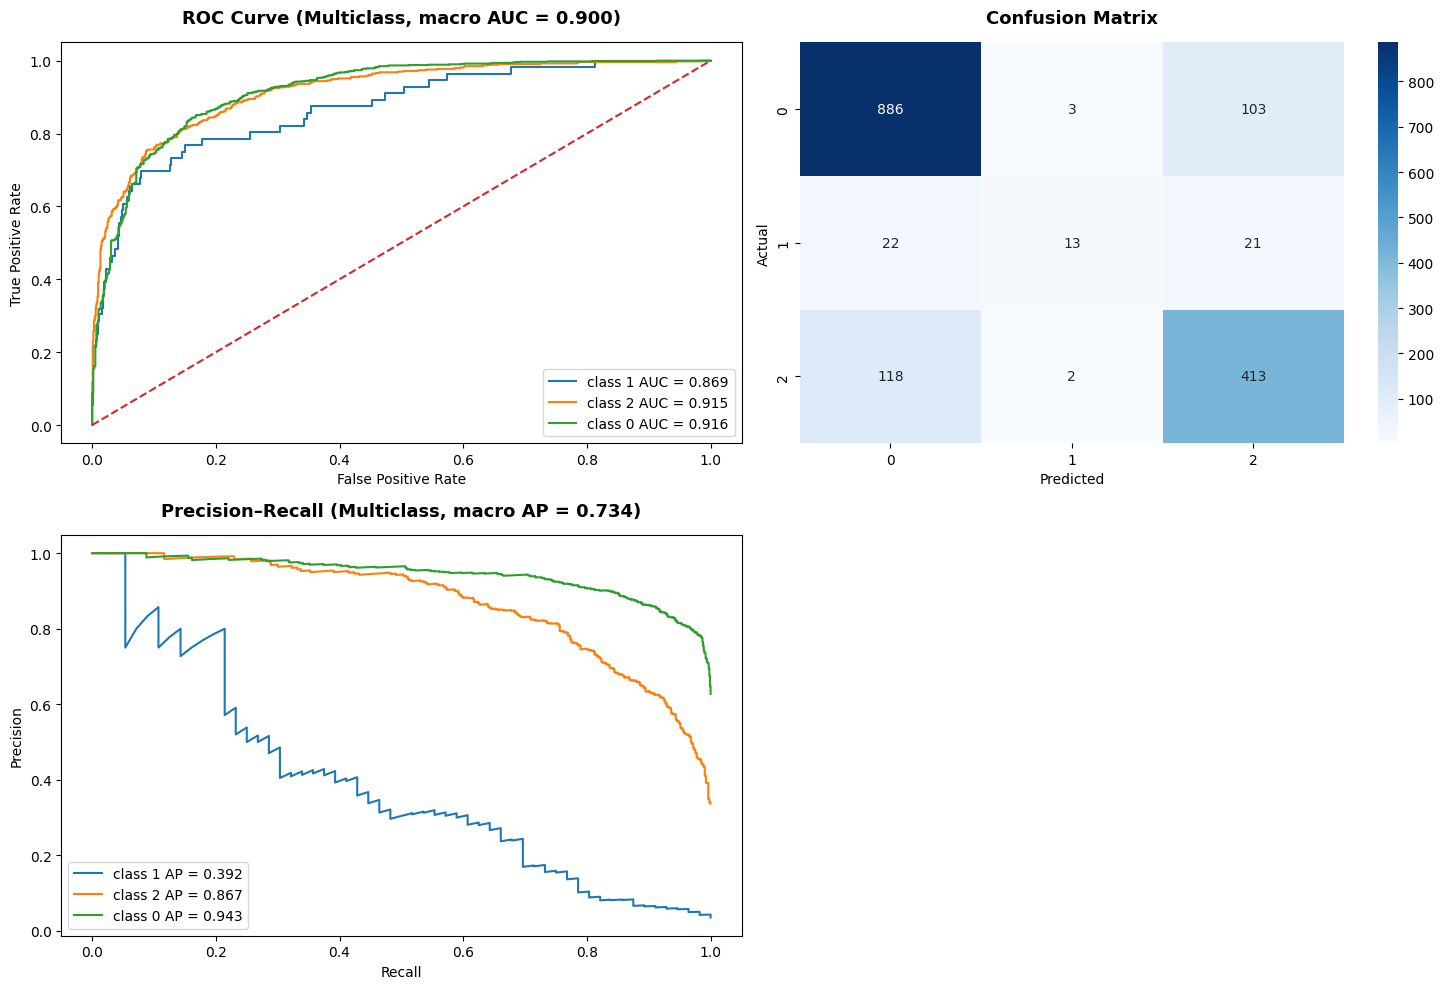

              precision    recall  f1-score   support

           0      0.864     0.893     0.878       992
           1      0.722     0.232     0.351        56
           2      0.769     0.775     0.772       533

    accuracy                          0.830      1581
   macro avg      0.785     0.633     0.667      1581
weighted avg      0.827     0.830     0.824      1581



{'roc_auc_macro': 0.9004029816824893,
 'pr_auc_macro': 0.7341102653908215,
 'accuracy': 0.8298545224541429}

In [43]:
evaluate_model(model = voting_clf_soft, X_train=df_train_new_prepared, X_val=X_val_prepared,
                               y_train=df_train_label, y_val=y_val, figsize=(15, 10))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Prepare Final Submission File</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Prepare Final Submission File
    </h1>
</div>

In [44]:
df_test_prepared = preprocessor.transform(processed_test_df)

In [45]:
# Generate predicted probabilities for the test set
y_pred_test_prob_cat = voting_clf_soft.predict_proba(df_test_prepared)
submission = pd.DataFrame(y_pred_test_prob_cat, columns=["Status_C", "Status_CL", "Status_D"])
submission["id"] = list_test_id
submission = submission[["id", "Status_C", "Status_CL", "Status_D"]]
submission.to_csv("submission.csv", index=False)
display(submission.head())

,id,Status_C,Status_CL,Status_D
0,7905,0.362780,0.025720,0.611499
1,7906,0.589636,0.214016,0.196348
2,7907,0.044672,0.023003,0.932325
3,7908,0.953719,0.008591,0.037690
4,7909,0.677268,0.104306,0.218426


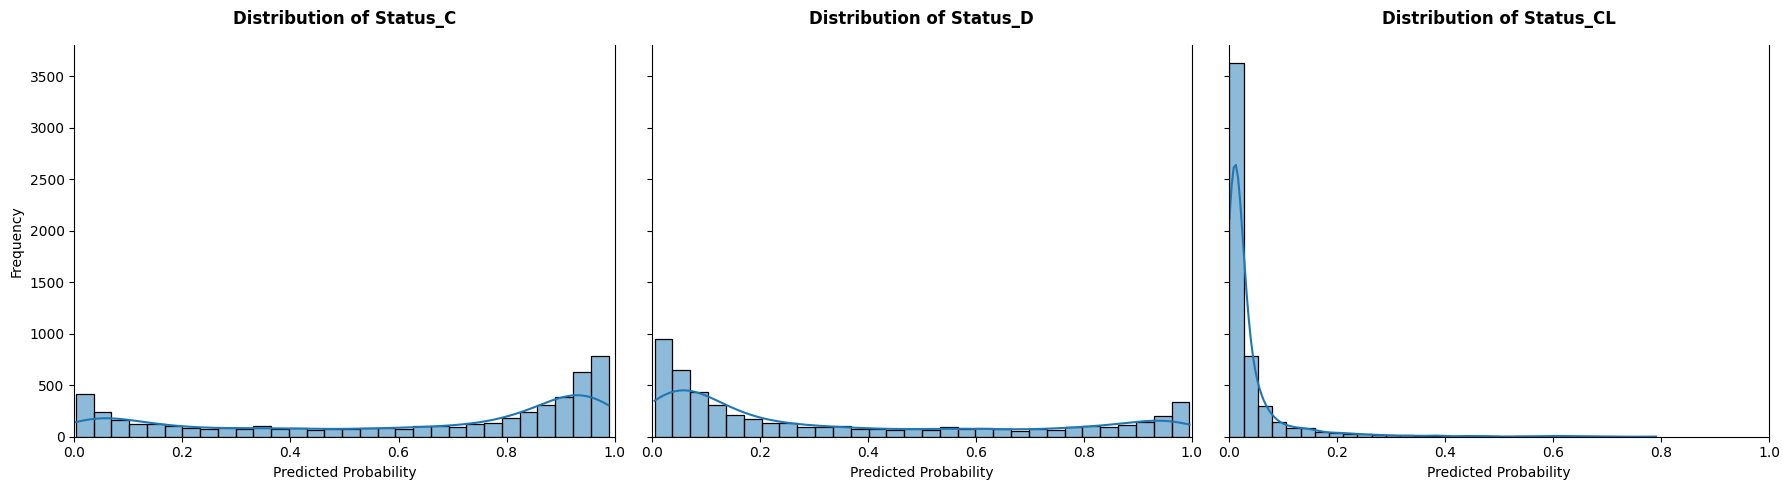

In [46]:
cols = ["Status_C", "Status_D", "Status_CL"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, col in zip(axes, cols):
    sns.histplot(submission[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}", weight="bold", pad=15, fontsize=12)
    ax.set_xlabel("Predicted Probability")
    ax.set_xlim(0, 1)
    ax.set_ylabel("Frequency")

sns.despine(left=False, bottom=False, right=False)
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 501it [02:45,  2.93it/s]


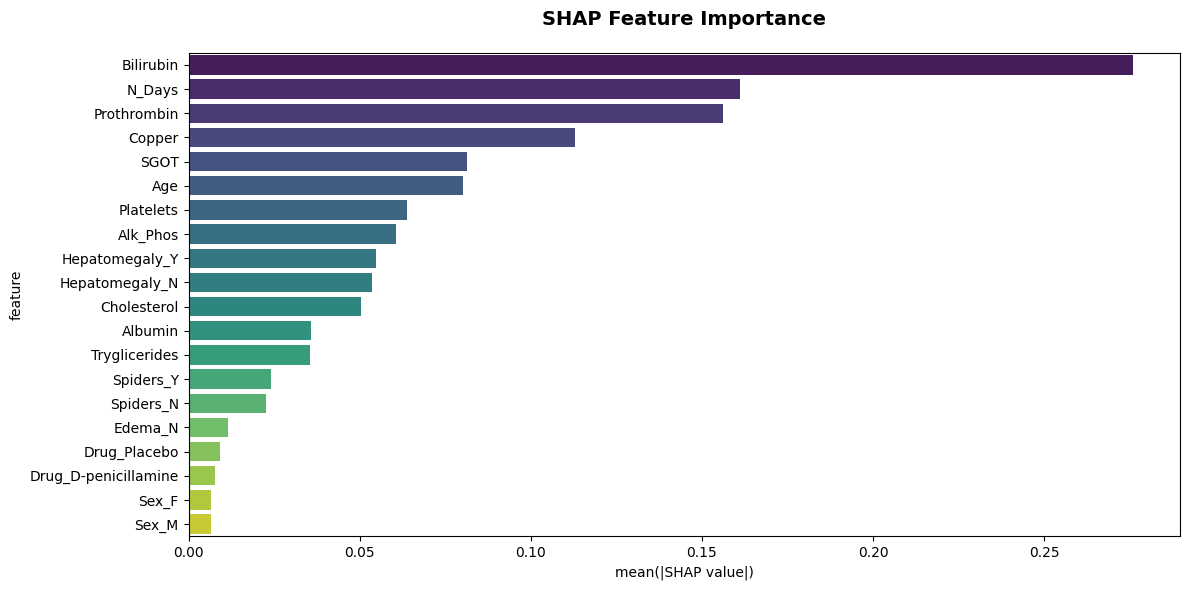

In [47]:
shap_plot(model=voting_clf_soft.named_estimators_["cb"], X_test=df_test_prepared[:500], list_feature=clean_features, type="bar")

**SHAP Feature Importance Summary**

* **Top predictors:**

  * **Bilirubin** and **Prothrombin** are the two most influential features — both strongly associated with liver function and disease progression.
  * **N_Days** (duration of observation) and **Copper** also contribute significantly to model predictions.
  * **SGOT**, **Age**, and **Platelets** provide additional predictive power, reflecting metabolic and demographic effects.

* **Categorical insights:**

  * **Hepatomegaly (Y/N)** and **Spiders (Y/N)** have moderate influence, confirming the relevance of clinical symptoms.
  * Drug type and gender show **minor impact** on the final prediction.

**Conclusion:**

> Model decisions are primarily driven by **biochemical markers (Bilirubin, Prothrombin, Copper)** and **clinical indicators (Age, Platelets)** — aligning well with known medical relevance in liver disease prognosis.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
